# 0. Bibliotecas

Nesta célula importamos todas as bibliotecas necessárias para o projeto:

- **pandas** — manipulação e análise de dados em tabelas (DataFrames)
- **numpy** — operações matemáticas e arrays numéricos
- **seaborn / matplotlib** — visualização de dados (gráficos, boxplots, heatmaps)
- **re / math** — expressões regulares e funções matemáticas básicas
- **sklearn.preprocessing** — ferramentas de pré-processamento:
  - `LabelEncoder` — converte categorias (texto) em números inteiros
  - `OneHotEncoder` — converte categorias em colunas binárias (0/1)
  - `StandardScaler` — normaliza os dados para média 0 e desvio padrão 1
- **sklearn.model_selection** — `train_test_split` divide os dados em treino e teste


In [1]:
import pandas as pd           # manipulação de DataFrames
import seaborn as sns          # visualização estatística (boxplots, heatmaps)
import matplotlib.pyplot as plt # gráficos base
import numpy as np             # operações numéricas (NaN, inf, etc.)
import re                      # expressões regulares (para limpeza de texto)
import math                    # funções matemáticas básicas
from sklearn.preprocessing import LabelEncoder   # codifica categorias em inteiros (ex: "Ss-20" → 0)
from sklearn.preprocessing import OneHotEncoder  # codifica categorias em colunas binárias (não usado directamente mas importado)

from sklearn.preprocessing import StandardScaler         # normalização (média 0, desvio padrão 1)
from sklearn.model_selection import train_test_split     # divisão treino/teste


In [2]:
pd.set_option('display.max_columns', None)


# 1. Importação dos dados

Os dados estão distribuídos por vários grupos (pastas `Grupo 1`, `Grupo 3`, etc.) dentro de `Final/Data/`.
Cada pasta contém um ficheiro `dataset.json` com os elementos BIM extraídos do Revit.

O que este bloco faz:
1. Encontra automaticamente a pasta `Data/` (seja o notebook a correr na raiz ou dentro de `Final/`)
2. Procura recursivamente todos os ficheiros `dataset.json` dentro dessa pasta
3. Carrega cada JSON como um DataFrame pandas e adiciona uma coluna `source` para identificar a origem (qual grupo)
4. Concatena todos os DataFrames numa única tabela `df`

> **Nota:** Se não encontrar a pasta `Data/` ou não houver ficheiros JSON, lança um erro claro.


In [3]:
from pathlib import Path

# ── Encontrar a pasta Data/ ────────────────────────────────────────────────
# O notebook pode ser executado a partir de duas localizações diferentes,
# por isso testamos ambas as possibilidades.
candidate_dirs = [Path.cwd() / "Data", Path.cwd() / "Final" / "Data"]
data_dir = next((path for path in candidate_dirs if path.exists()), None)

if data_dir is None:
    raise FileNotFoundError(
        "Não encontrei a pasta 'Data'. Verifica se o notebook está a correr dentro da pasta 'Final' ou na raiz do projeto."
    )

# ── Procurar todos os ficheiros dataset.json recursivamente ───────────────
# rglob("dataset.json") percorre todas as subpastas e encontra os ficheiros
json_paths = sorted(
    data_dir.rglob("dataset.json"),
    key=lambda path: path.relative_to(data_dir).as_posix().lower()
)

if not json_paths:
    raise FileNotFoundError(f"Não encontrei ficheiros 'dataset.json' em {data_dir}")

# output_dir é onde vão ser guardados os CSVs finais (junto à pasta Data/)
output_dir = data_dir.parent
dataframes = []

# ── Carregar cada JSON e adicionar coluna 'source' ─────────────────────────
# A coluna 'source' indica de que grupo veio cada linha (útil para depuração)
for path in json_paths:
    dataset = pd.read_json(path)
    dataset['source'] = path.parent.relative_to(data_dir).as_posix()
    dataframes.append(dataset)

print(f"Datasets carregados: {[path.parent.relative_to(data_dir).as_posix() for path in json_paths]}")
print(f"Total de ficheiros lidos: {len(dataframes)}")


Datasets carregados: ['CVTT_EST', 'Modelo_Quadrante_ARQ', 'Modelo_Quandrante_EST', 'Modelos não Classificados/EdícicioHabitacional_EST', 'Modelos não Classificados/INTENSIVE_1', 'Modelos não Classificados/MartaC', 'Modelos não Classificados/Residencia', 'Pilot6_ARQ', 'Pilot6_EST', 'SEC1_ARQ', 'SEC2_ARQ']
Total de ficheiros lidos: 11


In [4]:
df = pd.concat(dataframes, ignore_index=True)  # Base de dados completa (todos os dados numa só).
df.head()  # Algum contexto relativamente à base de dados completa.

,ElementID,SECClass_Code_EF,SECClass_Title_EF,SECClasS_Code_Ss,SECClasS_Title_Ss,SECClass_Code_Pr,SECClass_Title_Pr,Family and Type,Category,Volume,Area,Volume_to_Surface_Area_Ratio,load_bearing_status,Length,Height,Thickness/Width,Aspect_Ratio,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Phase_Created,Start_X,Start_Y,Start_Z,End_X,End_Y,End_Z,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,Comments,Keynote,Description,Materials,source
0,1306672,EF_25_10,Paredes - Walls,Ss_25_11_16_70,Sistemas de estrutura de parede de betão refor...,None,None,Basic Wall - Parede e=0.25,Walls,11.052029,44.208171,0.010581804998041342,Load-Bearing,13.559996,3.3700000000000134,0.24999999999999997,13.480000000000055,97.03133691535504,14.92403815525,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,6.497202775790357e-15,15,None,1016.0941266126491,289.615557027893,84.00999999999998,1016.0941266126491,276.0555607565337,84.00999999999998,0.25,3.37,13.659996,1016.094108984375,282.8525193140764,85.29589101149615,1.5707963267948966,0,None,None,None,['C30/37'],CVTT_EST
1,1306674,EF_25_10,Paredes - Walls,Ss_25_11_16_70,Sistemas de estrutura de parede de betão refor...,None,None,Basic Wall - Parede e=0.20,Walls,5.352291,26.761488,0.007553113527176852,Load-Bearing,27.2,0.9999999999999979,0.2,4.999999999999989,65.83297165517756,27.271980000000248,3 STR - Piso 0,Up to level: 3 STR - Piso 0,0.0,None,None,-0.9999999999999999,None,0.0,27,None,1016.0941266126491,276.0555607565337,84.00999999999998,1043.2941266126493,276.05556075653357,84.00999999999998,27.325,1.0,0.2,1029.6219058126449,276.0555591796875,83.50315728397713,3.821883985759006e-15,0,None,None,None,['C30/37'],CVTT_EST
2,1306676,EF_25_10,Paredes - Walls,Ss_25_11_16_70,Sistemas de estrutura de parede de betão refor...,None,None,Basic Wall - Parede e=0.20,Walls,4.716992,23.584990,0.007687581900132464,Load-Bearing,23.585,0.9999999999999979,0.2,4.999999999999989,57.003975456562195,21.9425520000002,3 STR - Piso 0,Up to level: 3 STR - Piso 0,0.0,None,None,-0.9999999999999999,None,0.0,6,None,1043.2941266126493,289.6155570278929,84.00999999999998,1019.7091266126489,289.615557027893,84.00999999999998,23.585,1.0,0.2,1031.5016522460937,289.61555939941405,83.51000031738282,3.1415926535897887,0,None,None,None,['C30/37'],CVTT_EST
3,1306762,EF_25_10,Paredes - Walls,Ss_25_11_16_70,Sistemas de estrutura de parede de betão refor...,None,None,Basic Wall - Parede e=0.25,Walls,4.604641,18.418585,0.00976913537494044,Load-Bearing,5.744,3.3700000000000134,0.24999999999999997,13.480000000000055,43.78943604178758,14.229165957072814,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,0.0,10,None,1044.094126612649,276.3915465344207,84.00999999999998,1044.094126612649,282.1355465344207,84.00999999999998,0.25,3.37,6.179986,1044.0941115234375,278.9164221575121,85.19334494995121,1.5707963267948966,0,None,None,None,['C30/37'],CVTT_EST
4,1306764,EF_25_10,Paredes - Walls,Ss_25_11_16_70,Sistemas de estrutura de parede de betão refor...,None,None,Basic Wall - Parede e=0.25,Walls,3.572691,14.474780,0.01000277727634506,Load-Bearing,4.395189,3.3700000000000134,0.24999999999999997,13.480000000000055,33.1821520061005,8.714404560528019,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,0.0,10,None,1044.094126612649,285.2203683134046,84.00999999999998,1044.094126612649,289.6155570278929,84.00999999999998,0.25,3.37,4.395189,1044.0941110444417,287.34083363339676,85.33939981801244,1.5707963267948966,0,None,None,None,['C30/37'],CVTT_EST


In [5]:
df.columns

Index(['ElementID', 'SECClass_Code_EF', 'SECClass_Title_EF',
       'SECClasS_Code_Ss', 'SECClasS_Title_Ss', 'SECClass_Code_Pr',
       'SECClass_Title_Pr', 'Family and Type', 'Category', 'Volume', 'Area',
       'Volume_to_Surface_Area_Ratio', 'load_bearing_status', 'Length',
       'Height', 'Thickness/Width', 'Aspect_Ratio', 'Total_Surface_Area',
       'Total_Edge_Length', 'Base_constraint', 'Top_constraint',
       'Base_extension_distance', 'Level', 'Base_level', 'Base_offset',
       'Top_level', 'Top_offset', 'Number_of_Faces', 'Phase_Created',
       'Start_X', 'Start_Y', 'Start_Z', 'End_X', 'End_Y', 'End_Z',
       'Bounding_Box_Width', 'Bounding_Box_Height', 'Bounding_Box_Depth',
       'Centroid_X', 'Centroid_Y', 'Centroid_Z', 'Orientation_Angle',
       'Curvature', 'Comments', 'Keynote', 'Description', 'Materials',
       'source'],
      dtype='object')

In [6]:
df1 = df.copy()

# 2. Tratamento das Variáveis

Nesta secção limpamos e preparamos cada variável para os modelos de ML.

**Pipeline geral aplicado a cada variável numérica:**
1. Analisar a distribuição de valores (`value_counts`, `describe`)
2. Substituir `'None'` (string) por `NaN` ou `0` conforme o contexto
3. Converter para `float`
4. Estudar outliers com boxplot (não removemos — os modelos usados são robustos a outliers)
5. Arredondar a 2 casas decimais

**Variáveis eliminadas logo no início** (secção 2.1):
- Colunas com informação semântica redundante ou de texto livre (`SECClass_Title`, `Family and Type`, `Comments`, etc.)
- Coordenadas de início/fim de elemento (`Start_X/Y/Z`, `End_X/Y/Z`) — substituídas pelas coordenadas do centróide
- Razões derivadas (`Aspect_Ratio`, `Volume_to_Surface_Area_Ratio`) — muito correlacionadas com as originais
- Campos de metadados sem valor preditivo (`Phase_Created`, `Keynote`, `Description`, `Materials`)


In [7]:
df1 = df1.drop([
    # ── Colunas do sistema de classificação alternativo (EF = Elementos de Fachada, Pr = Produto)
    # Não são o target do nosso modelo — o target é 'SECClasS_Code_Ss'
    'SECClass_Code_EF', 'SECClass_Title_EF',
    'SECClasS_Title_Ss',
    'SECClass_Code_Pr', 'SECClass_Title_Pr',
    'Family and Type',       # texto livre do Revit, muito variado entre projectos

    # ── Coordenadas de início/fim (para elementos lineares como vigas/pilares)
    # Substituídas pelas coordenadas do centróide (Centroid_X/Y/Z), que generalizam melhor
    'Start_X', 'Start_Y', 'Start_Z',
    'End_X', 'End_Y', 'End_Z',

    # ── Variáveis derivadas muito correlacionadas com as originais
    # Aspect_Ratio = comprimento/largura (derivado de Length e Thickness/Width)
    # Volume_to_Surface_Area_Ratio = derivado de Volume e Area
    # Manter estas colunas causaria multicolinearidade
    'Aspect_Ratio', 'Volume_to_Surface_Area_Ratio',

    # ── Metadados sem valor preditivo
    'Phase_Created', 'Comments', 'Keynote', 'Description', 'Materials'
], axis=1)

df1.head()


,ElementID,SECClasS_Code_Ss,Category,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source
0,1306672,Ss_25_11_16_70,Walls,11.052029,44.208171,Load-Bearing,13.559996,3.3700000000000134,0.24999999999999997,97.03133691535504,14.92403815525,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,6.497202775790357e-15,15,0.25,3.37,13.659996,1016.094108984375,282.8525193140764,85.29589101149615,1.5707963267948966,0,CVTT_EST
1,1306674,Ss_25_11_16_70,Walls,5.352291,26.761488,Load-Bearing,27.2,0.9999999999999979,0.2,65.83297165517756,27.271980000000248,3 STR - Piso 0,Up to level: 3 STR - Piso 0,0.0,None,None,-0.9999999999999999,None,0.0,27,27.325,1.0,0.2,1029.6219058126449,276.0555591796875,83.50315728397713,3.821883985759006e-15,0,CVTT_EST
2,1306676,Ss_25_11_16_70,Walls,4.716992,23.584990,Load-Bearing,23.585,0.9999999999999979,0.2,57.003975456562195,21.9425520000002,3 STR - Piso 0,Up to level: 3 STR - Piso 0,0.0,None,None,-0.9999999999999999,None,0.0,6,23.585,1.0,0.2,1031.5016522460937,289.61555939941405,83.51000031738282,3.1415926535897887,0,CVTT_EST
3,1306762,Ss_25_11_16_70,Walls,4.604641,18.418585,Load-Bearing,5.744,3.3700000000000134,0.24999999999999997,43.78943604178758,14.229165957072814,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,0.0,10,0.25,3.37,6.179986,1044.0941115234375,278.9164221575121,85.19334494995121,1.5707963267948966,0,CVTT_EST
4,1306764,Ss_25_11_16_70,Walls,3.572691,14.474780,Load-Bearing,4.395189,3.3700000000000134,0.24999999999999997,33.1821520061005,8.714404560528019,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,0.0,10,0.25,3.37,4.395189,1044.0941110444417,287.34083363339676,85.33939981801244,1.5707963267948966,0,CVTT_EST


In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38749 entries, 0 to 38748
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ElementID                38749 non-null  int64  
 1   SECClasS_Code_Ss         38749 non-null  object 
 2   Category                 38749 non-null  object 
 3   Volume                   38749 non-null  object 
 4   Area                     38749 non-null  float64
 5   load_bearing_status      38749 non-null  object 
 6   Length                   38749 non-null  object 
 7   Height                   38749 non-null  object 
 8   Thickness/Width          38749 non-null  object 
 9   Total_Surface_Area       38749 non-null  object 
 10  Total_Edge_Length        38749 non-null  object 
 11  Base_constraint          38749 non-null  object 
 12  Top_constraint           38749 non-null  object 
 13  Base_extension_distance  38749 non-null  object 
 14  Level                 

## 2.1 Element_ID

In [9]:
df1['ElementID'].value_counts()

ElementID
513254     3
4690415    2
512522     2
4984913    2
485467     2
          ..
550331     1
550332     1
550333     1
550335     1
3219804    1
Name: count, Length: 38661, dtype: int64

In [10]:
df1['ElementID'] = df1['ElementID'].astype('category')
df1['ElementID'].describe()

count      38749
unique     38661
top       513254
freq           3
Name: ElementID, dtype: int64

## 2.2 SECClasS_Code_Ss — Variável Target (o que queremos prever)

`SECClasS_Code_Ss` é a classificação SfB/Ss de cada elemento BIM. É o que os modelos de ML vão aprender a prever.

**Formato:** código hierárquico tipo `Ss-20.10`, `Ss-30.20`, etc.
- Os primeiros 5 caracteres (`Ss-20`) representam o **nível 1** (mais geral)
- Os primeiros 8 caracteres (`Ss-20.10`) representam o **nível 2** (mais específico)

**Passos de limpeza:**
1. Substituir `'None'` e strings vazias por `NaN` e remover essas linhas (não podemos treinar sem label)
2. Truncar o código ao 1º ponto (ex: `Ss-20.10.15` → `Ss-20.10`) — standardizar o formato
3. Remover classes raras (< 30 exemplos) — modelos não conseguem aprender com poucos exemplos
4. Criar dois targets: nível 1 (5 chars) e nível 2 (8 chars)
5. Aplicar `LabelEncoder` para converter strings em inteiros (ex: `"Ss-20"` → `0`, `"Ss-30"` → `1`)


### 2.2.1 Valores iniciais

In [11]:
df1['SECClasS_Code_Ss'].value_counts()

SECClasS_Code_Ss
None                   19139
Ss_25_20_90_13          6244
Ss_20_30_75_15          1742
Ss_25_10_30_35.PDI0     1341
Ss_20_20_75_15          1170
                       ...  
Ss_25_30_95.BB             1
Ss_25_30_95.AI             1
Ss_25_30_95.BC             1
Ss_25_30_95.BG             1
Ss_25_30_95.AQ             1
Name: count, Length: 186, dtype: int64

In [12]:
df1['SECClasS_Code_Ss'].describe()

count     38749
unique      186
top        None
freq      19139
Name: SECClasS_Code_Ss, dtype: object

### 2.2.2 Eliminar valores nulos

In [13]:
# Substituir a string 'None' (vinda do Revit/JSON) e strings vazias por NaN (valor nulo real do pandas)
# Sem esta conversão, o pandas trataria 'None' como texto válido
df1['SECClasS_Code_Ss'] = df1['SECClasS_Code_Ss'].replace('None', np.nan)
df1['SECClasS_Code_Ss'] = df1['SECClasS_Code_Ss'].replace('', np.nan)

# Verificar que percentagem de linhas ficou sem label (target nulo)
df1['SECClasS_Code_Ss'].isnull().mean() * 100


50.53033626674237

In [14]:
# Verificar se existem labels válidos — se não houver, é impossível treinar um modelo supervisionado
valid_target_count = df1['SECClasS_Code_Ss'].notna().sum()

if valid_target_count == 0:
    raise ValueError(
        "Os ficheiros em 'Final/Data' não contêm valores válidos em 'SECClasS_Code_Ss'. "
        "Este notebook foi criado para dados já classificados; com os dados atuais não é possível gerar os targets supervisionados."
    )

# Remover todas as linhas sem label — não servem para aprendizagem supervisionada
df1 = df1.dropna(subset=['SECClasS_Code_Ss'])

# Confirmar que não há mais nulos
df1['SECClasS_Code_Ss'].isnull().mean() * 100


0.0

### 2.2.3 Standardizar o formato do código

Os códigos Ss podem ter formatos diferentes entre projectos (ex: `Ss-20`, `Ss-20.10`, `Ss-20.10.15`).

Para uniformizar:
1. Truncar a 14 caracteres (máximo do código completo)
2. Cortar tudo após o **primeiro ponto** para ficar com o código base (ex: `Ss-20.10` → `Ss-20`)

> Isto garante que o mesmo elemento classificado como `Ss-20` ou `Ss-20.10` seja tratado da mesma forma ao nível 1.


In [15]:
# Passo 1: limitar a 14 caracteres (comprimento máximo do código)
df1['SECClasS_Code_Ss'] = df1['SECClasS_Code_Ss'].str.slice(0, 14)

# Passo 2: cortar no primeiro ponto — ficamos com o código até ao nível base
# Exemplo: "Ss-20.10.15" → "Ss-20" (para nível 1) ou "Ss-20.10" (para nível 2)
# Aqui guardamos o código completo sem o sufixo extra
df1['SECClasS_Code_Ss'] = df1['SECClasS_Code_Ss'].str.split('.').str[0]

# Verificar a distribuição de classes após standardização
df1['SECClasS_Code_Ss'].value_counts()


SECClasS_Code_Ss
Ss_25_20_90_13    6244
Ss_20_30_75_15    1742
Ss_25_10_30_35    1578
Ss_20_20_75_15    1170
Ss_25_13_50        979
                  ... 
Ss_25_30_100         1
Ss_25_30_101         1
Ss_25_30_103         1
Ss_30_10_30_45       1
Ss_25_30_102         1
Name: count, Length: 100, dtype: int64

### 2.2.4 Remover classes raras

Classes com poucos exemplos (< 30) são problemáticas para os modelos de ML:
- Não há dados suficientes para o modelo aprender o padrão
- Causam problemas no SMOTE (oversampling) e na validação cruzada
- Degradam as métricas de avaliação

**Limiar usado: mínimo 30 exemplos por classe** (`n_min = 30`)

As linhas pertencentes a classes raras são marcadas com `is_rare_class = 1` e depois removidas.


In [16]:
# Contar quantas vezes aparece cada código de classe
freq = df1['SECClasS_Code_Ss'].value_counts()

# Limiar mínimo: classes com menos de 30 exemplos são "raras"
n_min = 30
rare_classes = freq[freq < n_min].index  # lista de classes com poucos exemplos

# Marcar cada linha: 1 = pertence a classe rara, 0 = classe com exemplos suficientes
df1['is_rare_class'] = df1['SECClasS_Code_Ss'].isin(rare_classes).astype(int)
df1['is_rare_class'].value_counts()


is_rare_class
0    18748
1      421
Name: count, dtype: int64

In [17]:
# Remover linhas raras (como combinámos)
df1 = df1[df1["is_rare_class"] != 1].copy()

### 2.2.5 Separar por níveis de detalhe

O código Ss tem uma hierarquia:
- **Nível 1** (5 caracteres) — ex: `Ss-20` — categoria mais geral (tipo de elemento estrutural)
- **Nível 2** (8 caracteres) — ex: `Ss-20.10` — sub-categoria mais específica

Vamos criar **dois datasets separados**, um para cada nível:
- `data4_1.csv` → treinar modelos para prever o **nível 1** (`SECClasS_Code_Ss_1_encode`)
- `data4_2.csv` → treinar modelos para prever o **nível 2** (`SECClasS_Code_Ss_2_encode`)

Desta forma podemos comparar qual o nível de detalhe que os modelos conseguem prever com maior precisão.


In [18]:
df1['SECClasS_Code_Ss_1'] = df1['SECClasS_Code_Ss']
df1['SECClasS_Code_Ss_2'] = df1['SECClasS_Code_Ss']

df1.head()

,ElementID,SECClasS_Code_Ss,Category,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2
0,1306672,Ss_25_11_16_70,Walls,11.052029,44.208171,Load-Bearing,13.559996,3.3700000000000134,0.24999999999999997,97.03133691535504,14.92403815525,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,6.497202775790357e-15,15,0.25,3.37,13.659996,1016.094108984375,282.8525193140764,85.29589101149615,1.5707963267948966,0,CVTT_EST,0,Ss_25_11_16_70,Ss_25_11_16_70
1,1306674,Ss_25_11_16_70,Walls,5.352291,26.761488,Load-Bearing,27.2,0.9999999999999979,0.2,65.83297165517756,27.271980000000248,3 STR - Piso 0,Up to level: 3 STR - Piso 0,0.0,None,None,-0.9999999999999999,None,0.0,27,27.325,1.0,0.2,1029.6219058126449,276.0555591796875,83.50315728397713,3.821883985759006e-15,0,CVTT_EST,0,Ss_25_11_16_70,Ss_25_11_16_70
2,1306676,Ss_25_11_16_70,Walls,4.716992,23.584990,Load-Bearing,23.585,0.9999999999999979,0.2,57.003975456562195,21.9425520000002,3 STR - Piso 0,Up to level: 3 STR - Piso 0,0.0,None,None,-0.9999999999999999,None,0.0,6,23.585,1.0,0.2,1031.5016522460937,289.61555939941405,83.51000031738282,3.1415926535897887,0,CVTT_EST,0,Ss_25_11_16_70,Ss_25_11_16_70
3,1306762,Ss_25_11_16_70,Walls,4.604641,18.418585,Load-Bearing,5.744,3.3700000000000134,0.24999999999999997,43.78943604178758,14.229165957072814,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,0.0,10,0.25,3.37,6.179986,1044.0941115234375,278.9164221575121,85.19334494995121,1.5707963267948966,0,CVTT_EST,0,Ss_25_11_16_70,Ss_25_11_16_70
4,1306764,Ss_25_11_16_70,Walls,3.572691,14.474780,Load-Bearing,4.395189,3.3700000000000134,0.24999999999999997,33.1821520061005,8.714404560528019,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,0.0,10,0.25,3.37,4.395189,1044.0941110444417,287.34083363339676,85.33939981801244,1.5707963267948966,0,CVTT_EST,0,Ss_25_11_16_70,Ss_25_11_16_70


#### 2.2.5.1 Target Nível 1 + LabelEncoder

O **LabelEncoder** converte strings em inteiros sequenciais para que os algoritmos de ML possam processar a coluna target.

**Exemplo:**
```
"Ss-20" → 0
"Ss-30" → 1
"Ss-40" → 2
```

O objeto `encoder1` fica guardado em memória e será necessário para **inferência** — para converter as previsões numéricas de volta para os nomes das classes.

> O encoder é guardado em `Final/models/encoder_4_1.pkl` no final do notebook (secção 4).


In [19]:
# Remover o que vem após o 5 dígito
df1['SECClasS_Code_Ss_1'] = df1['SECClasS_Code_Ss_1'].str.slice(0, 5)

# Mostrar o resultado
print("Distribuição:")
print(df1['SECClasS_Code_Ss_1'].value_counts())

Distribuição:
SECClasS_Code_Ss_1
Ss_25    14006
Ss_20     3856
Ss_30      517
Ss_37      215
Ss_35      105
Ss_40       49
Name: count, dtype: int64


In [20]:
# Criar o encoder para o nível 1 e ajustá-lo aos dados (fit)
encoder1 = LabelEncoder()

# fit_transform: aprende as classes (fit) e converte para inteiros (transform) de uma só vez
df1['SECClasS_Code_Ss_1_encode'] = encoder1.fit_transform(df1['SECClasS_Code_Ss_1'])

# Mostrar a correspondência: qual inteiro corresponde a qual classe
label_mapping_1 = pd.DataFrame({
    'Classe original': encoder1.classes_,
    'Código inteiro': range(len(encoder1.classes_))
})
print("Mapeamento do LabelEncoder (Nível 1):")
print(label_mapping_1.to_string(index=False))


Mapeamento do LabelEncoder (Nível 1):
Classe original  Código inteiro
          Ss_20               0
          Ss_25               1
          Ss_30               2
          Ss_35               3
          Ss_37               4
          Ss_40               5


#### 2.2.5.2 Target Nível 2 + LabelEncoder

Mesmo processo para o nível 2 (8 caracteres).

O `encoder2` será necessário para converter as previsões do modelo de nível 2 de volta para strings legíveis.

> O encoder é guardado em `Final/models/encoder_4_2.pkl` no final do notebook (secção 4).


In [21]:
# Remover o que vem após o 5 dígito
df1['SECClasS_Code_Ss_2'] = df1['SECClasS_Code_Ss_2'].str.slice(0, 8)

# Mostrar o resultado
print("Distribuição:")
print(df1['SECClasS_Code_Ss_2'].value_counts())

Distribuição:
SECClasS_Code_Ss_2
Ss_25_20    6568
Ss_25_30    1929
Ss_20_30    1869
Ss_25_13    1842
Ss_25_10    1799
Ss_20_20    1789
Ss_25_12     817
Ss_25_11     725
Ss_30_12     359
Ss_25_45     233
Ss_37_17     215
Ss_20_05     198
Ss_30_25     158
Ss_35_10     105
Ss_25_50      49
Ss_40_15      49
Ss_25_14      44
Name: count, dtype: int64


In [22]:
# Criar o encoder para o nível 2 e ajustá-lo aos dados
encoder2 = LabelEncoder()
df1['SECClasS_Code_Ss_2_encode'] = encoder2.fit_transform(df1['SECClasS_Code_Ss_2'])

# Mostrar a correspondência completa
label_mapping_2 = pd.DataFrame({
    'Classe original': encoder2.classes_,
    'Código inteiro': range(len(encoder2.classes_))
})
print("Mapeamento do LabelEncoder (Nível 2):")
print(label_mapping_2.to_string(index=False))


Mapeamento do LabelEncoder (Nível 2):
Classe original  Código inteiro
       Ss_20_05               0
       Ss_20_20               1
       Ss_20_30               2
       Ss_25_10               3
       Ss_25_11               4
       Ss_25_12               5
       Ss_25_13               6
       Ss_25_14               7
       Ss_25_20               8
       Ss_25_30               9
       Ss_25_45              10
       Ss_25_50              11
       Ss_30_12              12
       Ss_30_25              13
       Ss_35_10              14
       Ss_37_17              15
       Ss_40_15              16


## 2.3 Category — Tipo de elemento BIM

`Category` é uma variável **categórica nominal** que indica o tipo de elemento BIM (Parede, Pilar, Viga, Piso, etc.).

Os algoritmos de ML precisam de números — não conseguem trabalhar com strings diretamente.

**Solução: One-Hot Encoding (OHE)**
- Cada categoria distinta torna-se uma nova coluna binária (0 ou 1)
- Exemplo: um elemento do tipo `Walls` fica com `Category_Walls = 1` e todos os outros `Category_* = 0`
- Evita que o modelo interprete as categorias como valores ordinais (ex: não faz sentido dizer que "Walls > Floors")

> **Nota:** Definimos `expected_category_columns` com as colunas esperadas para garantir consistência entre datasets de diferentes grupos — se um grupo não tiver, por exemplo, `Category_Stairs`, a coluna é adicionada com valor 0.


In [23]:
df1['Category'].value_counts()

Category
Curtain Panels            6323
Walls                     6302
Structural Framing        2112
Structural Columns        1559
Doors                     1240
Windows                    570
Floors                     399
Structural Foundations     152
Stairs                      79
Roofs                       12
Name: count, dtype: int64

### 2.3.1 One-Hot Encoding da variável Category

`pd.get_dummies()` cria as colunas binárias automaticamente, com prefixo `Category_`.

Após o encoding:
- Adicionamos as colunas que possam estar em falta (para garantir que todos os datasets têm as mesmas features)
- Convertemos de `bool` para `int` (0/1) para compatibilidade com todos os modelos de ML
- Removemos a coluna original `Category` (já não é necessária)


In [24]:
# Guardar o nome da categoria original antes de aplicar OHE
# (usado nas análises exploratórias das variáveis seguintes)
df1['Category_original'] = df1['Category']

# Lista das categorias esperadas — garante consistência entre grupos
# Se um grupo não tiver uma certa categoria, a coluna fica a 0
expected_category_columns = [
    'Category_Curtain Panels', 'Category_Doors', 'Category_Floors',
    'Category_Roofs', 'Category_Stairs', 'Category_Structural Columns',
    'Category_Structural Foundations', 'Category_Structural Framing',
    'Category_Walls', 'Category_Windows'
]

# Aplicar One-Hot Encoding: cada categoria vira uma coluna binária (0 ou 1)
dummies = pd.get_dummies(df1['Category'], prefix='Category')

# Adicionar colunas que possam estar em falta (se algum grupo não tiver certas categorias)
for col in expected_category_columns:
    if col not in dummies.columns:
        dummies[col] = 0  # coluna toda a zeros — categoria não presente neste dataset

# Garantir a ordem correcta das colunas (importante para consistência com os modelos)
dummies = dummies[expected_category_columns]

# Juntar as dummies ao DataFrame principal e remover a coluna original
df1 = pd.concat([df1, dummies], axis=1)
df1 = df1.drop('Category', axis=1)

df1.head()


,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows
0,1306672,Ss_25_11_16_70,11.052029,44.208171,Load-Bearing,13.559996,3.3700000000000134,0.24999999999999997,97.03133691535504,14.92403815525,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,6.497202775790357e-15,15,0.25,3.37,13.659996,1016.094108984375,282.8525193140764,85.29589101149615,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,False,False,False,False,False,False,False,False,True,False
1,1306674,Ss_25_11_16_70,5.352291,26.761488,Load-Bearing,27.2,0.9999999999999979,0.2,65.83297165517756,27.271980000000248,3 STR - Piso 0,Up to level: 3 STR - Piso 0,0.0,None,None,-0.9999999999999999,None,0.0,27,27.325,1.0,0.2,1029.6219058126449,276.0555591796875,83.50315728397713,3.821883985759006e-15,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,False,False,False,False,False,False,False,False,True,False
2,1306676,Ss_25_11_16_70,4.716992,23.584990,Load-Bearing,23.585,0.9999999999999979,0.2,57.003975456562195,21.9425520000002,3 STR - Piso 0,Up to level: 3 STR - Piso 0,0.0,None,None,-0.9999999999999999,None,0.0,6,23.585,1.0,0.2,1031.5016522460937,289.61555939941405,83.51000031738282,3.1415926535897887,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,False,False,False,False,False,False,False,False,True,False
3,1306762,Ss_25_11_16_70,4.604641,18.418585,Load-Bearing,5.744,3.3700000000000134,0.24999999999999997,43.78943604178758,14.229165957072814,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,0.0,10,0.25,3.37,6.179986,1044.0941115234375,278.9164221575121,85.19334494995121,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,False,False,False,False,False,False,False,False,True,False
4,1306764,Ss_25_11_16_70,3.572691,14.474780,Load-Bearing,4.395189,3.3700000000000134,0.24999999999999997,33.1821520061005,8.714404560528019,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,0.0,10,0.25,3.37,4.395189,1044.0941110444417,287.34083363339676,85.33939981801244,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,False,False,False,False,False,False,False,False,True,False


In [25]:
df1[expected_category_columns] = df1[expected_category_columns].astype(int)

df1.head()

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows
0,1306672,Ss_25_11_16_70,11.052029,44.208171,Load-Bearing,13.559996,3.3700000000000134,0.24999999999999997,97.03133691535504,14.92403815525,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,6.497202775790357e-15,15,0.25,3.37,13.659996,1016.094108984375,282.8525193140764,85.29589101149615,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0
1,1306674,Ss_25_11_16_70,5.352291,26.761488,Load-Bearing,27.2,0.9999999999999979,0.2,65.83297165517756,27.271980000000248,3 STR - Piso 0,Up to level: 3 STR - Piso 0,0.0,None,None,-0.9999999999999999,None,0.0,27,27.325,1.0,0.2,1029.6219058126449,276.0555591796875,83.50315728397713,3.821883985759006e-15,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0
2,1306676,Ss_25_11_16_70,4.716992,23.584990,Load-Bearing,23.585,0.9999999999999979,0.2,57.003975456562195,21.9425520000002,3 STR - Piso 0,Up to level: 3 STR - Piso 0,0.0,None,None,-0.9999999999999999,None,0.0,6,23.585,1.0,0.2,1031.5016522460937,289.61555939941405,83.51000031738282,3.1415926535897887,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0
3,1306762,Ss_25_11_16_70,4.604641,18.418585,Load-Bearing,5.744,3.3700000000000134,0.24999999999999997,43.78943604178758,14.229165957072814,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,0.0,10,0.25,3.37,6.179986,1044.0941115234375,278.9164221575121,85.19334494995121,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0
4,1306764,Ss_25_11_16_70,3.572691,14.474780,Load-Bearing,4.395189,3.3700000000000134,0.24999999999999997,33.1821520061005,8.714404560528019,3 STR - Piso 0,Up to level: 4 STR - Piso 1,0.0,None,None,-0.35,None,0.0,10,0.25,3.37,4.395189,1044.0941110444417,287.34083363339676,85.33939981801244,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0


## 2.4 Volume (e variáveis numéricas em geral)

As secções 2.4 a 2.29 seguem todas o **mesmo padrão** de limpeza para variáveis numéricas.

### Padrão aplicado a cada variável numérica:
1. **`value_counts()`** — ver que valores distintos existem (detectar 'None', strings inválidas, etc.)
2. **`describe()`** — estatísticas básicas (mín, máx, média, quartis)
3. **Substituir `'None'`** (string) e `None` por `NaN` — necessário porque o Revit exporta campos vazios como texto "None"
4. **`pd.to_numeric(errors='coerce')`** — converter para número; valores inválidos tornam-se `NaN`
5. **Boxplot** — visualizar a distribuição e identificar outliers (não são removidos — os modelos usados são robustos)
6. **Arredondar a 2 casas decimais** — reduzir precisão desnecessária

> **Nota sobre outliers:** Não removemos outliers nestas variáveis porque os modelos usados (Decision Tree, Random Forest, XGBoost, SVM) não são sensíveis a outliers — ao contrário de modelos lineares.


### 2.4.1 Análise de valores

In [26]:
df1['Volume'] = df1['Volume'].astype('float')
df1['Volume'].value_counts()

Volume
0.000082    4360
0.000186    1761
0.083600     335
0.000000     270
0.323629     105
            ... 
0.551566       1
6.265427       1
5.969328       1
0.589898       1
0.106181       1
Name: count, Length: 7509, dtype: int64

In [27]:
df1['Volume'].describe()

count    18748.000000
mean         1.834570
std         15.693958
min          0.000000
25%          0.000186
50%          0.083600
75%          0.625714
max        835.728535
Name: Volume, dtype: float64

### 2.4.2 Estudo de outliers

<Axes: xlabel='Volume'>

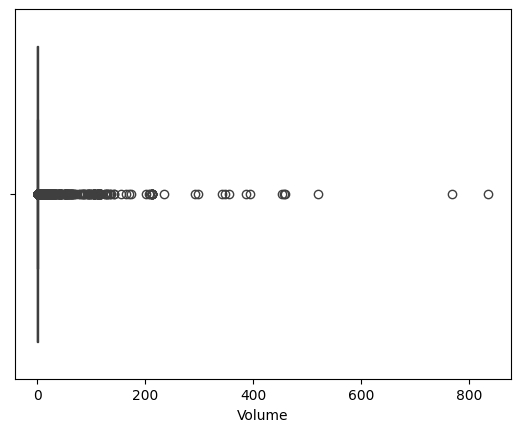

In [28]:
sns.boxplot(x=df1['Volume'])

In [29]:
# Ordenar pelas maiores volumes
df1.sort_values(by='Volume', ascending=False).head(1000)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows
37457,1470420,Ss_30_12,835.728535,879.715316,Non Load-Bearing,1.63,None,0.9500000000000001,1973.5639126910219,144.35544447108205,None,None,None,Piso 0,None,None,None,None,27,98.138589,0.95,12.784039,10.41304194634937,36.07464150409382,25.474999685668948,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
37458,1681803,Ss_30_12,768.503190,2195.726067,Non Load-Bearing,1.63,None,0.35000000000000003,4491.060354742574,176.5828569266551,None,None,None,Piso -1,None,None,None,None,32,100.117097,0.35,24.215651,9.751656837293295,30.06629623701812,22.525000680541993,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
329,1663447,Ss_30_12_85_70,519.733482,1484.807282,Load-Bearing,4.167618,None,0.35000000000000003,3064.442662287986,177.27569106195332,None,None,None,3 STR - Piso 0,None,None,None,None,311,53.395767,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
37444,352433,Ss_30_12,459.220477,1093.383416,Non Load-Bearing,1.63,None,0.42000000000000004,2340.000978599958,234.69805167966328,None,None,None,Piso 2,None,None,None,None,98,91.469776,0.42,15.403284,5.967871893091103,24.445143062059703,32.390000857543946,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
37465,2717318,Ss_30_12,456.337178,1086.518412,Non Load-Bearing,1.63,None,0.42000000000000004,2328.725163439616,236.7452827815059,None,None,None,Piso 1,None,None,None,None,104,91.469776,0.42,15.40323,5.692641646711649,24.437026370731893,29.089999960327148,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3871,5012072,Ss_25_11_16,4.515223,12.900653,Non Load-Bearing,4.949872,2.660000000000002,0.35,31.05821491077804,7.747859708098408,PISO 7,Up to level: PISO 8,0.0,None,None,-0.05,None,-0.29,6,0.3500000000000071,2.660000000000002,4.949871807823491,-94.26827387695313,65.6989060913086,105.77999912109375,1.5707963267948966,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0
5711,9668458,Ss_25_13_50,4.515223,12.900653,Non Load-Bearing,4.949872,2.660000000000002,0.35,31.05821491077804,8.69578770809841,PISO 9,Up to level: PISO 10,0.0,None,None,-0.05,None,-0.29,6,0.3500000000000071,2.660000000000002,4.949871807823491,-94.26827387695313,65.6989060913086,111.57999858398438,1.5707963267948966,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0
3868,5012066,Ss_25_11_16,4.515223,12.900653,Non Load-Bearing,4.949872,2.660000000000002,0.35,31.058214910777806,7.778339708098386,PISO 7,Up to level: PISO 8,0.0,None,None,-0.05,None,-0.29,6,0.3500000000000071,2.6599999999999846,4.949871807823482,-88.61827456054688,65.6989060913086,105.77999912109375,1.5707963267948966,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0
35742,1583332,Ss_25_13,4.514393,30.095987,Non Load-Bearing,10.625,3.2999999999999994,0.15000000000000002,64.19097236214188,16.084295999999206,Piso -1,Up to level: Piso 0,0.0,None,None,0.0,None,0.0,6,10.625,2.88,0.15,37.02725268859864,24.790170556640625,24.139999777221682,2.1606384132824777e-14,0,SEC1_ARQ,0,Ss_25,Ss_25_13,1

Os outliers não foram removidos, pois os modelos utilizados não são sensíveis às escalas dos dados.

### 2.4.3 Analisar valores = 0

In [30]:
df1[df1['Volume'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows
1317,1406020,Ss_20_20_75_15,0.0,0.000000,None,27.698,None,None,None,None,None,None,None,,None,None,None,None,None,27.698643,1.39,0.25,None,None,None,2.502111931370395e-15,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0
3879,5039663,Ss_25_10_20,0.0,5.455998,Non Load-Bearing,1.6,3.4099999999999873,None,27.530488146566796,0.0,PISO 0_L02,Up to level: PISO 1,None,None,None,0.0,None,-0.28999999999999687,0,1.7750000000000123,3.4099999999999873,0.9999999999999979,-87.64327360840755,68.28642451895688,85.10500063476084,3.141592653589793,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0
3964,5148305,Ss_25_10_20,0.0,6.319997,Non Load-Bearing,1.6,3.9499999999999855,None,31.877486274937734,0.0,PISO 0_L02,Up to level: PISO 1,None,None,None,-0.5399999999999985,None,-0.28999999999999687,0,1.6,3.9499999999999855,0.9999999999999979,-119.75989464109765,68.273925659174,84.83500316159724,3.141592653589793,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0
5702,8985376,Ss_25_10_20,0.0,7.135997,Non Load-Bearing,1.6,4.459999999999991,None,35.982984507288414,0.0,PISO 0_L01-A,Up to level: PISO 1,None,None,None,0.21092033729577508,None,-0.28999999999999687,0,1.6,4.459999999999991,1.0000000000000067,-133.14816115722536,68.26642543482599,84.58000012206865,3.141592653589788,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0
5997,3875390,Ss_20_30_75_15,0.0,0.000000,None,2.05,None,None,None,None,None,None,None,PISO 9,PISO 9,0.0,PISO 9,-0.24999999999999997,None,1.3999999999999937,0.24999999999999514,0.500000000000025,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38476,4948569,Ss_25_30_20_30,0.0,4.219998,Non Load-Bearing,2.0,2.1099999999999968,None,21.305490826780243,0.0,Piso 0,Up to level: Piso 0,None,None,None,-0.009999999999997726,None,2.099999999999996,0,2.228974,2.11,1.676397,-16.041883704335667,-5.860152484038152,44.345000207519675,2.757620218151045,0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0
38477,4955627,Ss_25_30_20_30,0.0,2.381624,Non Load-Bearing,1.095,2.1749999999999994,None,12.071619802484483,0.0,Piso 0,Up to level: Piso 0,None,None,None,0.0,None,2.1750000000000034,0,1.337378,2.175,1.389873,-9.89914454886399,-6.4359699106378905,44.387499938964766,1.9547687622336476,0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0
38478,4955902,Ss_25_30_20_30,0.0,1.368446,Non Load-Bearing,1.091,2.100339370020067,None,6.960106193133264,0.0,Piso 0,Up to level: Beirado 1,None,None,None,2.1750000000000034,None,0.0,0,1.33588,2.100339,1.386164,-9.92398473696752,-6.4278776322521285,46.1039398632287,1.9547687622336467,0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0
38483,5055020,Ss_25_30_20_30,0.0,15.949126,Non Load-Bearing,5.37,2.1,None,80.16565199139134,0.0,Piso 0,Unconnected,None,None,None,0.0,None,-0.7880999999999999,0,2.938821,3.540897,5.353584,-21.580054161592663,-5.231103149597561,44.803327737103615,1.9547687622336472,0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0


Estes valores a 0 no volume são normais, o revit não consegue extrair o volume das escadas é uma limitação do software.


### 2.4.4 Arredondar c/ 2 casas decimais

In [31]:
df1["Volume"] = df1["Volume"].round(2)

## 2.5 Area

### 2.5.1 Análise de valores

In [32]:
df1['Area'] = df1['Area'].astype('float')
df1['Area'].value_counts()

Area
0.006776     3920
0.022318     1761
0.000000      788
1.816499      336
3.317176      130
             ... 
18.666692       1
4.191748        1
4.797598        1
5.477498        1
3.746562        1
Name: count, Length: 7115, dtype: int64

In [33]:
df1['Area'].describe()

count    18748.000000
mean         7.384875
std         47.709009
min          0.000000
25%          0.006776
50%          1.470089
75%          4.896487
max       2195.726067
Name: Area, dtype: float64

### 2.5.2 Estudo de outliers

<Axes: xlabel='Area'>

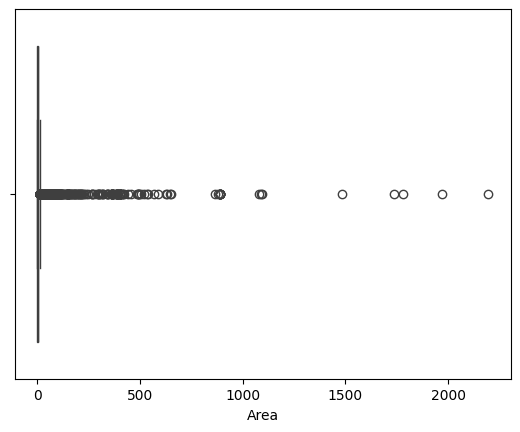

In [34]:
sns.boxplot(x=df1['Area'])

In [35]:
# Ordenar pelas maiores volumes
df1.sort_values(by='Area', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows
37458,1681803,Ss_30_12,768.50,2195.726067,Non Load-Bearing,1.63,None,0.35000000000000003,4491.060354742574,176.5828569266551,None,None,None,Piso -1,None,None,None,None,32,100.117097,0.35,24.215651,9.751656837293295,30.06629623701812,22.525000680541993,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
5774,1542773,Ss_30_12_85_18,393.59,1967.967853,Non Load-Bearing,2.05,None,0.2,3976.5436878719515,124.01702399998706,None,None,None,PISO -3,None,None,None,None,6,75.42999999999296,0.19999999999999785,26.089999999996433,-114.39800332031251,55.328925109863285,73.70000143432618,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
5776,1548966,Ss_30_12_85_18,356.01,1780.037166,Non Load-Bearing,2.05,None,0.2,3618.379322669467,181.06607692977394,None,None,None,PISO -1,None,None,None,None,59,75.42999999999297,0.2000000000000065,26.08999999999659,-116.74050544362441,55.684737119540465,79.49999857177735,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
5775,1548936,Ss_30_12_85_18,347.75,1738.743446,Non Load-Bearing,2.05,None,0.2,3528.959845243135,159.0837821889595,None,None,None,PISO -2,None,None,None,None,42,75.42999999999303,0.19999999999999785,26.08999999999652,-117.23021017671041,55.79861811843082,76.50000029296875,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
329,1663447,Ss_30_12_85_70,519.73,1484.807282,Load-Bearing,4.167618,None,0.35000000000000003,3064.442662287986,177.27569106195332,None,None,None,3 STR - Piso 0,None,None,None,None,311,53.395767,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
37444,352433,Ss_30_12,459.22,1093.383416,Non Load-Bearing,1.63,None,0.42000000000000004,2340.000978599958,234.69805167966328,None,None,None,Piso 2,None,None,None,None,98,91.469776,0.42,15.403284,5.967871893091103,24.445143062059703,32.390000857543946,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
37465,2717318,Ss_30_12,456.34,1086.518412,Non Load-Bearing,1.63,None,0.42000000000000004,2328.725163439616,236.7452827815059,None,None,None,Piso 1,None,None,None,None,104,91.469776,0.42,15.40323,5.692641646711649,24.437026370731893,29.089999960327148,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
37455,1460272,Ss_30_12,453.05,1078.701666,Non Load-Bearing,1.63,None,0.42000000000000004,2321.985057483911,254.75270478615602,None,None,None,Piso 0,None,None,None,None,127,91.516833,0.42,15.759432,5.43447320427848,24.052352459955493,25.789999063110354,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
7698,1926684,Ss_30_12_85_18,213.24,888.491997,Load-Bearing,1.450001,None,0.23999999463558197,1826.3195017209202,128.16517330955105,None,None,None,Piso -3,None,None,None,None,41,50.807,0.24,19.855,23.062192254847975,17.68460667126153,101.3799979248047,None,None,Modelo_Quandrante_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0
7700,1927730,Ss_30_12_85_18,213.24,888.491997,Load-Bearing,1.450001,None,0.23999999463558197,1826.3195017209202,128.16517330955105,None,None,None,Piso -3,None,None,None,None,41,50.807,0.24,19.855,23.062192254847975,17.68460667126153,107.18000203857423,None,None,Modelo_Quandrante_EST,0,Ss_30,Ss_3

### 2.5.3 Análise de valores = 0

In [36]:
df1[df1['Area'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows
977,1824674,Ss_20_30_75_80,0.01,0.0,None,2.575,None,None,None,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.0,None,2.575,None,None,None,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.0,None,2.575,None,None,None,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.0,None,2.575,None,None,None,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.0,None,2.575,None,None,None,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35055,1437083,Ss_20_20_75_80,0.00,0.0,None,3.0,None,None,None,None,None,None,None,,None,None,None,None,None,3.0,0.0889,0.0889,None,None,None,2.9670559342775957e-13,0,Pilot6_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0
35056,1437167,Ss_20_20_75_80,0.00,0.0,None,3.0,None,None,None,None,None,None,None,,None,None,None,None,None,3.0,0.0889,0.0889,None,None,None,2.9670559342775957e-13,0,Pilot6_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0
35057,1437215,Ss_20_20_75_80,0.00,0.0,None,3.0,None,None,None,None,None,None,None,,None,None,None,None,None,3.0,0.0889,0.0889,None,None,None,2.9670559342775957e-13,0,Pilot6_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0
35058,1437249,Ss_20_20_75_80,0.00,0.0,None,3.0,None,None,None,None,None,None,None,,None,None,None,None,None,3.0,0.0889,0.0889,None,None,None,2.967055934277598e-13,0,Pilot6_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0


### 2.5.4 Arredondar c/ 2 casas decimais

In [37]:
df1["Area"] = df1["Area"].round(2)

## 2.6 load_bearing_status

### 2.6.1 Análise de valores

In [38]:
df1['load_bearing_status'].value_counts()

load_bearing_status
None                12047
Non Load-Bearing     6249
Load-Bearing          452
Name: count, dtype: int64

### 2.6.2 Replace None

In [39]:
# Função para aplicar a transformação de maiúsculas e substituições
def aplicar_transformacoes(col):

    # Substituições específicas
    col = col.replace("None", "Non Load-Bearing")

    return col

# Aplicar as transformações
colunas = ['load_bearing_status']
for col in colunas:
    df1[col] = aplicar_transformacoes(df1[col])

df1['load_bearing_status'].value_counts()

load_bearing_status
Non Load-Bearing    18296
Load-Bearing          452
Name: count, dtype: int64

### 2.6.3 Tornar uma variável binária

In [40]:
# load_bearing_status é uma variável textual do Revit: "Bearing", "Non-Bearing", None, etc.
# Convertemos para binário: 1 = elemento portante, 0 = não portante ou desconhecido

# Verificar os valores únicos antes da conversão
print("Valores únicos antes da conversão:")
print(df1['load_bearing_status'].value_counts(dropna=False))

# Normalizar: strip de espaços + minúsculas → mapeamento para 0/1
df1['load_bearing_status_binary'] = (
    df1['load_bearing_status']
    .str.strip()                              # remover espaços em branco no início/fim
    .str.lower()                              # converter para minúsculas para uniformizar
    .map({'bearing': 1, 'non-bearing': 0})    # mapear: bearing=1, non-bearing=0, tudo o resto=NaN
    .fillna(0)                                # valores desconhecidos/None tratados como não-portante
    .astype(int)
)

print("\nDistribuição após conversão:")
print(df1['load_bearing_status_binary'].value_counts())


Valores únicos antes da conversão:
load_bearing_status
Non Load-Bearing    18296
Load-Bearing          452
Name: count, dtype: int64

Distribuição após conversão:
load_bearing_status_binary
0    18748
Name: count, dtype: int64


## 2.7 Length

In [41]:
colunas = ['Length', 'Height', 'Thickness/Width']

for coluna in colunas:
    # Converter para float, erros viram NaN
    df1[coluna + '_float'] = pd.to_numeric(df1[coluna], errors='coerce')
    count_zero = (df1[coluna + '_float'] == 0).sum()
    count_nan = df1[coluna + '_float'].isna().sum()
    print(f"Coluna: {coluna}")
    print(f"  0: {count_zero}")
    print(f"  NaN (inclui 'None' e não numéricos): {count_nan}\n")

Coluna: Length
  0: 0
  NaN (inclui 'None' e não numéricos): 6249

Coluna: Height
  0: 40
  NaN (inclui 'None' e não numéricos): 5567

Coluna: Thickness/Width
  0: 55
  NaN (inclui 'None' e não numéricos): 5116



In [42]:
df1.drop(columns=['Length_float', 'Height_float', 'Thickness/Width_float'], inplace=True)

### 2.7.1 Análise de valores

In [43]:
df1['Length'].value_counts()

Length
None        6249
2.05        1893
2.575        617
1.63         506
1.450001     432
            ... 
6.851891       1
3.054999       1
1.4            1
0.995741       1
0.216          1
Name: count, Length: 4451, dtype: int64

In [44]:
df1['Length'].describe()

count     18748
unique     4451
top        None
freq       6249
Name: Length, dtype: object

In [45]:
df1['Length'] = pd.to_numeric(df1['Length'], errors='coerce')
df1['Length'].isnull().mean() * 100

33.33155536590569

In [46]:
df1.describe()

,Volume,Area,Length,is_rare_class,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
count,18748.000000,18748.000000,12499.000000,18748.0,18748.000000,18748.000000,18748.000000,18748.000000,18748.000000,18748.000000,18748.000000,18748.000000,18748.000000,18748.000000,18748.000000,18748.000000,18748.0
mean,1.834473,7.385276,3.407208,0.0,0.877960,6.074461,0.337263,0.066140,0.021282,0.000640,0.004214,0.083156,0.008108,0.112652,0.336143,0.030403,0.0
std,15.693981,47.708932,5.024137,0.0,0.621136,3.265366,0.472788,0.248534,0.144328,0.025292,0.064778,0.276125,0.089678,0.316175,0.472401,0.171699,0.0
min,0.000000,0.000000,0.009962,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
25%,0.000000,0.010000,1.500000,0.0,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
50%,0.080000,1.470000,2.050000,0.0,1.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0
75%,0.630000,4.900000,3.500000,0.0,1.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0
max,835.730000,2195.730000,75.380000,0.0,5.000000,16.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.0


### 2.7.2 Estudo de outliers

<Axes: xlabel='Length'>

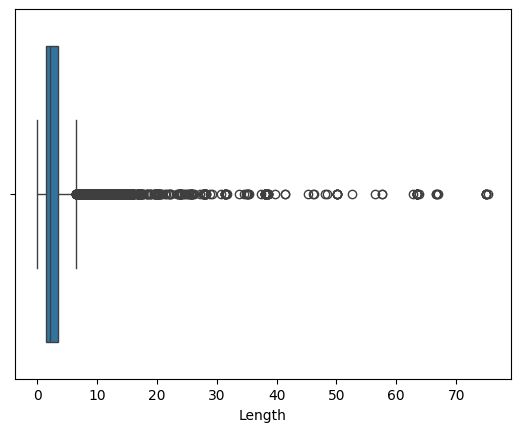

In [47]:
sns.boxplot(x=df1['Length'])

In [48]:
# Ordenar pelas maiores volumes
df1.sort_values(by='Length', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
2653,1543186,Ss_25_13_50,104.84,237.10,Non Load-Bearing,75.380000,2.5390796627042063,0.44999999999999996,554.4423159733082,115.88467948102405,PISO -1,Up to level: PISO 0_L01-A,0.0,None,None,0.0,None,-4.839062484052193e-15,29,75.42999999986202,3.5999999999999788,0.4500000000010326,-111.75407582492267,68.14981034171345,81.22975677212139,3.2178593388602265e-15,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
5378,8341071,Ss_25_13_50,95.04,211.20,Non Load-Bearing,74.980000,2.8000000000000047,0.44999999999999996,492.8147878152937,91.08033599995147,PISO -3,Up to level: PISO -2,0.0,None,None,0.0,None,6.497202775790357e-15,6,75.429999999993,2.799999999999996,0.4500000000002442,-114.39800332031251,68.14892398681641,75.20000057373048,3.2350258330603172e-15,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
2650,1542874,Ss_25_13_50,93.47,211.20,Non Load-Bearing,74.980000,2.799999999999996,0.44999999999999996,499.53478492195427,104.56773599995174,PISO -2,Up to level: PISO -1,0.0,None,None,0.0,None,-0.2,18,75.42999999999302,2.799999999999996,0.4500000000002442,-114.72356189152683,68.14976271611071,77.99999943237304,3.2350258330603172e-15,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
2652,1543115,Ss_25_13_50,134.54,299.15,Non Load-Bearing,74.980000,3.989745623114483,0.44999999999999996,669.8307363029431,96.18237786365279,PISO -1,Up to level: PISO 0_L02,0.0,None,None,-0.20974562311449338,None,-0.019999999999999785,10,75.20499999999299,3.989745623114483,0.45000000000020957,-114.16478000303731,42.508905473064345,81.38412007712539,3.1415926535897905,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
2649,1542866,Ss_25_13_50,101.83,226.29,Non Load-Bearing,74.980000,3.211086872436025,0.44999999999999996,523.166774747042,47.81092799999575,PISO -2,Up to level: PISO -1,0.0,None,None,-0.21108687243602278,None,0.0,8,75.429999999993,3.0110868724360187,0.4500000000002182,-114.39800332031251,42.508926232910156,77.90000088500977,3.1415926535897905,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
2646,1542586,Ss_25_13_50,88.25,196.12,Non Load-Bearing,74.980000,2.799999999999996,0.44999999999999996,462.4628008835449,47.451263999995724,PISO -3,Up to level: PISO -2,0.0,None,None,0.0,None,0.0,7,75.42999999999299,2.599999999999998,0.4500000000002182,-114.39800332031251,42.508926232910156,75.10000202636719,3.1415926535897905,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
1771,1757481,Ss_20_20_75_15,4.02,33.53,Non Load-Bearing,66.938188,None,None,67.05815862767837,81.73295820001324,None,None,None,,None,None,None,None,6,66.938188,1.19,0.2,1010.7500258789063,289.94296267089845,96.920000390625,3.1060071476428555e-15,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
1772,1757706,Ss_20_20_75_15,4.01,33.48,Non Load-Bearing,66.838188,None,None,66.95815867073726,81.51959820001719,None,None,None,,None,None,None,None,6,66.838188,1.19,0.2,1010.7000196289063,275.6648574462891,96.920000390625,3.110654202363692e-15,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
1426,1572211,Ss_20_20_75_15,26.84,110.30,Non Load-Bearing,66.713188,None,None,220.60092376886337,61.406208596409314,No

### 2.7.3 Arredondar c/ 2 casas decimais

In [49]:
df1["Length"] = df1["Length"].round(2)

## 2.8 Height

### 2.8.1 Análise de valores

In [50]:
df1['Height'].value_counts()

Height
None                   5567
0.15399999999999964    4071
2.1                    1110
2.660000000000002       469
2.650000000000004       400
                       ... 
2.8749999999999876        1
2.1099999999999537        1
1.0600000000000027        1
1.399999999999971         1
2.0000000000003855        1
Name: count, Length: 586, dtype: int64

### 2.8.2 Replace None -> 0

In [51]:
df1['Height'] = df1['Height'].replace('None', np.nan)
df1['Height'].isnull().mean() * 100

29.693834008960955

In [52]:
df1['Height'] = df1['Height'].replace(np.nan , 0)
df1['Height'] = df1['Height'].astype('float')
df1['Height'].describe()

count    18748.000000
mean         1.233172
std          1.798079
min          0.000000
25%          0.000000
50%          0.154000
75%          2.650000
max         32.700000
Name: Height, dtype: float64

### 2.8.3 Análise de valores = 0

In [53]:
df1[df1['Height'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
250,1306680,Ss_30_12_85_70,129.57,370.21,Load-Bearing,4.17,0.0,0.35000000000000003,771.9378580874436,45.39538345404171,None,None,None,3 STR - Piso 0,None,None,None,None,55,27.75,0.35,13.359996,1030.0941113995514,282.8376130075494,83.83499908447266,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
251,1306768,Ss_30_12_05,68.43,342.14,Load-Bearing,4.17,0.0,0.2,704.4002280199712,29.30235693153484,None,None,None,4 STR - Piso 1,None,None,None,None,20,28.0,0.2,13.359996,1030.9771866486471,282.5956018986259,86.93000086669922,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
252,1306782,Ss_30_12_05,67.69,338.47,Load-Bearing,4.17,0.0,0.2,718.0873473366955,74.83515598898916,None,None,None,5 STR - Piso 2,None,None,None,None,37,27.95,0.2,13.609996,1030.6749778762403,282.6414050313977,89.99000013427735,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
253,1306802,Ss_30_12_05,63.67,318.36,Load-Bearing,4.17,0.0,0.2,657.0169356484246,32.90897814686379,None,None,None,4 STR - Piso 1,None,None,None,None,15,23.792046,0.2,13.594996,1004.1025665236061,282.819141232684,86.93000086669922,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
254,1306991,Ss_30_12_05,38.70,193.52,Load-Bearing,4.17,0.0,0.2,398.20035505519235,21.13740576782895,None,None,None,5 STR - Piso 2,None,None,None,None,6,12.975,0.2,14.91501,987.464042578125,282.2580550048828,89.99000013427735,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38001,1722681,Ss_35_10,0.00,1.49,Non Load-Bearing,0.71,0.0,None,None,None,None,None,None,None,Piso 0,0.0,Piso 1,0.0,None,2.997569,3.3,4.03173,None,None,None,None,None,SEC1_ARQ,0,Ss_35,Ss_35_10,3,14,Stairs,0,0,0,0,1,0,0,0,0,0,0
38002,3312766,Ss_35_10,0.00,1.49,Non Load-Bearing,0.71,0.0,None,None,None,None,None,None,None,Piso 0,-0.05,Piso 1,1.4,None,2.01803,4.75,1.527643,None,None,None,None,None,SEC1_ARQ,0,Ss_35,Ss_35_10,3,14,Stairs,0,0,0,0,1,0,0,0,0,0,0
38003,3367980,Ss_35_10,0.00,1.49,Non Load-Bearing,0.71,0.0,None,None,None,None,None,None,None,Piso -1,-1.35,None,0.44999999999999996,None,1.55,1.0,9.4,None,None,None,None,None,SEC1_ARQ,0,Ss_35,Ss_35_10,3,14,Stairs,0,0,0,0,1,0,0,0,0,0,0
38004,4174963,Ss_35_10,0.00,1.49,Non Load-Bearing,0.71,0.0,None,None,None,None,None,None,None,Piso -1,-1.05,Piso -1,-0.35,None,5.25,0.8,1.8,None,None,None,None,None,SEC1_ARQ,0,Ss_35,Ss_35_10,3,14,Stairs,0,0,0,0,1,0,0,0,0,0,0


### 2.8.4 Análise de outliers

<Axes: xlabel='Height'>

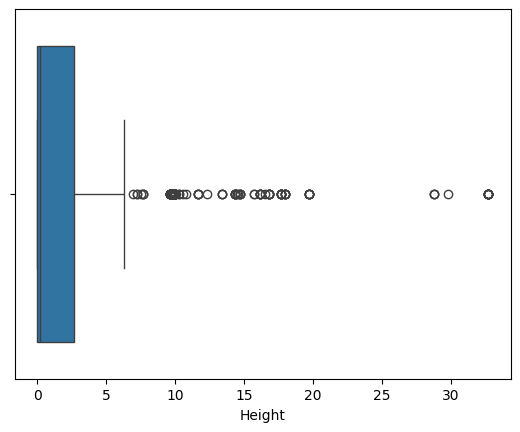

In [54]:
sns.boxplot(x=df1['Height'])

In [55]:
# Ordenar pelas maiores 
df1.sort_values(by='Height', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7672,1908335,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.05,32.70,0.2,147.96993629057866,12.466320000000216,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,2.15,32.7,0.2,15.036142094421388,22.940003256225587,99.34520119628907,1.605812718569185e-13,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7679,1908353,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.2,147.96990339057334,32.52215939039986,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.2,32.7,2.149999,37.15311244812012,21.81500099487305,99.34520119628907,1.570796326794941,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7670,1908331,Ss_25_11_16_70,13.57,67.85,Load-Bearing,2.12,32.70,0.2,149.61506718224476,12.374882438399993,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,2.225,32.7,0.2,12.973641242980957,22.940003256225587,99.34520119628907,2.0791048882529185e-13,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7676,1908347,Ss_25_11_16_70,13.57,67.85,Load-Bearing,2.12,32.70,0.2,149.61506718222452,12.374882438399622,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,2.225,32.7,0.2,38.09061336364746,22.940000930786134,99.34520119628907,3.141592653589638,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7675,1908343,Ss_25_11_16_70,18.55,67.03,Load-Bearing,2.05,32.70,0.2767910000000029,153.30684253914524,22.602010574400005,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.276791,32.7,2.049999,33.61650622558594,21.814999832153323,99.34520119628907,1.5707963267948966,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7671,1908333,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.2,147.96990339059795,32.52215939040032,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.2,32.7,2.15,13.911142158508301,21.815003320312503,99.34520119628907,1.570796326794819,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7678,1908351,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.2,147.96990339059013,32.52215939040018,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.2,32.7,2.15,35.103111996459965,21.81500099487305,99.34520119628907,1.5707963267949026,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7674,1908341,Ss_25_11_16_70,25.80,93.20,Load-Bearing,3.10,32.70,0.2767910000000029,206.06988328241218,11.704321219199969,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.276791,32.7,3.099997,33.61650622558594,24.265000286865234,99.34520119628907,1.5707963267948883,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7673,1908337,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.2,147.96990339057632,32.52215939039992,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,0.2,32.7,2.149999,15.961142028808595,21.815003320312503,99.34520119628907,1.5707963267949017,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7677,1908349,Ss_25_11_16_70,13.41,67.04,Load-Bearing,2.05,32.70,0.2,147.97000209054397,12.466321219200099,Piso 0,Up to level: Piso 11,0.0,None,None,-0.3048,None,-0.3048,6,2.150001,32.7,0.2,36.02811251220703,22.940000930786

### 2.8.5 Arredondar c/ 2 casas decimais

In [56]:
df1["Height"] = df1["Height"].round(2)

## 2.9 Thickness/Width

### 2.9.1 Análise de valores

In [57]:
df1['Thickness/Width'].value_counts()

Thickness/Width
None                   5116
0.04400000000000028    3920
0.14999999999999997    1917
0.2                     663
0.15000000000000002     477
                       ... 
1.4345192787066894        1
1.48000000000001          1
3.799999952316284         1
4.800000190734863         1
0.9000000000000011        1
Name: count, Length: 267, dtype: int64

### 2.9.2 Replace None -> 0

In [58]:
df1['Thickness/Width'] = df1['Thickness/Width'].replace('None', np.nan)
df1['Thickness/Width'].isnull().mean() * 100

27.288244079368468

In [59]:
df1['Thickness/Width'] = df1['Thickness/Width'].replace(np.nan , 0)
df1['Thickness/Width'] = df1['Thickness/Width'].astype('float')
df1['Thickness/Width'].describe()

count    18748.000000
mean         0.244527
std          0.954965
min          0.000000
25%          0.000000
50%          0.044000
75%          0.200000
max         52.250000
Name: Thickness/Width, dtype: float64

### 2.9.3 Análise valores = 0

In [60]:
df1[df1['Thickness/Width'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
268,1401380,Ss_30_12_05,6.82,36.36,Load-Bearing,4.17,0.00,0.0,83.84089683431915,27.636364813932747,None,None,None,4 STR - Piso 1,None,None,None,None,6,28.4,0.2,1.28,1101.9756389648437,265.3128021565134,86.2538880411255,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
269,1401653,Ss_30_12_05,6.60,35.22,Load-Bearing,4.17,0.00,0.0,81.55412141723022,27.58760161342354,None,None,None,5 STR - Piso 2,None,None,None,None,6,28.4,0.2,1.24,1101.9756389648437,270.75578357400855,89.58388943272706,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
412,1306690,Ss_20_30_75_15,0.48,4.24,Non Load-Bearing,4.17,0.00,0.0,8.473196351809372,11.643360000000172,None,None,None,3 STR - Piso 0,3 STR - Piso 0,-0.35,6 STR - Piso 3,0.0,12,0.23,9.48,0.23,1019.5941372070313,283.66054614257814,88.44966705520649,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
413,1306692,Ss_20_30_75_15,0.46,4.20,Non Load-Bearing,4.17,0.00,0.0,8.394996385478885,10.891564286612569,None,None,None,3 STR - Piso 0,3 STR - Piso 0,-0.35,6 STR - Piso 3,0.0,18,0.23,9.48,0.23,1023.0941282226563,283.66054614257814,88.4842830799876,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
414,1306694,Ss_20_30_75_15,0.46,4.20,Non Load-Bearing,4.17,0.00,0.0,8.394996385478887,10.891564286612569,None,None,None,3 STR - Piso 0,3 STR - Piso 0,-0.35,6 STR - Piso 3,0.0,18,0.23,9.48,0.23,1026.5941192382813,283.66054614257814,88.4842830799876,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38476,4948569,Ss_25_30_20_30,0.00,4.22,Non Load-Bearing,2.00,2.11,0.0,21.305490826780243,0.0,Piso 0,Up to level: Piso 0,None,None,None,-0.009999999999997726,None,2.099999999999996,0,2.228974,2.11,1.676397,-16.041883704335667,-5.860152484038152,44.345000207519675,2.757620218151045,0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0,0
38477,4955627,Ss_25_30_20_30,0.00,2.38,Non Load-Bearing,1.10,2.17,0.0,12.071619802484483,0.0,Piso 0,Up to level: Piso 0,None,None,None,0.0,None,2.1750000000000034,0,1.337378,2.175,1.389873,-9.89914454886399,-6.4359699106378905,44.387499938964766,1.9547687622336476,0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0,0
38478,4955902,Ss_25_30_20_30,0.00,1.37,Non Load-Bearing,1.09,2.10,0.0,6.960106193133264,0.0,Piso 0,Up to level: Beirado 1,None,None,None,2.1750000000000034,None,0.0,0,1.33588,2.100339,1.386164,-9.92398473696752,-6.4278776322521285,46.1039398632287,1.9547687622336467,0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0,0
38483,5055020,Ss_25_30_20_30,0.00,15.95,Non Load-Bearing,5.37,2.10,0.0,80.16565199139134,0.0,Piso 0,Unconnected,None,None,None,0.0,None,-0.7880999999999999,0,2.938821,3.540897,5.353584,-21.580054161592663,-5.231103149597561,44.803327737103615,1.9547687622336472,0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.9.4 Estudo de outliers

<Axes: xlabel='Thickness/Width'>

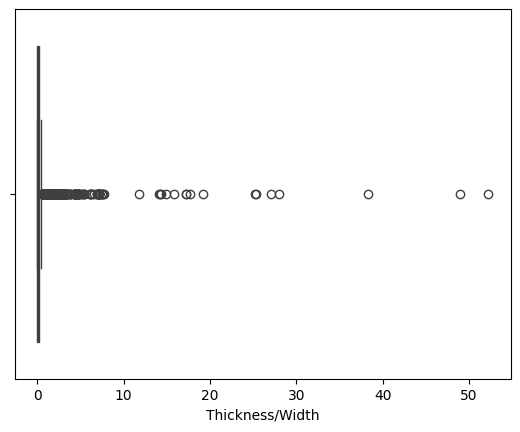

In [61]:
sns.boxplot(x=df1['Thickness/Width'])

In [62]:
# Ordenar pelas maiores volumes
df1.sort_values(by='Thickness/Width', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
2617,1740263,Ss_20_05_15_70,61.65,82.21,Non Load-Bearing,1.00,0.0,52.250000,245.14554633584618,62.0943485791413,None,None,None,2 STR - Piso -1,None,None,None,None,6,52.25,0.75,1.573308,1075.500641015625,296.31258317871095,80.28499716796875,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
8576,1905554,Ss_20_05_15_70,29.36,48.93,Non Load-Bearing,3.15,0.0,48.930000,157.77593542594002,60.16599639387131,None,None,None,Fund,None,None,None,None,6,48.93,0.6,1.0,24.46499970703125,0.5000000038146973,73.00000462646484,None,None,Modelo_Quandrante_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2616,1740195,Ss_20_05_15_70,45.93,61.24,Non Load-Bearing,1.00,0.0,38.275000,182.29242151279638,48.0212400000001,None,None,None,2 STR - Piso -1,None,None,None,None,6,38.275,0.75,1.6,1082.4881214843751,280.72923669433595,80.28499716796875,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2612,1727372,Ss_20_05_15_70,33.54,44.72,Non Load-Bearing,1.00,0.0,27.950000,133.7649424066213,36.22548000000031,None,None,None,3 STR - Piso 0,None,None,None,None,6,27.95,0.75,1.6,1029.319125,275.0155575439453,83.02499736328126,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2615,1731166,Ss_20_05_15_70,32.46,43.28,Non Load-Bearing,1.00,0.0,27.050000,129.53494422787367,33.14700000000017,None,None,None,3 STR - Piso 0,None,None,None,None,6,27.05,0.75,1.6,1029.7691440429687,290.5886069824219,83.02499736328126,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
34643,766598,Ss_20_05_15,18.51,123.39,Non Load-Bearing,11.80,0.0,25.378673,256.3977582976525,39.42702960993565,None,None,None,Level 2,None,None,None,None,10,25.37867338660245,0.15000000000000002,6.850000000000022,9.575671545580137,17.953315210914244,2.924999949645996,None,None,Pilot6_ARQ,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2592,1642415,Ss_20_05_15_70,16.41,32.83,Non Load-Bearing,1.00,0.0,25.251200,92.20428030083711,32.31026303999977,None,None,None,2 STR - Piso -1,None,None,None,None,6,25.2512,0.5,1.3,1071.8750390625,299.9488635498047,80.40999884033204,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2640,2227292,Ss_20_05_15_70,26.68,76.23,Non Load-Bearing,1.00,0.0,19.151500,168.65338843051697,18.877420205739114,None,None,None,2 STR - Piso -1,None,None,None,None,6,19.1515,0.35,3.980397,1049.6736779296875,301.5890611083984,80.64499844970703,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2641,2230483,Ss_20_05_15_70,7.49,14.98,Non Load-Bearing,1.00,0.0,17.625000,48.43747914492446,22.387560000000057,None,None,None,2 STR - Piso -1,None,None,None,None,6,17.625,0.5,0.85,1093.3131351562502,299.72386333007813,80.40999884033204,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
2561,1606712,Ss_20_05_15_70,24.51,24.51,Non Load-Bearing,1.00,0.0,17.173046,88.17094624436328,26.088497923282638,None,None,None,3 STR - Piso 0,None,None,None,None,14,1.6,1.0,17.173046,1044.0941487304688,283.27906401242205,82.90000034179688,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0


### 2.9.5 Arredondar c/ 2 casas decimais

In [63]:
df1["Thickness/Width"] = df1["Thickness/Width"].round(2)

## 2.10 Total_Surface_Ara

### 2.10.1 Análise de valores

In [64]:
df1['Total_Surface_Area'].value_counts()

Total_Surface_Area
None                  8859
0.9679995832213807      68
1.9723002308131132      60
54.719976439952774      42
31.03998663552873       38
                      ... 
6.808496553678845        1
52.50156271309932        1
31.13095672098453        1
31.075706744772475       1
1.7885080853252673       1
Name: count, Length: 7058, dtype: int64

### 2.10.2 Replace None -> 0

In [65]:
df1['Total_Surface_Area'] = df1['Total_Surface_Area'].replace('None', np.nan)
df1['Total_Surface_Area'].describe()

count                   9889
unique                  7057
top       0.9679995832213807
freq                      68
Name: Total_Surface_Area, dtype: object

In [66]:
df1['Total_Surface_Area'] = df1['Total_Surface_Area'].replace(np.nan , 0)
df1['Total_Surface_Area'] = df1['Total_Surface_Area'].astype('float')
df1['Total_Surface_Area'].describe()

count    18748.000000
mean        15.595011
std         99.685859
min          0.000000
25%          0.000000
50%          1.221889
75%         10.388417
max       4491.060355
Name: Total_Surface_Area, dtype: float64

### 2.10.3 Análise valores = 0

In [67]:
df1[df1['Total_Surface_Area'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,None,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,None,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,None,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,None,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,None,None,None,None,Piso 0,None,None,None,None,None,1.265828,2.385,1.212781,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.10.4 Análise de outliers

<Axes: xlabel='Total_Surface_Area'>

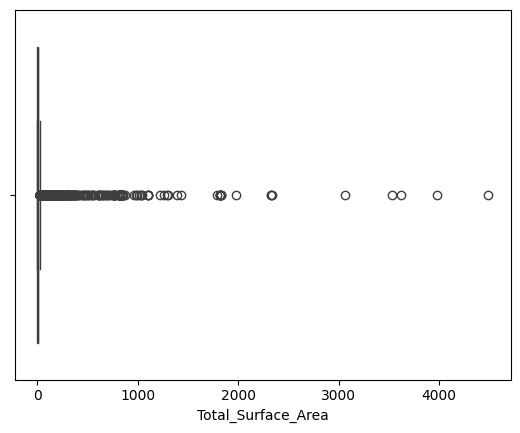

In [68]:
sns.boxplot(x=df1['Total_Surface_Area'])

In [69]:
# Ordenar pelas maiores
df1.sort_values(by='Total_Surface_Area', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
37458,1681803,Ss_30_12,768.50,2195.73,Non Load-Bearing,1.63,0.0,0.35,4491.060355,176.5828569266551,None,None,None,Piso -1,None,None,None,None,32,100.117097,0.35,24.215651,9.751656837293295,30.06629623701812,22.525000680541993,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5774,1542773,Ss_30_12_85_18,393.59,1967.97,Non Load-Bearing,2.05,0.0,0.20,3976.543688,124.01702399998706,None,None,None,PISO -3,None,None,None,None,6,75.42999999999296,0.19999999999999785,26.089999999996433,-114.39800332031251,55.328925109863285,73.70000143432618,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5776,1548966,Ss_30_12_85_18,356.01,1780.04,Non Load-Bearing,2.05,0.0,0.20,3618.379323,181.06607692977394,None,None,None,PISO -1,None,None,None,None,59,75.42999999999297,0.2000000000000065,26.08999999999659,-116.74050544362441,55.684737119540465,79.49999857177735,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5775,1548936,Ss_30_12_85_18,347.75,1738.74,Non Load-Bearing,2.05,0.0,0.20,3528.959845,159.0837821889595,None,None,None,PISO -2,None,None,None,None,42,75.42999999999303,0.19999999999999785,26.08999999999652,-117.23021017671041,55.79861811843082,76.50000029296875,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
329,1663447,Ss_30_12_85_70,519.73,1484.81,Load-Bearing,4.17,0.0,0.35,3064.442662,177.27569106195332,None,None,None,3 STR - Piso 0,None,None,None,None,311,53.395767,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37444,352433,Ss_30_12,459.22,1093.38,Non Load-Bearing,1.63,0.0,0.42,2340.000979,234.69805167966328,None,None,None,Piso 2,None,None,None,None,98,91.469776,0.42,15.403284,5.967871893091103,24.445143062059703,32.390000857543946,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37465,2717318,Ss_30_12,456.34,1086.52,Non Load-Bearing,1.63,0.0,0.42,2328.725163,236.7452827815059,None,None,None,Piso 1,None,None,None,None,104,91.469776,0.42,15.40323,5.692641646711649,24.437026370731893,29.089999960327148,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37455,1460272,Ss_30_12,453.05,1078.70,Non Load-Bearing,1.63,0.0,0.42,2321.985057,254.75270478615602,None,None,None,Piso 0,None,None,None,None,127,91.516833,0.42,15.759432,5.43447320427848,24.052352459955493,25.789999063110354,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37457,1470420,Ss_30_12,835.73,879.72,Non Load-Bearing,1.63,0.0,0.95,1973.563913,144.35544447108205,None,None,None,Piso 0,None,None,None,None,27,98.138589,0.95,12.784039,10.41304194634937,36.07464150409382,25.474999685668948,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
7699,1927216,Ss_30_12_85_18,213.24,888.49,Load-Bearing,1.45,0.0,0.24,1826.319502,128.16517330955105,None,None,None,Piso -3,None,None,None,None,41,50.807,0.24,19.855,23.062192254847975,17.68460667126153,104.28000230712891,None,None,Modelo_Quandrante_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0


### 2.10.5 Arredondar c/ 2 casas decimais

In [70]:
df1["Total_Surface_Area"] = df1["Total_Surface_Area"].round(2)

## 2.11 Total_Edge_Length

### 2.11.1 Análise de valores

In [71]:
df1['Total_Edge_Length'].value_counts()

Total_Edge_Length
None                  8859
0.0                    146
13.144560959999854      60
23.77439999999997       37
1.5361919999999682      35
                      ... 
7.778339708098386        1
8.55862770809841         1
18.60971513766124        1
7.559096870671786        1
2.9267286074834815       1
Name: count, Length: 6769, dtype: int64

### 2.11.2 Replace None -> 0

In [72]:
df1['Total_Edge_Length'] = df1['Total_Edge_Length'].replace('None', np.nan)
df1['Total_Edge_Length'].describe()

count     9889
unique    6768
top        0.0
freq       146
Name: Total_Edge_Length, dtype: object

In [73]:
df1['Total_Edge_Length'] = df1['Total_Edge_Length'].replace(np.nan , 0)
df1['Total_Edge_Length'] = df1['Total_Edge_Length'].astype('float')
df1['Total_Edge_Length'].describe()

count    18748.000000
mean         4.697345
std         11.130592
min          0.000000
25%          0.000000
50%          1.201873
75%          5.596215
max        254.752705
Name: Total_Edge_Length, dtype: float64

### 2.11.3 Análise valores = 0

In [74]:
df1[df1['Total_Edge_Length'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,None,None,None,7 STR - Cobertura,7 STR - Cobertura,1.19,8 STR - Cobertura 1,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,None,None,None,Piso 0,None,None,None,None,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,None,None,None,Piso 0,None,None,None,None,None,1.265828,2.385,1.212781,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.11.4 Análise de outliers

<Axes: xlabel='Total_Edge_Length'>

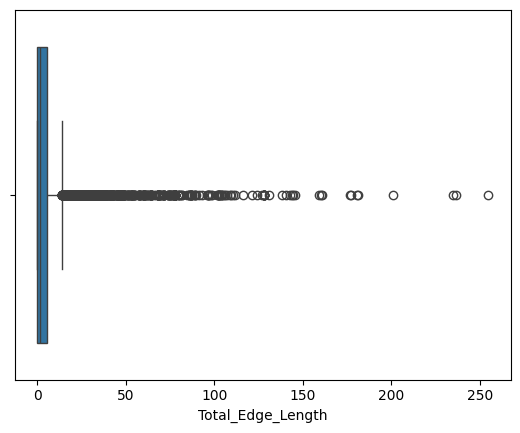

In [75]:
sns.boxplot(x=df1['Total_Edge_Length'])

In [76]:
# Ordenar pelas maiores
df1.sort_values(by='Total_Edge_Length', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_constraint,Top_constraint,Base_extension_distance,Level,Base_level,Base_offset,Top_level,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
37455,1460272,Ss_30_12,453.05,1078.70,Non Load-Bearing,1.63,0.0,0.42,2321.99,254.752705,None,None,None,Piso 0,None,None,None,None,127,91.516833,0.42,15.759432,5.43447320427848,24.052352459955493,25.789999063110354,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37465,2717318,Ss_30_12,456.34,1086.52,Non Load-Bearing,1.63,0.0,0.42,2328.73,236.745283,None,None,None,Piso 1,None,None,None,None,104,91.469776,0.42,15.40323,5.692641646711649,24.437026370731893,29.089999960327148,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37444,352433,Ss_30_12,459.22,1093.38,Non Load-Bearing,1.63,0.0,0.42,2340.00,234.698052,None,None,None,Piso 2,None,None,None,None,98,91.469776,0.42,15.403284,5.967871893091103,24.445143062059703,32.390000857543946,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
2622,1785701,Ss_20_05_15_70,64.35,0.00,Non Load-Bearing,1.00,0.0,0.00,405.23,201.014772,None,None,None,,None,None,None,None,42,50.540211,3.89,48.355298,990.2560673600768,300.21750564441317,87.23290666202466,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
5776,1548966,Ss_30_12_85_18,356.01,1780.04,Non Load-Bearing,2.05,0.0,0.20,3618.38,181.066077,None,None,None,PISO -1,None,None,None,None,59,75.42999999999297,0.2000000000000065,26.08999999999659,-116.74050544362441,55.684737119540465,79.49999857177735,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
7703,1929578,Ss_30_12_85_18,106.38,443.23,Load-Bearing,1.45,0.0,0.24,958.79,180.688358,None,None,None,Piso -3,None,None,None,None,67,48.755,0.24,15.830001,21.47534309999629,20.977104790563647,113.03000310058594,None,None,Modelo_Quandrante_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
329,1663447,Ss_30_12_85_70,519.73,1484.81,Load-Bearing,4.17,0.0,0.35,3064.44,177.275691,None,None,None,3 STR - Piso 0,None,None,None,None,311,53.395767,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37458,1681803,Ss_30_12,768.50,2195.73,Non Load-Bearing,1.63,0.0,0.35,4491.06,176.582857,None,None,None,Piso -1,None,None,None,None,32,100.117097,0.35,24.215651,9.751656837293295,30.06629623701812,22.525000680541993,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
2623,1798832,Ss_20_05_15,24.34,0.00,Non Load-Bearing,1.00,0.0,0.00,180.11,161.060729,None,None,None,,None,None,None,None,333,43.140167,0.6,21.824702,991.4506372152257,319.52929056235763,86.25000052690908,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
5779,1712105,Ss_30_12_85_18,141.60,363.09,Non Load-Bearing,2.05,0.0,0.39,822.13,160.200820,None,None,None,PISO 10,None,None,None,None,88,48.929999999862,0.38999999999999796,16.029999999999976,-127.91788527457555,64.98722085636669,113.00499997558595,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0


### 2.11.5 Arredondar c/ 2 casas decimais

In [77]:
df1["Total_Edge_Length"] = df1["Total_Edge_Length"].round(2)

## 2.12 Base_constraint

### 2.12.1 Análise de valores

In [78]:
df1['Base_constraint'].value_counts()

Base_constraint
None                   12457
Piso 0                   944
Piso 1                   644
Piso 2                   609
Piso -1                  372
PISO 9                   270
PISO 1                   261
PISO 4                   260
PISO 2                   260
PISO 6                   260
PISO 3                   258
PISO 5                   258
PISO 8                   252
PISO 7                   251
PISO 10                  190
PISO 0_L02               174
PISO -2                  119
PISO -3                  117
Laje pavimento           110
2 STR - Piso -1          110
COBERTURA                 82
PISO -1                   71
3 STR - Piso 0            61
Piso 3                    60
4 STR - Piso 1            48
Cota 0                    44
Piso -2                   35
NOVO_Piso 2               24
NOVO_Piso 3               23
Tecto Falso               20
Pedra                     16
7 STR - Cobertura         15
1 STR - Piso -2           14
PISO 0_L01-A              1

## 2.13 Top_constraint

### 2.13.1 Análise de valores

In [79]:
df1['Top_constraint'].value_counts()

Top_constraint
None                                12457
Unconnected                          1134
Up to level: Piso 0                   481
Up to level: Piso 1                   365
Up to level: Piso 2                   346
Up to level: Piso 3                   327
Up to level: PISO 10                  270
Up to level: PISO 5                   259
Up to level: PISO 3                   259
Up to level: PISO 7                   259
Up to level: PISO 6                   257
Up to level: PISO 4                   257
Up to level: PISO 2                   257
Up to level: PISO 8                   250
Up to level: PISO 9                   249
Up to level: Beirado 1                212
Up to level: COBERTURA                193
Up to level: PISO 1                   185
Up to level: PISO -1                  120
Up to level: PISO -2                  117
Up to level: 3 STR - Piso 0            78
Up to level: 7 STR - Cobertura         55
Up to level: 5 STR - Piso 2            45
Up to level: PISO 0

### 2.13.2 Apagar até 13º dígito

In [80]:
df1['Top_constraint'] = df1['Top_constraint'].apply(
    lambda x: x[13:] if pd.notna(x) and x != "Unconnected" and x != "None" else x
)

# Mostrar o resultado
print(df1['Top_constraint'].value_counts())

Top_constraint
None                   12457
Unconnected             1134
Piso 0                   481
Piso 1                   365
Piso 2                   346
Piso 3                   327
PISO 10                  270
PISO 5                   259
PISO 3                   259
PISO 7                   259
PISO 6                   257
PISO 4                   257
PISO 2                   257
PISO 8                   250
PISO 9                   249
Beirado 1                212
COBERTURA                193
PISO 1                   185
PISO -1                  120
PISO -2                  117
3 STR - Piso 0            78
7 STR - Cobertura         55
5 STR - Piso 2            45
PISO 0_L01-A              39
NOVO_Piso 3               38
PISO 0_L02                33
2 STR - Piso -1           30
4 STR - Piso 1            27
Piso -1                   26
NOVO_Piso 2               21
Beirado 2                 20
8 STR - Cobertura 1       13
FaceInferiorVigas_3       13
PISO 0_L01-B              11

## 2.14 Base_extension_distance

### 2.14.1 Análise de valores

In [81]:
df1['Base_extension_distance'].value_counts()

Base_extension_distance
None    12592
0.0      6156
Name: count, dtype: int64

Variável vai ser eliminada

In [82]:
df1 = df1.drop(columns=["Base_extension_distance"])

In [83]:
df2 = df1.copy()

## 2.15 Level

### 2.15.1 Análise de valores

In [84]:
df2['Level'].value_counts()

Level
None                   6397
Piso 0                 4644
                       2114
COTA 0                 1761
7 STR - Cobertura       274
3 STR - Piso 0          266
4 STR - Piso 1          205
PISO 9                  183
Piso -1                 174
PISO 6                  173
PISO 0_L02              157
2 STR - Piso -1         155
Piso 1                  148
PISO 1                  140
Piso 2                  140
PISO -3                 134
PISO 10                 132
PISO 7                  131
PISO 3                  128
PISO 4                  128
PISO 2                  128
PISO 8                  127
PISO 5                  127
6 STR - Piso 3           70
Fund                     66
PISO -2                  65
Level 1                  54
5 STR - Piso 2           46
Level 2                  42
Piso -3                  39
Piso -2                  38
Piso 9                   38
PISO -1                  37
1 STR - Piso -2          32
Piso 3                   29
Piso 10       

## 2.16 Base_level

### 2.16.1 Análise de valores

In [85]:
df2['Base_level'].value_counts()

Base_level
None                 17098
7 STR - Cobertura      238
3 STR - Piso 0         191
4 STR - Piso 1         164
2 STR - Piso -1        126
PISO 9                  84
PISO -3                 79
PISO 0_L02              63
PISO 6                  48
6 STR - Piso 3          47
Piso -1                 42
Piso 9                  38
Piso -2                 33
Piso -3                 33
Fund                    33
Piso 0                  31
Piso 1                  30
1 STR - Piso -2         30
Piso 10                 28
Piso 2                  27
Piso 8                  24
Piso 7                  24
Piso 6                  24
Piso 5                  24
Piso 4                  24
Piso 3                  24
PISO -1                 21
5 STR - Piso 2          17
PISO 1                  15
PISO 10                 13
Level Lower             12
PISO -2                 12
Level 2                  9
PISO 0_L01-A             6
Foundation               6
PISO 7                   5
PISO 8           

## 2.17 Top_level

### 2.17.1 Análise de valores

In [86]:
df2['Top_level'].value_counts()

Top_level
None                   17111
7 STR - Cobertura        248
6 STR - Piso 3           225
4 STR - Piso 1           134
8 STR - Cobertura 1       86
3 STR - Piso 0            64
PISO 9                    60
PISO 0_L02                59
PISO 6                    51
PISO 10                   47
COBERTURA                 47
Piso 0                    39
Piso 10                   38
5 STR - Piso 2            36
Piso -1                   35
Piso -2                   33
Piso -3                   33
Piso 1                    31
Piso 2                    30
Piso 11                   28
Piso 3                    27
Piso 7                    24
Piso 6                    24
Piso 8                    24
Piso 5                    24
Piso 4                    24
Piso 9                    24
PISO -1                   22
2 STR - Piso -1           20
PISO 0_L01-B              16
Ref Beam system           15
PISO 1                    14
Top of Parapet            14
PISO -2                   12
PISO

## 2.18 Eliminar variáveis dos pisos

### 2.18.1 Converter para maiúsculas e dar replace no nome dos pisos

In [87]:
# ── NORMALIZAÇÃO DOS NOMES DE PISO ──────────────────────────────────────────
#
# Os nomes de piso variam muito entre projectos (cada grupo nomeou os pisos à sua maneira):
#   "Level 0", "Piso 0", "Rés-do-chão", "RDC", "Nível 1", "Ground Floor", etc.
# Tudo isto se refere ao mesmo piso — sem normalização, seriam tratados como categorias distintas.
#
# Esta célula faz um mapeamento exaustivo de todas as variantes encontradas nos dados
# para um nome canónico padronizado (ex: "Level 0", "Level 1", ..., "Level 15").
#
# Colunas afectadas: Base_constraint, Top_constraint, Level, Base_level, Top_level
# ────────────────────────────────────────────────────────────────────────────

floor_level_map = {
    # ── Piso -1 (cave/estacionamento) ──
    'Piso -1': 'Level -1', 'piso -1': 'Level -1', 'PISO -1': 'Level -1',
    'B1': 'Level -1', 'Cave': 'Level -1', 'Underground': 'Level -1',
    '-1': 'Level -1', '-1 Floor': 'Level -1', 'B1 Floor': 'Level -1',
    'Basement': 'Level -1', 'Basement 1': 'Level -1', 'Level B1': 'Level -1',
    'Nível -1': 'Level -1', 'Nivel -1': 'Level -1',

    # ── Piso 0 (rés-do-chão) ──
    'Piso 0': 'Level 0', 'piso 0': 'Level 0', 'PISO 0': 'Level 0',
    'Level 0': 'Level 0', 'LEVEL 0': 'Level 0', 'level 0': 'Level 0',
    'Rés-do-chão': 'Level 0', 'Res-do-chao': 'Level 0', 'RDC': 'Level 0',
    'Ground Floor': 'Level 0', 'Ground': 'Level 0', '0': 'Level 0',
    'Piso Terreo': 'Level 0', 'Piso Térreo': 'Level 0',
    'Nível 0': 'Level 0', 'Nivel 0': 'Level 0',
    'Piso 00': 'Level 0', '00': 'Level 0',

    # ── Piso 1 ──
    'Piso 1': 'Level 1', 'piso 1': 'Level 1', 'PISO 1': 'Level 1',
    'Level 1': 'Level 1', 'LEVEL 1': 'Level 1', 'level 1': 'Level 1',
    '1st Floor': 'Level 1', 'First Floor': 'Level 1', '1': 'Level 1',
    'Nível 1': 'Level 1', 'Nivel 1': 'Level 1', 'Piso 01': 'Level 1', '01': 'Level 1',

    # ── Piso 2 ──
    'Piso 2': 'Level 2', 'piso 2': 'Level 2', 'PISO 2': 'Level 2',
    'Level 2': 'Level 2', 'LEVEL 2': 'Level 2', 'level 2': 'Level 2',
    '2nd Floor': 'Level 2', 'Second Floor': 'Level 2', '2': 'Level 2',
    'Nível 2': 'Level 2', 'Nivel 2': 'Level 2', 'Piso 02': 'Level 2', '02': 'Level 2',

    # ── Piso 3 ──
    'Piso 3': 'Level 3', 'piso 3': 'Level 3', 'PISO 3': 'Level 3',
    'Level 3': 'Level 3', 'LEVEL 3': 'Level 3', 'level 3': 'Level 3',
    '3rd Floor': 'Level 3', 'Third Floor': 'Level 3', '3': 'Level 3',
    'Nível 3': 'Level 3', 'Nivel 3': 'Level 3', 'Piso 03': 'Level 3', '03': 'Level 3',

    # ── Piso 4 ──
    'Piso 4': 'Level 4', 'piso 4': 'Level 4', 'PISO 4': 'Level 4',
    'Level 4': 'Level 4', 'LEVEL 4': 'Level 4', 'level 4': 'Level 4',
    '4th Floor': 'Level 4', '4': 'Level 4',
    'Nível 4': 'Level 4', 'Nivel 4': 'Level 4', 'Piso 04': 'Level 4', '04': 'Level 4',

    # ── Piso 5 ──
    'Piso 5': 'Level 5', 'piso 5': 'Level 5', 'PISO 5': 'Level 5',
    'Level 5': 'Level 5', 'LEVEL 5': 'Level 5', 'level 5': 'Level 5',
    '5th Floor': 'Level 5', '5': 'Level 5',
    'Nível 5': 'Level 5', 'Nivel 5': 'Level 5',

    # ── Pisos 6-15 ──
    'Piso 6': 'Level 6', 'Level 6': 'Level 6', '6': 'Level 6', 'Nível 6': 'Level 6',
    'Piso 7': 'Level 7', 'Level 7': 'Level 7', '7': 'Level 7', 'Nível 7': 'Level 7',
    'Piso 8': 'Level 8', 'Level 8': 'Level 8', '8': 'Level 8', 'Nível 8': 'Level 8',
    'Piso 9': 'Level 9', 'Level 9': 'Level 9', '9': 'Level 9', 'Nível 9': 'Level 9',
    'Piso 10': 'Level 10', 'Level 10': 'Level 10', '10': 'Level 10', 'Nível 10': 'Level 10',
    'Piso 11': 'Level 11', 'Level 11': 'Level 11', '11': 'Level 11', 'Nível 11': 'Level 11',
    'Piso 12': 'Level 12', 'Level 12': 'Level 12', '12': 'Level 12', 'Nível 12': 'Level 12',
    'Piso 13': 'Level 13', 'Level 13': 'Level 13', '13': 'Level 13',
    'Piso 14': 'Level 14', 'Level 14': 'Level 14', '14': 'Level 14',
    'Piso 15': 'Level 15', 'Level 15': 'Level 15', '15': 'Level 15',

    # ── Cobertura / Ático ──
    'Cobertura': 'Roof', 'cobertura': 'Roof', 'COBERTURA': 'Roof',
    'Roof': 'Roof', 'roof': 'Roof', 'ROOF': 'Roof',
    'Telhado': 'Roof', 'Ático': 'Roof', 'Atico': 'Roof', 'Attic': 'Roof',
    'Top': 'Roof', 'Piso Cobertura': 'Roof',
}

# Aplicar o mapeamento a todas as colunas de piso
floor_columns = ['Base_constraint', 'Top_constraint', 'Level', 'Base_level', 'Top_level']
for col in floor_columns:
    if col in df1.columns:
        df1[col] = df1[col].map(floor_level_map).fillna('Unknown')

# Confirmar quantos valores ficaram como 'Unknown' (não mapeados)
for col in floor_columns:
    if col in df1.columns:
        unknown_count = (df1[col] == 'Unknown').sum()
        print(f"{col}: {unknown_count} valores 'Unknown' ({unknown_count/len(df1)*100:.1f}%)")


Base_constraint: 14661 valores 'Unknown' (78.2%)
Top_constraint: 15659 valores 'Unknown' (83.5%)
Level: 12639 valores 'Unknown' (67.4%)
Base_level: 18346 valores 'Unknown' (97.9%)
Top_level: 18278 valores 'Unknown' (97.5%)


#### 2.18.2.1 Análise após transformação

##### Base_constraint

In [88]:
df2['Base_constraint'].unique()

array(['3 STR - Piso 0', '1 STR - Piso -2', '2 STR - Piso -1',
       '4 STR - Piso 1', '5 STR - Piso 2', '7 STR - Cobertura', 'None',
       'PISO -3', 'PISO -2', 'PISO -1', 'PISO 9', 'PISO 10',
       'PISO 0_L01-A', 'PISO 0_L02', 'PISO 1', 'PISO 0_L01-B',
       'COBERTURA', 'PISO 6', 'PISO 2', 'PISO 3', 'PISO 8', 'PISO 4',
       'PISO 5', 'PISO 7', 'Fund', 'Piso 0', 'Piso 1', 'NOVO_Piso 2',
       'NOVO_Piso 3', 'Level 1', 'Level 2', 'Level 1 Living Rm.',
       'Piso 2', 'Piso -1', 'Piso 3', 'Piso -2', 'Laje pavimento',
       'Cota 0', 'Pedra', 'Tecto Falso', 'FaceInferiorVigas_3',
       'Beirado 2', 'Beirado 1'], dtype=object)

In [89]:
df2['Base_constraint'].value_counts()

Base_constraint
None                   12457
Piso 0                   944
Piso 1                   644
Piso 2                   609
Piso -1                  372
PISO 9                   270
PISO 1                   261
PISO 4                   260
PISO 2                   260
PISO 6                   260
PISO 3                   258
PISO 5                   258
PISO 8                   252
PISO 7                   251
PISO 10                  190
PISO 0_L02               174
PISO -2                  119
PISO -3                  117
Laje pavimento           110
2 STR - Piso -1          110
COBERTURA                 82
PISO -1                   71
3 STR - Piso 0            61
Piso 3                    60
4 STR - Piso 1            48
Cota 0                    44
Piso -2                   35
NOVO_Piso 2               24
NOVO_Piso 3               23
Tecto Falso               20
Pedra                     16
7 STR - Cobertura         15
1 STR - Piso -2           14
PISO 0_L01-A              1

##### Top_constraint

In [90]:
df2['Top_constraint'].unique()

array(['4 STR - Piso 1', '3 STR - Piso 0', '5 STR - Piso 2',
       '2 STR - Piso -1', '6 STR - Piso 3', '7 STR - Cobertura',
       '8 STR - Cobertura 1', 'None', 'PISO -2', 'PISO -1', 'PISO 0_L02',
       'PISO 0_L01-A', 'PISO 10', 'COBERTURA', 'PISO 0_L01-B', 'PISO 1',
       'Unconnected', 'PISO 2', 'PISO 7', 'PISO 3', 'PISO 4', 'PISO 9',
       'PISO 5', 'PISO 6', 'PISO 8', 'Piso 0', 'Piso 11', 'Piso 10',
       'Piso 1', 'Piso 2 Existente', 'NOVO_Piso 3', 'NOVO_Piso 2',
       'Cobertura', 'Roof Line', 'Ceiling', 'Level 2', 'Piso 3', 'Piso 2',
       'Piso -1', 'Beirado 1', 'Beirado 2', 'FaceInferiorVigas_3',
       'FaceInferiorVigas_2', 'FaceInferiorVigas_1', 'Laje pavimento',
       'Tecto Falso'], dtype=object)

In [91]:
df2['Top_constraint'].value_counts()

Top_constraint
None                   12457
Unconnected             1134
Piso 0                   481
Piso 1                   365
Piso 2                   346
Piso 3                   327
PISO 10                  270
PISO 5                   259
PISO 3                   259
PISO 7                   259
PISO 6                   257
PISO 4                   257
PISO 2                   257
PISO 8                   250
PISO 9                   249
Beirado 1                212
COBERTURA                193
PISO 1                   185
PISO -1                  120
PISO -2                  117
3 STR - Piso 0            78
7 STR - Cobertura         55
5 STR - Piso 2            45
PISO 0_L01-A              39
NOVO_Piso 3               38
PISO 0_L02                33
2 STR - Piso -1           30
4 STR - Piso 1            27
Piso -1                   26
NOVO_Piso 2               21
Beirado 2                 20
8 STR - Cobertura 1       13
FaceInferiorVigas_3       13
PISO 0_L01-B              11

##### Level

In [92]:
df2['Level'].unique()

array(['None', '3 STR - Piso 0', '4 STR - Piso 1', '5 STR - Piso 2',
       '1 STR - Piso -2', '2 STR - Piso -1', '6 STR - Piso 3',
       '7 STR - Cobertura', '8 STR - Cobertura 1', '', 'PISO -3',
       'PISO -2', 'PISO -1', 'PISO 9', 'PISO 10', 'COBERTURA',
       'PISO 0_L02', 'PISO 0_L01-A', 'PISO 1', 'PISO 2', 'PISO 3',
       'PISO 8', 'PISO 4', 'PISO 5', 'PISO 6', 'PISO 7', 'PISO 0_L01-B',
       'Piso 0', 'Piso 1', 'Piso 2', 'Piso 3', 'Piso 4', 'Piso 5',
       'Piso -3', 'Fund', 'Piso -2', 'Piso -1', 'Piso 6', 'Piso 7',
       'Piso 8', 'Piso 9', 'Piso 10', 'Piso 0.5', 'Piso 2 Existente',
       'COTA 0', 'Level 1', 'Level 2', 'Level 1 Living Rm.', 'Foundation',
       'Ref Beam system', 'Level Lower'], dtype=object)

In [93]:
df2['Level'].value_counts()

Level
None                   6397
Piso 0                 4644
                       2114
COTA 0                 1761
7 STR - Cobertura       274
3 STR - Piso 0          266
4 STR - Piso 1          205
PISO 9                  183
Piso -1                 174
PISO 6                  173
PISO 0_L02              157
2 STR - Piso -1         155
Piso 1                  148
PISO 1                  140
Piso 2                  140
PISO -3                 134
PISO 10                 132
PISO 7                  131
PISO 3                  128
PISO 4                  128
PISO 2                  128
PISO 8                  127
PISO 5                  127
6 STR - Piso 3           70
Fund                     66
PISO -2                  65
Level 1                  54
5 STR - Piso 2           46
Level 2                  42
Piso -3                  39
Piso -2                  38
Piso 9                   38
PISO -1                  37
1 STR - Piso -2          32
Piso 3                   29
Piso 10       

##### Base_level

In [94]:
df2['Base_level'].unique()

array(['None', '3 STR - Piso 0', '4 STR - Piso 1', '1 STR - Piso -2',
       '2 STR - Piso -1', '6 STR - Piso 3', '5 STR - Piso 2',
       '7 STR - Cobertura', 'PISO 10', 'COBERTURA', 'PISO -3',
       'PISO 0_L02', 'PISO 9', 'PISO 0_L01-A', 'PISO 1', 'PISO -1',
       'PISO -2', 'PISO 6', 'PISO 7', 'PISO 8', 'PISO 2', 'PISO 3',
       'PISO 4', 'PISO 5', 'PISO 0_L01-B', 'Fund', 'Piso -3', 'Piso -2',
       'Piso -1', 'Piso 0', 'Piso 1', 'Piso 2', 'Piso 3', 'Piso 4',
       'Piso 5', 'Piso 6', 'Piso 7', 'Piso 8', 'Piso 9', 'Piso 10',
       'Level 1', 'Level 2', 'Ref Beam system', 'Foundation',
       'Level Lower'], dtype=object)

In [95]:
df2['Base_level'].value_counts()

Base_level
None                 17098
7 STR - Cobertura      238
3 STR - Piso 0         191
4 STR - Piso 1         164
2 STR - Piso -1        126
PISO 9                  84
PISO -3                 79
PISO 0_L02              63
PISO 6                  48
6 STR - Piso 3          47
Piso -1                 42
Piso 9                  38
Piso -2                 33
Piso -3                 33
Fund                    33
Piso 0                  31
Piso 1                  30
1 STR - Piso -2         30
Piso 10                 28
Piso 2                  27
Piso 8                  24
Piso 7                  24
Piso 6                  24
Piso 5                  24
Piso 4                  24
Piso 3                  24
PISO -1                 21
5 STR - Piso 2          17
PISO 1                  15
PISO 10                 13
Level Lower             12
PISO -2                 12
Level 2                  9
PISO 0_L01-A             6
Foundation               6
PISO 7                   5
PISO 8           

##### Top_level

In [96]:
df2['Top_level'].unique()

array(['None', '6 STR - Piso 3', '4 STR - Piso 1', '5 STR - Piso 2',
       '2 STR - Piso -1', '3 STR - Piso 0', '7 STR - Cobertura',
       '8 STR - Cobertura 1', 'PISO 0_L02', 'PISO 6', 'PISO -1',
       'PISO 0_L01-B', 'PISO 9', 'PISO 0_L01-A', 'PISO 1', 'PISO 3',
       'COBERTURA', 'PISO -2', 'PISO 7', 'PISO 10', 'PISO 2', 'PISO 4',
       'PISO 5', 'PISO 8', 'Piso -3', 'Piso -2', 'Piso -1', 'Piso 0',
       'Piso 1', 'Piso 2', 'Piso 3', 'Piso 4', 'Piso 5', 'Piso 6',
       'Piso 7', 'Piso 8', 'Piso 9', 'Piso 10', 'Piso 11', 'Level 2',
       'Roof Line', 'Top of Parapet', 'Ref Beam system'], dtype=object)

In [97]:
df2['Top_level'].value_counts()

Top_level
None                   17111
7 STR - Cobertura        248
6 STR - Piso 3           225
4 STR - Piso 1           134
8 STR - Cobertura 1       86
3 STR - Piso 0            64
PISO 9                    60
PISO 0_L02                59
PISO 6                    51
PISO 10                   47
COBERTURA                 47
Piso 0                    39
Piso 10                   38
5 STR - Piso 2            36
Piso -1                   35
Piso -2                   33
Piso -3                   33
Piso 1                    31
Piso 2                    30
Piso 11                   28
Piso 3                    27
Piso 7                    24
Piso 6                    24
Piso 8                    24
Piso 5                    24
Piso 4                    24
Piso 9                    24
PISO -1                   22
2 STR - Piso -1           20
PISO 0_L01-B              16
Ref Beam system           15
PISO 1                    14
Top of Parapet            14
PISO -2                   12
PISO

### 2.18.2 Eliminar variáveis dos pisos

In [98]:
df2.columns

Index(['ElementID', 'SECClasS_Code_Ss', 'Volume', 'Area',
       'load_bearing_status', 'Length', 'Height', 'Thickness/Width',
       'Total_Surface_Area', 'Total_Edge_Length', 'Base_constraint',
       'Top_constraint', 'Level', 'Base_level', 'Base_offset', 'Top_level',
       'Top_offset', 'Number_of_Faces', 'Bounding_Box_Width',
       'Bounding_Box_Height', 'Bounding_Box_Depth', 'Centroid_X', 'Centroid_Y',
       'Centroid_Z', 'Orientation_Angle', 'Curvature', 'source',
       'is_rare_class', 'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_2',
       'SECClasS_Code_Ss_1_encode', 'SECClasS_Code_Ss_2_encode',
       'Category_original', 'Category_Curtain Panels', 'Category_Doors',
       'Category_Floors', 'Category_Roofs', 'Category_Stairs',
       'Category_Structural Columns', 'Category_Structural Foundations',
       'Category_Structural Framing', 'Category_Walls', 'Category_Windows',
       'load_bearing_status_binary'],
      dtype='object')

In [99]:
# ── REMOVER COLUNAS DE PISO ──────────────────────────────────────────────────
#
# Porque removemos estas colunas mesmo depois de as normalizar?
#
# 1. Alta cardinalidade após encoding: se convertêssemos "Level 0"..."Level 15" + "Roof" + "Unknown"
#    com OHE, teríamos ~18 colunas binárias — aumentaria muito a dimensionalidade
#
# 2. Já temos o Centroid_Z (coordenada Z do centróide) que captura a mesma informação de
#    "altura no edifício" de forma contínua e mais precisa
#
# 3. Os dados de piso estão incompletos/inconsistentes entre grupos — muito ruído
#
# Conclusão: a informação do piso já está implicitamente capturada em Centroid_Z
# ────────────────────────────────────────────────────────────────────────────

cols_to_drop = ['Base_constraint', 'Top_constraint', 'Level', 'Base_level', 'Top_level']
# Remover apenas as colunas que efectivamente existem no DataFrame
cols_to_drop = [c for c in cols_to_drop if c in df1.columns]

df1 = df1.drop(cols_to_drop, axis=1)
print(f"Colunas removidas: {cols_to_drop}")
print(f"Shape actual: {df1.shape}")


Colunas removidas: ['Base_constraint', 'Top_constraint', 'Level', 'Base_level', 'Top_level']
Shape actual: (18748, 39)


In [100]:
df1.head()


,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
0,1306672,Ss_25_11_16_70,11.05,44.21,Load-Bearing,13.56,3.37,0.25,97.03,14.92,-0.35,6.497202775790357e-15,15,0.25,3.37,13.659996,1016.094108984375,282.8525193140764,85.29589101149615,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
1,1306674,Ss_25_11_16_70,5.35,26.76,Load-Bearing,27.20,1.00,0.20,65.83,27.27,-0.9999999999999999,0.0,27,27.325,1.0,0.2,1029.6219058126449,276.0555591796875,83.50315728397713,3.821883985759006e-15,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
2,1306676,Ss_25_11_16_70,4.72,23.58,Load-Bearing,23.59,1.00,0.20,57.00,21.94,-0.9999999999999999,0.0,6,23.585,1.0,0.2,1031.5016522460937,289.61555939941405,83.51000031738282,3.1415926535897887,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
3,1306762,Ss_25_11_16_70,4.60,18.42,Load-Bearing,5.74,3.37,0.25,43.79,14.23,-0.35,0.0,10,0.25,3.37,6.179986,1044.0941115234375,278.9164221575121,85.19334494995121,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
4,1306764,Ss_25_11_16_70,3.57,14.47,Load-Bearing,4.40,3.37,0.25,33.18,8.71,-0.35,0.0,10,0.25,3.37,4.395189,1044.0941110444417,287.34083363339676,85.33939981801244,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0


In [101]:
# Criar df3 como cópia de df1 após o tratamento das variáveis de piso
# A partir daqui usamos df3 para as restantes variáveis numéricas (2.19–2.29)
df3 = df1.copy()
print(f"df3 criado com shape: {df3.shape}")


df3 criado com shape: (18748, 39)


## 2.19 Base_offset

### 2.19.1 Análise de valores

In [102]:
df3['Base_offset'].value_counts()

Base_offset
None                    10819
0.0                      4942
-0.05                    1113
-0.35                     182
1.19                      152
                        ...  
2.217500000000007           1
-1.8                        1
-0.35000000000000003        1
-0.20000000000009313        1
0.7081018890831687          1
Name: count, Length: 253, dtype: int64

### 2.19.2 Replace None -> 0

In [103]:
df3['Base_offset'] = df3['Base_offset'].replace('None', np.nan)
df3['Base_offset'].describe()

count     7929
unique     252
top        0.0
freq      4942
Name: Base_offset, dtype: object

In [104]:
df3['Base_offset'] = df3['Base_offset'].replace(np.nan , 0)
df3['Base_offset'] = df3['Base_offset'].astype('float')
df3['Base_offset'].describe()

count    18748.000000
mean         0.118220
std          2.126717
min        -15.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         43.000000
Name: Base_offset, dtype: float64

### 2.19.3 Análise valores = 0

In [105]:
df3[df3['Base_offset'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
10,1309493,Ss_25_11_16_70,8.83,35.34,Load-Bearing,20.88,2.40,0.25,82.64,28.89,0.0,-0.49999999999999994,10,0.25,2.747007,20.883524,1119.1506278320312,271.88969817200314,78.88924642629885,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
30,1388265,Ss_25_11_16_70,1.70,7.31,Load-Bearing,10.53,1.00,0.25,20.24,14.27,0.0,0.9999999999999999,19,10.535,1.000087,0.25,1054.694002184722,281.69532463750727,84.50996080718409,3.289202481020333e-15,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
46,1541334,Ss_25_11_16_70,2.71,10.84,Load-Bearing,10.49,2.33,0.25,27.44,6.99,0.0,-0.6699999999999999,6,10.490817,2.33,0.365483,1085.7976590867115,305.0048579797823,81.82322885742188,3.1305807840753057,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
47,1541415,Ss_25_11_16_70,10.79,43.16,Load-Bearing,21.57,3.06,0.25,98.34,28.41,0.0,0.06,10,21.574045,3.06,0.487536,1069.4424553944164,305.18497044115304,82.44087056463796,3.1305807840753057,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
60,1593115,Ss_25_11_16_70,11.40,57.00,Load-Bearing,28.00,2.17,0.20,131.44,45.70,0.0,-0.85,20,28.0,2.17,0.2,1030.1604984899668,276.0555591796875,85.09499659423828,3.712687300451612e-15,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,None,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,None,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,None,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,None,None,1.265828,2.385,1.212781,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.19.4 Análise de outliers

<Axes: xlabel='Base_offset'>

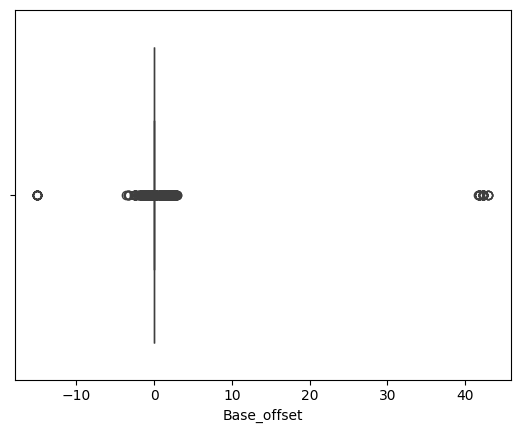

In [106]:
sns.boxplot(x=df3['Base_offset'])

In [107]:
# Ordenar pelas maiores
df3.sort_values(by='Base_offset', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
38349,2347401,Ss_25_13_24,0.91,4.13,Non Load-Bearing,1.76,2.0,0.22,10.07,5.14,43.0,-0.7880999999999999,6,0.661215,2.367559,1.754963,18.408120044860365,28.53469240598514,44.175995596576804,1.3125779372271726,0,SEC2_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
38348,2347397,Ss_25_13_24,0.84,3.80,Non Load-Bearing,1.64,2.0,0.22,9.34,4.96,43.0,-0.7880999999999999,6,0.624889,2.336117,1.639402,18.838301876331272,26.893572067780674,44.160814305017,1.3164393799391727,0,SEC2_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
38350,2347405,Ss_25_13_24,0.18,0.84,Non Load-Bearing,0.35,2.0,0.22,2.88,3.54,43.0,-0.7880999999999999,6,0.306756,2.406572,0.3967,18.136966608277657,29.550859807521345,44.193836796457916,1.2969534306764006,0,SEC2_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
38347,2347393,Ss_25_13_24,0.73,3.32,Non Load-Bearing,1.45,2.0,0.22,8.28,4.76,43.0,-0.7880999999999999,6,0.558797,2.306244,1.457202,19.216700367235084,25.399307933870205,44.14672784181037,1.3300364413581218,0,SEC2_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
38338,2347357,Ss_25_13_24,0.68,3.07,Non Load-Bearing,1.40,2.0,0.22,7.73,4.58,42.3,-0.7880999999999999,6,0.385957,2.205703,1.416308,22.415994316115636,8.980698345233417,43.39731738851584,1.4508943722828997,0,SEC2_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
38337,2347353,Ss_25_13_24,0.46,2.10,Non Load-Bearing,0.96,2.0,0.22,5.57,4.03,42.3,-0.7880999999999999,6,0.323564,2.18318,0.981581,22.552257514809614,7.806515345421105,43.38818378646124,1.4616502262876203,0,SEC2_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
38335,2347345,Ss_25_13_24,1.43,6.50,Non Load-Bearing,3.46,2.0,0.22,15.35,6.64,42.3,-0.7880999999999999,6,0.533591,2.0,3.465621,23.718471667100502,-3.158592032271232,43.23980081605983,1.4797411203059865,0,SEC2_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
38334,2347341,Ss_25_13_24,0.66,2.98,Non Load-Bearing,1.65,2.0,0.22,7.48,4.35,42.3,-0.7880999999999999,6,0.377532,2.0,1.661248,23.95596931202709,-5.7118771620423585,43.20433434689484,1.4744176461429086,0,SEC2_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
38333,2347337,Ss_25_13_24,0.76,3.44,Non Load-Bearing,1.95,2.0,0.22,8.51,4.66,42.3,-0.7880999999999999,6,0.419892,2.0,1.966897,24.135559558270135,-7.502325647633668,43.179524782232555,1.4677830868637312,0,SEC2_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
38359,2461655,Ss_25_13_24,20.99,95.45,Non Load-Bearing,63.84,1.5,0.22,219.45,79.64,42.3,-0.7880999999999999,6,59.180574,1.5,24.343284,-10.08906869252308,12.328882481148701,43.05000018310547,0.3877883303916014,0,SEC2_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.19.5 Arredondar c/ 2 casas decimais

In [108]:
df3["Base_offset"] = df3["Base_offset"].round(2)

## 2.20 Top_offset

### 2.20.1 Análise de valores

In [109]:
df3['Top_offset'].value_counts()

Top_offset
None                    10819
0.0                      2958
-0.24999999999999997     1178
-0.29                    1125
-0.2                      535
                        ...  
-0.41999999999998466        1
-0.41199999999997566        1
-0.28000000000000996        1
-2.688691625302019          1
0.8679087957864446          1
Name: count, Length: 293, dtype: int64

### 2.20.2 Replace None -> 0

In [110]:
df3['Top_offset'] = df3['Top_offset'].replace('None', np.nan)
df3['Top_offset'].describe()

count     7929
unique     292
top        0.0
freq      2958
Name: Top_offset, dtype: object

In [111]:
df3['Top_offset'] = df3['Top_offset'].replace(np.nan , 0)
df3['Top_offset'] = df3['Top_offset'].astype('float')
df3['Top_offset'].describe()

count    18748.000000
mean         0.000527
std          0.450691
min         -4.700000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.803045
Name: Top_offset, dtype: float64

### 2.20.3 Análise valores = 0

In [112]:
df3[df3['Top_offset'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
1,1306674,Ss_25_11_16_70,5.35,26.76,Load-Bearing,27.20,1.00,0.20,65.83,27.27,-1.00,0.0,27,27.325,1.0,0.2,1029.6219058126449,276.0555591796875,83.50315728397713,3.821883985759006e-15,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
2,1306676,Ss_25_11_16_70,4.72,23.58,Load-Bearing,23.59,1.00,0.20,57.00,21.94,-1.00,0.0,6,23.585,1.0,0.2,1031.5016522460937,289.61555939941405,83.51000031738282,3.1415926535897887,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
3,1306762,Ss_25_11_16_70,4.60,18.42,Load-Bearing,5.74,3.37,0.25,43.79,14.23,-0.35,0.0,10,0.25,3.37,6.179986,1044.0941115234375,278.9164221575121,85.19334494995121,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
4,1306764,Ss_25_11_16_70,3.57,14.47,Load-Bearing,4.40,3.37,0.25,33.18,8.71,-0.35,0.0,10,0.25,3.37,4.395189,1044.0941110444417,287.34083363339676,85.33939981801244,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
5,1309469,Ss_25_11_16_70,10.61,43.01,Load-Bearing,3.35,12.33,0.25,93.85,16.52,-0.35,0.0,10,3.554633,12.33,0.25,1103.9865996095232,282.1933242356232,83.89126686982645,0.0,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,None,1.265828,2.385,1.212781,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.20.4 Análise de outliers

<Axes: xlabel='Top_offset'>

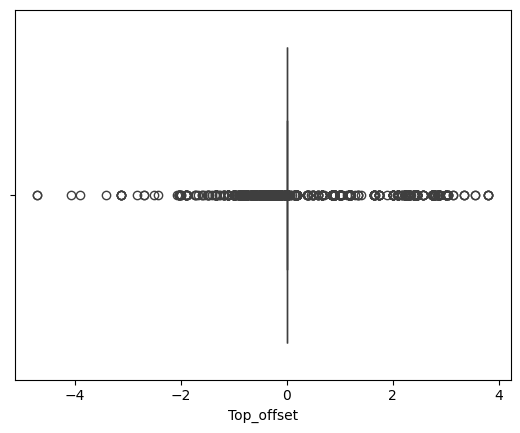

In [113]:
sns.boxplot(x=df3['Top_offset'])

In [114]:
# Ordenar pelas maiores
df3.sort_values(by='Top_offset', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
15856,5957279,Ss_25_10_32_45,0.02,0.41,Non Load-Bearing,1.30,1.40,0.05,0.96,1.89,2.41,3.803045,6,1.2985927328209945,1.397150579583414,0.04800000000000858,3.4984235560500916,10.202831881713868,108.9844640118212,1.6677547962955875e-15,0,Modelos não Classificados/MartaC,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
15858,5957305,Ss_25_10_32_45,0.02,0.41,Non Load-Bearing,1.30,1.40,0.05,0.96,1.89,2.41,3.803045,6,1.298592732820994,1.397150579583414,0.04799999999999992,3.4984235560500916,9.23943748855591,108.9844640118212,0.0,0,Modelos não Classificados/MartaC,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
15852,5955940,Ss_25_10_32_45,0.02,0.41,Non Load-Bearing,1.30,1.40,0.05,0.96,1.89,2.41,3.803045,6,1.2985927328209945,1.397150579583414,0.04800000000000398,3.4984235560500916,2.4138698112487793,108.9844640118212,3.1270402430542264e-15,0,Modelos não Classificados/MartaC,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
15854,5956192,Ss_25_10_32_45,0.02,0.41,Non Load-Bearing,1.30,1.40,0.05,0.96,1.89,2.41,3.803045,6,1.298592732820994,1.397150579583414,0.04800000000000019,3.4984235560500916,1.450475708770752,108.9844640118212,2.0846934953694844e-16,0,Modelos não Classificados/MartaC,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
37186,4388752,Ss_25_12,5.62,23.43,Non Load-Bearing,6.60,3.55,0.24,51.73,12.67,0.00,3.550000,6,6.603373,3.55,0.365692,-32.695015877077594,38.56524723538687,27.774998105377083,0.01905196494404704,0,SEC1_ARQ,0,Ss_25,Ss_25_12,1,5,Walls,0,0,0,0,0,0,0,0,1,0,0
38312,2289397,Ss_25_30_20_30,0.00,6.67,Non Load-Bearing,9.96,0.67,0.00,33.90,0.00,2.88,3.545680,0,9.609358,0.67,4.658266,-2.4989185129143863,-2.615613652844979,46.51067964477531,0.3839724354387488,0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Walls,0,0,0,0,0,0,0,0,1,0,0
15749,4857582,Ss_25_10_32_45,0.03,0.64,Non Load-Bearing,1.88,0.34,0.05,1.49,2.76,3.00,3.337500,6,0.048000000000002895,0.3387000000000183,1.879878504914447,1.5607511724472047,11.648535498046876,99.16815153808594,1.5707963267948981,0,Modelos não Classificados/MartaC,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
15744,4851373,Ss_25_10_20,0.00,4.67,Non Load-Bearing,1.90,2.46,0.00,23.56,0.00,0.88,3.337500,0,1.000000000000003,2.4575000000001603,1.899878504914449,1.3362511797261225,11.638535527038359,98.10875108642651,1.5707963267948981,0,Modelos não Classificados/MartaC,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
15751,4908491,Ss_25_10_20,0.00,7.08,Non Load-Bearing,2.88,2.46,0.00,35.69,0.00,0.88,3.337500,0,1.0000000000000049,2.457499999999987,2.882947788173044,4.483251210669515,12.13007064056394,98.1087510864256,1.5707963267948983,0,Modelos não Classificados/MartaC,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
15752,4911565,Ss_25_10_20,0.00,39.11,Non Load-Bearing,13.58,3.13,0.00,196.41,0.00,0.00,3.130000,0,1.0000000000000222,3.337500000000168,13.577015027841892,4.4957511657714875,3.741440782691489,97.4547761267049,1.5707963267948983,0,Modelos não Classificados/MartaC,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.20.5 Arredondar c/ duas casas decimais

In [115]:
df3["Top_offset"] = df3["Top_offset"].round(2)

## 2.21 Number_of_Faces

### 2.21.1 Análise de valores

In [116]:
df3['Number_of_Faces'].describe()

count     18748
unique       84
top        None
freq       8859
Name: Number_of_Faces, dtype: object

In [117]:
df3['Number_of_Faces'].value_counts()

Number_of_Faces
None    8859
6       6329
8        635
9        578
12       418
        ... 
81         1
311        1
56         1
47         1
39         1
Name: count, Length: 84, dtype: int64

### 2.21.2 Análise valores None

In [118]:
# Filtrar linhas onde Number_of_Faces é None
df_faces_none = df3[df3['Number_of_Faces'] == 'None']
df_faces_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,None,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,None,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,None,1.265828,2.385,1.212781,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [119]:
df_faces_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_25_20_90_13    Curtain Panels            6231
Ss_25_30_20_25    Doors                      893
Ss_25_30_95       Windows                    447
Ss_25_30          Doors                      339
Ss_20_20_75_80    Structural Framing         288
Ss_20_20_75_85    Structural Framing         171
Ss_25_30          Windows                    123
Ss_20_30_75_80    Structural Columns         120
Ss_35_10_85_15    Stairs                      54
Ss_25_30_95       Curtain Panels              46
Ss_25_10_20       Curtain Panels              44
Ss_20_05_15_70    Structural Foundations      31
Ss_35_10          Stairs                      25
Ss_20_20_75_15    Structural Framing          19
Ss_25_13_24       Walls                        8
Ss_20_05_15       Structural Foundations       6
Ss_25_30_20_30    Doors                        5
Ss_25_30_95       Doors                        3
Ss_40_15          Curtain Panels               2
Ss_25_10_32_45    Walls     

### 2.21.3 Replace None -> 0

In [120]:
df3['Number_of_Faces'] = df3['Number_of_Faces'].replace('None', 0)
df3['Number_of_Faces'] = df3['Number_of_Faces'].astype('float')
df3['Number_of_Faces'].describe()


count    18748.000000
mean         4.551099
std          7.872016
min          0.000000
25%          0.000000
50%          6.000000
75%          6.000000
max        333.000000
Name: Number_of_Faces, dtype: float64

### 2.21.4 Análise valores = 0

In [121]:
df3[df3['Number_of_Faces'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.152,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.266203,2.385,1.213708,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.265828,2.385,1.212781,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.21.5 Análise de outliers

<Axes: xlabel='Number_of_Faces'>

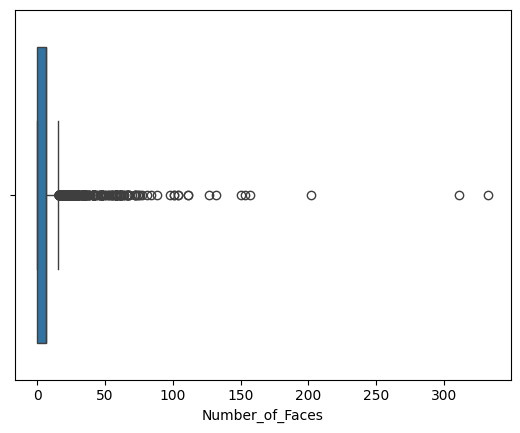

In [122]:
sns.boxplot(x=df3['Number_of_Faces'])

In [123]:
# Ordenar pelas maiores
df3.sort_values(by='Number_of_Faces', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
2623,1798832,Ss_20_05_15,24.34,0.00,Non Load-Bearing,1.00,0.00,0.00,180.11,161.06,0.00,0.00,333.0,43.140167,0.6,21.824702,991.4506372152257,319.52929056235763,86.25000052690908,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
329,1663447,Ss_30_12_85_70,519.73,1484.81,Load-Bearing,4.17,0.00,0.35,3064.44,177.28,0.00,0.00,311.0,53.395767,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
1363,1498890,Ss_20_30_75_15,11.32,58.28,Non Load-Bearing,63.51,0.00,0.00,116.56,89.04,0.00,0.00,202.0,63.512581,2.76,0.3,1012.4848334618385,282.83554440009425,95.60253211685226,4.910298507655744e-15,0,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
274,1515644,Ss_30_12_85_70,77.53,224.07,Load-Bearing,4.17,0.00,0.35,502.13,110.56,0.00,0.00,157.0,15.141141,0.35,17.309194,984.1461898339095,284.3623245857864,83.2344320430623,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
1803,1822340,Ss_20_20_75_15,6.29,39.57,Non Load-Bearing,50.14,0.00,0.00,79.13,69.51,0.00,0.00,153.0,50.142581,0.74,0.25,1019.11179865567,276.05385182862574,89.61942667232121,3.455321528157611e-15,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
1805,1822883,Ss_20_20_75_15,6.40,40.07,Non Load-Bearing,50.14,0.00,0.00,80.15,70.70,0.00,0.00,150.0,50.142581,0.75,0.25,1019.1340174224048,276.05386047824913,92.66442177324895,3.455321528157611e-15,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
5699,8981891,Ss_25_13_50,58.17,146.42,Non Load-Bearing,5.65,28.76,0.40,327.85,67.02,-0.05,-0.29,132.0,5.649999999999998,28.760000000000012,0.40000000000000435,-115.73879853063741,68.12317784585453,101.54468862313162,3.141592653589793,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
37455,1460272,Ss_30_12,453.05,1078.70,Non Load-Bearing,1.63,0.00,0.42,2321.99,254.75,0.00,0.00,127.0,91.516833,0.42,15.759432,5.43447320427848,24.052352459955493,25.789999063110354,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
1737,1711329,Ss_20_20_75_15,4.72,29.78,Non Load-Bearing,38.60,0.00,0.00,59.57,53.91,0.00,0.00,111.0,38.599935,0.74,0.25,1079.221319633361,295.24901623125015,83.52954018468434,2.6931455941242603e-15,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
336,1733522,Ss_30_12_05,129.87,519.34,Load-Bearing,4.17,0.00,0.25,1102.54,138.40,0.00,0.00,111.0,30.486522,0.25,19.182906,992.009847139154,313.72576661217397,86.67500247802735,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0


## 2.22 Bounding_Box_Width

### 2.22.1 Análise de valores

In [124]:
df3['Bounding_Box_Width'].value_counts()

Bounding_Box_Width
0.01535898384862248     2395
0.015358983848622512     791
0.15000000000000055      767
0.04000000000000038      657
0.14027671449780238      347
                        ... 
0.1377566829850341         1
0.1377566829850349         1
0.13775668298504223        1
0.1377566829849648         1
1.213708                   1
Name: count, Length: 4796, dtype: int64

In [125]:
df3['Bounding_Box_Width'].describe()

count                   18748
unique                   4796
top       0.01535898384862248
freq                     2395
Name: Bounding_Box_Width, dtype: object

### 2.22.2 Análise valores None

In [126]:
# Filtrar linhas onde Bounding_Box_Width é 0
df_bbw_none = df3[df3['Bounding_Box_Width'] == 'None']
df_bbw_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


In [127]:
df_bbw_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original
Ss_25_10_20       Curtain Panels       18
Ss_25_20_90_13    Curtain Panels       14
Ss_25_13_24       Walls                 8
Ss_25_30_95       Curtain Panels        2
Ss_25_10_32_45    Walls                 1
Name: count, dtype: int64

### 2.22.3 Replace None -> 0

In [128]:
df3['Bounding_Box_Width'] = df3['Bounding_Box_Width'].replace('None' , 0)
df3['Bounding_Box_Width'] = df3['Bounding_Box_Width'].astype('float')
df3['Bounding_Box_Width'].describe()

count    18748.000000
mean         1.727100
std          5.759515
min          0.000000
25%          0.070000
50%          0.300000
75%          1.400000
max        100.117097
Name: Bounding_Box_Width, dtype: float64

### 2.22.4 Análise valores = 0

In [129]:
df3[df3['Bounding_Box_Width'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


### 2.22.5 Análise de outliers

<Axes: xlabel='Bounding_Box_Width'>

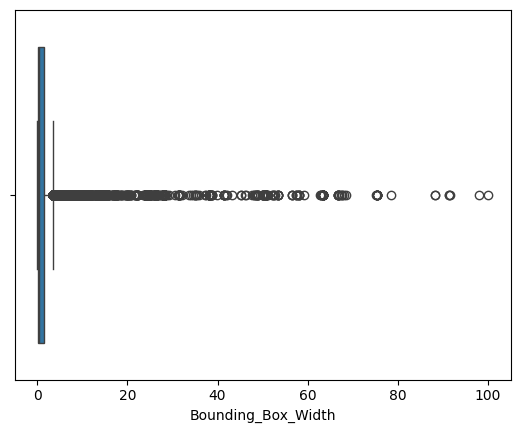

In [130]:
sns.boxplot(x=df3['Bounding_Box_Width'])

In [131]:
# Ordenar pelas maiores
df3.sort_values(by='Bounding_Box_Width', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
37458,1681803,Ss_30_12,768.50,2195.73,Non Load-Bearing,1.63,0.00,0.35,4491.06,176.58,0.00,0.00,32.0,100.117097,0.35,24.215651,9.751656837293295,30.06629623701812,22.525000680541993,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37457,1470420,Ss_30_12,835.73,879.72,Non Load-Bearing,1.63,0.00,0.95,1973.56,144.36,0.00,0.00,27.0,98.138589,0.95,12.784039,10.41304194634937,36.07464150409382,25.474999685668948,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37455,1460272,Ss_30_12,453.05,1078.70,Non Load-Bearing,1.63,0.00,0.42,2321.99,254.75,0.00,0.00,127.0,91.516833,0.42,15.759432,5.43447320427848,24.052352459955493,25.789999063110354,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37465,2717318,Ss_30_12,456.34,1086.52,Non Load-Bearing,1.63,0.00,0.42,2328.73,236.75,0.00,0.00,104.0,91.469776,0.42,15.40323,5.692641646711649,24.437026370731893,29.089999960327148,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37444,352433,Ss_30_12,459.22,1093.38,Non Load-Bearing,1.63,0.00,0.42,2340.00,234.70,0.00,0.00,98.0,91.469776,0.42,15.403284,5.967871893091103,24.445143062059703,32.390000857543946,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37472,3010068,Ss_30_12,341.34,568.90,Non Load-Bearing,1.63,0.00,0.60,1258.88,126.67,0.00,0.00,22.0,88.333146,0.6,19.65,8.717761294178983,15.02447466774426,22.400000170898437,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37443,334234,Ss_30_12,387.17,645.28,Non Load-Bearing,1.63,0.00,0.60,1431.99,145.74,0.00,0.00,24.0,88.172557,0.6,20.752183,14.565128313003745,15.133042228915217,25.699999905261187,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37460,1916370,Ss_30_12,16.01,38.11,Non Load-Bearing,1.63,0.00,0.42,101.62,39.95,0.00,0.00,26.0,78.400341,0.42,3.853445,5.8677831927487185,25.494764191850436,29.089999960327148,None,None,SEC1_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5775,1548936,Ss_30_12_85_18,347.75,1738.74,Non Load-Bearing,2.05,0.00,0.20,3528.96,159.08,0.00,0.00,42.0,75.430000,0.19999999999999785,26.08999999999652,-117.23021017671041,55.79861811843082,76.50000029296875,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
2650,1542874,Ss_25_13_50,93.47,211.20,Non Load-Bearing,74.98,2.80,0.45,499.53,104.57,0.00,-0.20,18.0,75.430000,2.799999999999996,0.4500000000002442,-114.72356189152683,68.14976271611071,77.99999943237304,3.2350258330603172e-15,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.22.6 Arredondar c/ 2 casas decimais

In [132]:
df3["Bounding_Box_Width"] = df3["Bounding_Box_Width"].round(2)

## 2.23 Bounding_Box_Height

### 2.23.1 Análise de valores

In [133]:
df3['Bounding_Box_Height'].value_counts()

Bounding_Box_Height
0.15000000000000055    4360
0.14000000000000282     922
2.1000000000000076      707
2.6500000000000212      698
2.660000000000002       663
                       ... 
1.88                      1
1.25                      1
3.03                      1
2.94                      1
2.379999999999996         1
Name: count, Length: 1054, dtype: int64

In [134]:
df3['Bounding_Box_Height'].describe()

count                   18748
unique                   1054
top       0.15000000000000055
freq                     4360
Name: Bounding_Box_Height, dtype: object

### 2.23.2 Análise valores None

In [135]:
# Filtrar linhas onde Bounding_Box_Height é 0
df_bbh_none = df3[df3['Bounding_Box_Height'] == 'None']
df_bbh_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


In [136]:
df_bbh_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original
Ss_25_10_20       Curtain Panels       18
Ss_25_20_90_13    Curtain Panels       14
Ss_25_13_24       Walls                 8
Ss_25_30_95       Curtain Panels        2
Ss_25_10_32_45    Walls                 1
Name: count, dtype: int64

### 2.23.3 Replace None -> 0

In [137]:
df3['Bounding_Box_Height'] = df3['Bounding_Box_Height'].replace('None' , 0)
df3['Bounding_Box_Height'] = df3['Bounding_Box_Height'].astype('float')
df3['Bounding_Box_Height'].describe()

count    18748.000000
mean         1.774233
std          2.459611
min          0.000000
25%          0.150000
50%          1.190000
75%          2.660000
max         32.700000
Name: Bounding_Box_Height, dtype: float64

### 2.23.4 Análise valores = 0

In [138]:
df3[df3['Bounding_Box_Height'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


### 2.23.5 Análise de outliers

<Axes: xlabel='Bounding_Box_Height'>

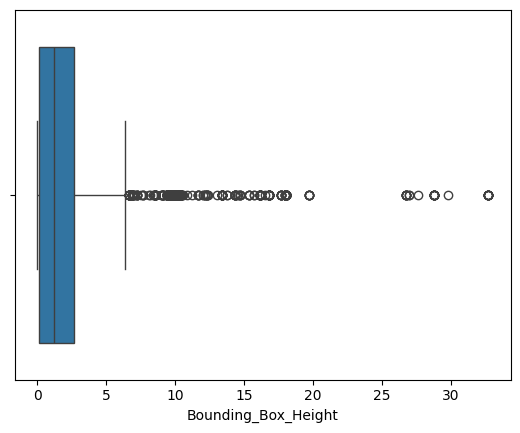

In [139]:
sns.boxplot(x=df3['Bounding_Box_Height'])

In [140]:
# Ordenar pelas maiores
df3.sort_values(by='Bounding_Box_Height', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7673,1908337,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.20,147.97,32.52,-0.30,-0.30,6.0,0.20,32.70,2.149999,15.961142028808595,21.815003320312503,99.34520119628907,1.5707963267949017,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7671,1908333,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.20,147.97,32.52,-0.30,-0.30,6.0,0.20,32.70,2.15,13.911142158508301,21.815003320312503,99.34520119628907,1.570796326794819,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7677,1908349,Ss_25_11_16_70,13.41,67.04,Load-Bearing,2.05,32.70,0.20,147.97,12.47,-0.30,-0.30,6.0,2.15,32.70,0.2,36.02811251220703,22.940000930786134,99.34520119628907,3.1415926535896688,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7676,1908347,Ss_25_11_16_70,13.57,67.85,Load-Bearing,2.12,32.70,0.20,149.62,12.37,-0.30,-0.30,6.0,2.22,32.70,0.2,38.09061336364746,22.940000930786134,99.34520119628907,3.141592653589638,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7675,1908343,Ss_25_11_16_70,18.55,67.03,Load-Bearing,2.05,32.70,0.28,153.31,22.60,-0.30,-0.30,6.0,0.28,32.70,2.049999,33.61650622558594,21.814999832153323,99.34520119628907,1.5707963267948966,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7674,1908341,Ss_25_11_16_70,25.80,93.20,Load-Bearing,3.10,32.70,0.28,206.07,11.70,-0.30,-0.30,6.0,0.28,32.70,3.099997,33.61650622558594,24.265000286865234,99.34520119628907,1.5707963267948883,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7678,1908351,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.20,147.97,32.52,-0.30,-0.30,6.0,0.20,32.70,2.15,35.103111996459965,21.81500099487305,99.34520119628907,1.5707963267949026,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7672,1908335,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.05,32.70,0.20,147.97,12.47,-0.30,-0.30,6.0,2.15,32.70,0.2,15.036142094421388,22.940003256225587,99.34520119628907,1.605812718569185e-13,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7679,1908353,Ss_25_11_16_70,13.41,67.03,Load-Bearing,2.15,32.70,0.20,147.97,32.52,-0.30,-0.30,6.0,0.20,32.70,2.149999,37.15311244812012,21.81500099487305,99.34520119628907,1.570796326794941,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
7670,1908331,Ss_25_11_16_70,13.57,67.85,Load-Bearing,2.12,32.70,0.20,149.62,12.37,-0.30,-0.30,6.0,2.23,32.70,0.2,12.973641242980957,22.940003256225587,99.34520119628907,2.0791048882529185e-13,0,Modelo_Quandrante_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.23.6 Arredondar c/ 2 casas decimais

In [141]:
df3["Bounding_Box_Height"] = df3["Bounding_Box_Height"].round(2)

## 2.24 Bounding_Box_Depth

### 2.24.1 Análise de valores

In [142]:
df3['Bounding_Box_Depth'].value_counts()

Bounding_Box_Depth
0.03999999999999957    1513
0.01535898384862248    1013
0.04000000000000011     848
0.02462715463691046     653
0.15000000000000055     464
                       ... 
5.797                     1
6.000263                  1
0.133                     1
5.730763                  1
1.266203                  1
Name: count, Length: 4325, dtype: int64

In [143]:
df3['Bounding_Box_Depth'].describe()

count                   18748
unique                   4325
top       0.03999999999999957
freq                     1513
Name: Bounding_Box_Depth, dtype: object

### 2.24.2 Análise valores None

In [144]:
# Filtrar linhas onde Bounding_Box_Depth é 0
df_bbd_none = df3[df3['Bounding_Box_Depth'] == 'None']
df_bbd_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


In [145]:
df_bbd_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original
Ss_25_10_20       Curtain Panels       18
Ss_25_20_90_13    Curtain Panels       14
Ss_25_13_24       Walls                 8
Ss_25_30_95       Curtain Panels        2
Ss_25_10_32_45    Walls                 1
Name: count, dtype: int64

### 2.24.3 Replace None -> 0

In [146]:
df3['Bounding_Box_Depth'] = df3['Bounding_Box_Depth'].replace('None' , 0)
df3['Bounding_Box_Depth'] = df3['Bounding_Box_Depth'].astype('float')
df3['Bounding_Box_Depth'].describe()

count    18748.000000
mean         1.198692
std          2.596523
min          0.000000
25%          0.040000
50%          0.230000
75%          1.200000
max         48.355298
Name: Bounding_Box_Depth, dtype: float64

### 2.24.4 Análise valores = 0

In [147]:
df3[df3['Bounding_Box_Depth'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
7564,4932515,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7565,4932516,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7566,4932517,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7570,4932773,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7571,4932774,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7572,4932775,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7576,4932962,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7577,4932963,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7578,4932964,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0
7582,4941013,Ss_25_10_20,0.0,0.0,Non Load-Bearing,2.05,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,None,None,None,None,None,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Curtain Panels,1,0,0,0,0,0,0,0,0,0,0


### 2.24.5 Análise de outliers

<Axes: xlabel='Bounding_Box_Depth'>

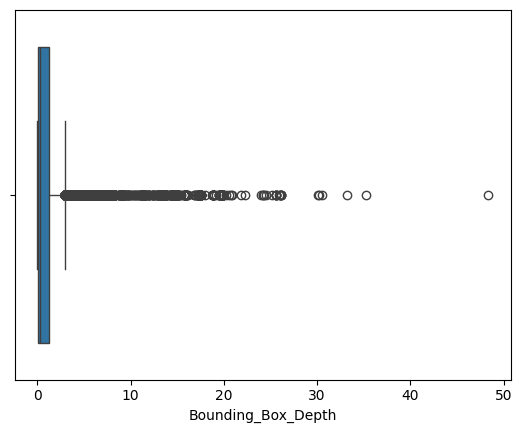

In [148]:
sns.boxplot(x=df3['Bounding_Box_Depth'])

In [149]:
# Ordenar pelas maiores
df3.sort_values(by='Bounding_Box_Depth', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
2622,1785701,Ss_20_05_15_70,64.35,0.00,Non Load-Bearing,1.00,0.00,0.00,405.23,201.01,0.00,0.00,42.0,50.54,3.89,48.355298,990.2560673600768,300.21750564441317,87.23290666202466,None,None,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Structural Foundations,0,0,0,0,0,0,1,0,0,0,0
9,1309491,Ss_25_11_16_70,17.34,69.35,Load-Bearing,35.26,3.45,0.25,158.32,46.65,-0.35,0.20,9.0,0.25,4.22,35.263573,1123.0006253906251,280.3715630672529,78.92305019131025,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
329,1663447,Ss_30_12_85_70,519.73,1484.81,Load-Bearing,4.17,0.00,0.35,3064.44,177.28,0.00,0.00,311.0,53.40,0.35,33.165411,1003.8483963220417,307.66708663328285,83.3250023093032,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
37038,3839743,Ss_25_12,26.68,111.25,Non Load-Bearing,30.62,5.60,0.24,238.79,41.67,-1.00,0.00,6.0,3.33,5.60,30.488749,62.03285700142211,29.710589683108683,23.694435904250604,1.4695243586110005,0,SEC1_ARQ,0,Ss_25,Ss_25_12,1,5,Walls,0,0,0,0,0,0,0,0,1,0,0
293,1590170,Ss_30_12_85_70,20.86,104.32,Load-Bearing,4.17,0.00,0.20,265.43,142.93,0.00,0.00,81.0,67.61,0.20,30.180195,1007.9544556221379,277.4418875987747,93.04000001220703,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
290,1574703,Ss_30_12_85_70,19.71,98.57,Load-Bearing,4.17,0.00,0.20,253.08,120.99,0.00,0.00,76.0,67.61,0.20,30.055195,1009.0816482669226,276.5836775486571,96.67000188351572,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
35208,699631,Ss_25_11,29.39,108.87,Non Load-Bearing,26.25,2.12,0.27,233.69,36.68,-0.72,-1.90,10.0,2.93,5.40,26.141495,58.32107661799994,23.83903368734445,22.512714399413873,1.6721474866980477,0,SEC1_ARQ,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
5776,1548966,Ss_30_12_85_18,356.01,1780.04,Non Load-Bearing,2.05,0.00,0.20,3618.38,181.07,0.00,0.00,59.0,75.43,0.20,26.090000,-116.74050544362441,55.684737119540465,79.49999857177735,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5775,1548936,Ss_30_12_85_18,347.75,1738.74,Non Load-Bearing,2.05,0.00,0.20,3528.96,159.08,0.00,0.00,42.0,75.43,0.20,26.090000,-117.23021017671041,55.79861811843082,76.50000029296875,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
5774,1542773,Ss_30_12_85_18,393.59,1967.97,Non Load-Bearing,2.05,0.00,0.20,3976.54,124.02,0.00,0.00,6.0,75.43,0.20,26.090000,-114.39800332031251,55.328925109863285,73.70000143432618,None,None,Modelo_Quadrante_ARQ,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0


### 2.24.6 Arredondar c/ 2 casas decimais

In [150]:
df3["Bounding_Box_Depth"] = df3["Bounding_Box_Depth"].round(2)

## 2.25 Centroid_X

### 2.25.1 Análise de valores

In [151]:
df3['Centroid_X'].value_counts()

Centroid_X
None                   8859
0.2499999973654747       79
48.70500384521485        36
1056.500647265625        33
6.775000124359131        33
                       ... 
-92.31827662353516        1
-89.39543738489971        1
-114.67383750415854       1
-140.84991978519233       1
-10.409611151974142       1
Name: count, Length: 5111, dtype: int64

In [152]:
df3['Centroid_X'].describe()

count     18748
unique     5111
top        None
freq       8859
Name: Centroid_X, dtype: object

### 2.25.2 Análise valores None

In [153]:
# Filtrar linhas onde Centroid_X é 0
df_cx_none = df3[df3['Centroid_X'] == 'None']
df_cx_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,None,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,None,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [154]:
df_cx_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_25_20_90_13    Curtain Panels            6231
Ss_25_30_20_25    Doors                      893
Ss_25_30_95       Windows                    447
Ss_25_30          Doors                      339
Ss_20_20_75_80    Structural Framing         288
Ss_20_20_75_85    Structural Framing         171
Ss_25_30          Windows                    123
Ss_20_30_75_80    Structural Columns         120
Ss_35_10_85_15    Stairs                      54
Ss_25_30_95       Curtain Panels              46
Ss_25_10_20       Curtain Panels              44
Ss_20_05_15_70    Structural Foundations      31
Ss_35_10          Stairs                      25
Ss_20_20_75_15    Structural Framing          19
Ss_25_13_24       Walls                        8
Ss_20_05_15       Structural Foundations       6
Ss_25_30_20_30    Doors                        5
Ss_25_30_95       Doors                        3
Ss_40_15          Curtain Panels               2
Ss_25_10_32_45    Walls     

### 2.25.3 Replace None -> 0

In [155]:
df3['Centroid_X'] = df3['Centroid_X'].replace('None', 0)
df3['Centroid_X'] = df3['Centroid_X'].astype('float')
df3['Centroid_X'].describe()

count    18748.000000
mean       111.824855
std        357.505070
min       -151.930889
25%         -5.681429
50%          0.000000
75%          2.779383
max       1123.025629
Name: Centroid_X, dtype: float64

### 2.25.4 Análise valores = 0

In [156]:
df3[df3['Centroid_X'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.25.5 Análise de outliers

<Axes: xlabel='Centroid_X'>

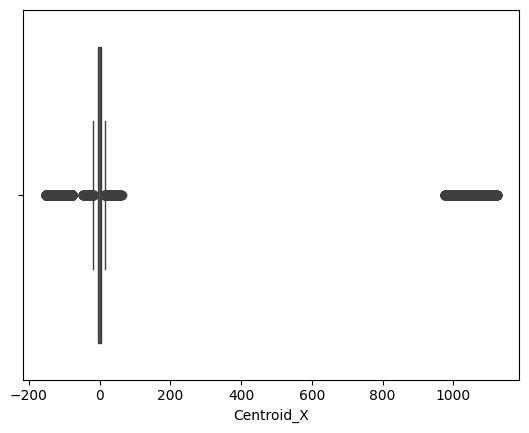

In [157]:
sns.boxplot(x=df3['Centroid_X'])

In [158]:
# Ordenar pelas maiores
df3.sort_values(by='Centroid_X', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
37,1438933,Ss_25_11_16_70,3.12,15.58,Load-Bearing,13.03,1.20,0.20,36.82,12.46,-0.20,-2.00,6.0,0.20,1.20,13.13,1123.025629,288.5592052734375,81.40999826660156,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
51,1545381,Ss_25_11_16_70,0.30,1.20,Load-Bearing,1.58,0.83,0.25,3.54,2.50,-1.23,-3.40,6.0,0.25,0.83,1.58,1123.000625,297.4242362548828,80.1933469482422,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
501,1309489,Ss_20_30_75_15,0.11,0.87,Non Load-Bearing,4.17,0.00,0.00,1.73,2.15,-0.35,0.00,6.0,0.20,3.25,0.55,1123.000625,289.46923344726565,80.30500059814453,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
493,1309463,Ss_20_30_75_15,0.10,0.75,Non Load-Bearing,4.17,0.00,0.00,1.49,0.90,-0.35,-0.20,8.0,0.25,3.05,0.40,1123.000625,295.14809180796533,80.29383654076558,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
645,1546732,Ss_20_30_75_15,0.16,1.38,Non Load-Bearing,2.57,0.00,0.00,2.75,2.78,-1.23,-1.60,6.0,0.25,2.63,0.25,1123.000625,301.6242310546875,81.09499888916017,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
644,1546059,Ss_20_30_75_15,0.16,1.38,Non Load-Bearing,2.57,0.00,0.00,2.75,2.95,-1.23,-1.60,6.0,0.25,2.63,0.25,1123.000625,298.2742401855469,81.09499888916017,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
1415,1545277,Ss_20_20_75_15,0.27,1.95,Non Load-Bearing,3.10,0.00,0.00,3.89,3.93,0.00,0.00,6.0,0.25,1.23,3.10,1123.000625,299.9492356201172,79.9549987060547,1.5707963267948966,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
498,1309477,Ss_20_30_75_15,0.10,0.76,Non Load-Bearing,4.17,0.00,0.00,1.51,1.58,-0.35,-0.20,6.0,0.25,3.05,0.40,1123.000625,282.2691892089844,80.30500059814453,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
9,1309491,Ss_25_11_16_70,17.34,69.35,Load-Bearing,35.26,3.45,0.25,158.32,46.65,-0.35,0.20,9.0,0.25,4.22,35.26,1123.000625,280.3715630672529,78.92305019131025,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
50,1544710,Ss_25_11_16_70,0.11,0.54,Load-Bearing,0.27,1.10,0.25,1.72,0.92,-1.23,-3.13,6.0,0.25,1.10,0.49,1122.992828,301.96000032291244,80.32999907226564,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.25.6 Arredondar c/ 2 casas decimais

In [159]:
df3["Centroid_X"] = df3["Centroid_X"].round(2)

## 2.26 Centroid Y

### 2.26.1 Análise de valores

In [160]:
df3['Centroid_Y'].describe()

count     18748
unique     4791
top        None
freq       8859
Name: Centroid_Y, dtype: object

In [161]:
df3['Centroid_Y'].value_counts()

Centroid_Y
None                  8859
11.339999098205567      84
18.489999879455567      70
60.7739253112793        70
287.6592322998047       54
                      ... 
59.198670101716          1
60.33892628173828        1
69.56892568359375        1
69.33903739013672        1
-4.752080421453377       1
Name: count, Length: 4791, dtype: int64

### 2.26.2 Análise valores None

In [162]:
# Filtrar linhas onde Centroid_Y é None
df_cy_none = df3[df3['Centroid_Y'] == 'None']
df_cy_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,None,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,None,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [163]:
df_cy_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_25_20_90_13    Curtain Panels            6231
Ss_25_30_20_25    Doors                      893
Ss_25_30_95       Windows                    447
Ss_25_30          Doors                      339
Ss_20_20_75_80    Structural Framing         288
Ss_20_20_75_85    Structural Framing         171
Ss_25_30          Windows                    123
Ss_20_30_75_80    Structural Columns         120
Ss_35_10_85_15    Stairs                      54
Ss_25_30_95       Curtain Panels              46
Ss_25_10_20       Curtain Panels              44
Ss_20_05_15_70    Structural Foundations      31
Ss_35_10          Stairs                      25
Ss_20_20_75_15    Structural Framing          19
Ss_25_13_24       Walls                        8
Ss_20_05_15       Structural Foundations       6
Ss_25_30_20_30    Doors                        5
Ss_25_30_95       Doors                        3
Ss_40_15          Curtain Panels               2
Ss_25_10_32_45    Walls     

### 2.26.3 Replace None -> 0

In [164]:
df3['Centroid_Y'] = df3['Centroid_Y'].replace('None', 0)
df3['Centroid_Y'] = df3['Centroid_Y'].astype('float')
df3['Centroid_Y'].describe()

count    18748.000000
mean        51.915512
std         92.372272
min        -38.969816
25%          0.000000
50%          1.472827
75%         61.120927
max        323.135774
Name: Centroid_Y, dtype: float64

### 2.26.4 Análise valores = 0

In [165]:
df3[df3['Centroid_Y'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.26.5 Análise outliers

<Axes: xlabel='Centroid_Y'>

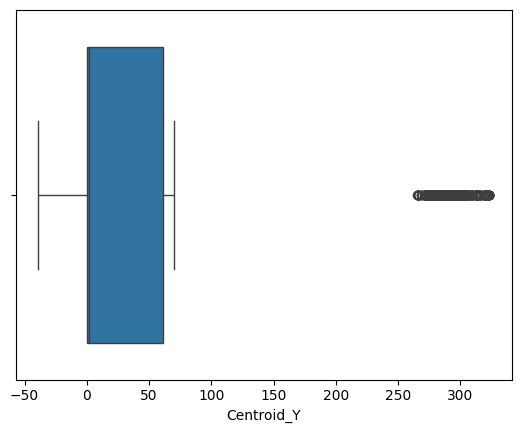

In [166]:
sns.boxplot(x=df3['Centroid_Y'])

In [167]:
# Ordenar pelas maiores
df3.sort_values(by='Centroid_Y', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
179,2059774,Ss_20_05_15_70,0.97,1.50,Load-Bearing,1.20,1.25,0.65,6.18,3.57,-0.25,-2.06,6.0,1.20,1.25,0.65,1015.42,323.135774,87.40499978027344,0.0,0,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,0
176,2058977,Ss_20_05_15_70,1.76,3.28,Load-Bearing,1.20,2.73,0.65,11.13,6.91,-0.23,-0.56,10.0,1.20,2.73,0.65,992.62,323.099728,88.22592157755984,0.0,0,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,0
175,2058836,Ss_20_05_15_70,1.68,3.16,Load-Bearing,1.20,2.63,0.65,10.76,6.87,-0.23,-0.66,10.0,1.20,2.63,0.65,987.82,323.098062,88.16794138498871,0.0,0,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,0
174,2058403,Ss_20_05_15_70,1.68,3.16,Load-Bearing,1.20,2.63,0.65,10.76,5.66,-0.23,-0.66,10.0,1.20,2.63,0.65,983.02,323.098062,88.16794143963587,0.0,0,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,0
177,2059172,Ss_20_05_15_70,1.51,2.86,Load-Bearing,1.20,2.38,0.65,9.87,6.49,-0.28,-0.96,10.0,1.20,2.38,0.65,999.82,323.096259,87.98152059401802,0.0,0,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,0
178,2059538,Ss_20_05_15_70,1.22,2.33,Load-Bearing,1.24,1.88,0.65,8.33,4.93,-0.28,-1.46,10.0,1.24,1.88,0.65,1007.04,323.094145,87.72400625410924,0.0,0,CVTT_EST,0,Ss_20,Ss_20_05,0,0,Walls,0,0,0,0,0,0,0,0,1,0,0
2467,2286848,Ss_20_20_75_15,0.42,3.23,Non Load-Bearing,2.80,0.00,0.00,6.46,7.04,0.00,0.00,11.0,2.80,1.03,0.30,1003.72,322.848815,89.56209435865927,0.0,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
1801,1779369,Ss_25_11_16_70,2.33,8.84,Non Load-Bearing,1.80,0.00,0.00,17.68,5.31,0.00,0.00,10.0,0.35,4.39,1.80,987.65,322.122934,87.72909823369585,1.5707963267948966,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
2453,2255014,Ss_20_20_75_15,1.51,7.39,Non Load-Bearing,7.18,0.00,0.00,14.78,7.63,0.00,0.00,6.0,7.18,0.70,0.30,1003.72,321.460769,86.9000026977539,0.0,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
2470,2286932,Ss_20_20_75_15,0.37,2.90,Non Load-Bearing,3.10,0.00,0.00,5.80,6.40,0.00,0.00,12.0,0.30,1.03,3.10,1002.47,321.448807,89.51899508027307,1.5707963267948966,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0


### 2.26.6 Arredondar c/ 2 casas decimais

In [168]:
df3["Centroid_Y"] = df3["Centroid_Y"].round(2)

## 2.27 Centroid Z

### 2.27.1 Análise de valores

In [169]:
df3['Centroid_Z'].describe()

count     18748
unique     3598
top        None
freq       8859
Name: Centroid_Z, dtype: object

In [170]:
df3['Centroid_Z'].value_counts()

Centroid_Z
None                  8859
30.740000408935547     280
34.04000014343262      241
27.439999511718753     141
27.34999919128418      110
                      ... 
94.19864700093787        1
94.22960924017656        1
100.01727912004742       1
100.00656254156411       1
47.093327304790115       1
Name: count, Length: 3598, dtype: int64

### 2.27.2 Análise valores None

In [171]:
# Filtrar linhas onde Centroid_Z é None
df_cz_none = df3[df3['Centroid_Z'] == 'None']
df_cz_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,None,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,None,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [172]:
df_cz_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_25_20_90_13    Curtain Panels            6231
Ss_25_30_20_25    Doors                      893
Ss_25_30_95       Windows                    447
Ss_25_30          Doors                      339
Ss_20_20_75_80    Structural Framing         288
Ss_20_20_75_85    Structural Framing         171
Ss_25_30          Windows                    123
Ss_20_30_75_80    Structural Columns         120
Ss_35_10_85_15    Stairs                      54
Ss_25_30_95       Curtain Panels              46
Ss_25_10_20       Curtain Panels              44
Ss_20_05_15_70    Structural Foundations      31
Ss_35_10          Stairs                      25
Ss_20_20_75_15    Structural Framing          19
Ss_25_13_24       Walls                        8
Ss_20_05_15       Structural Foundations       6
Ss_25_30_20_30    Doors                        5
Ss_25_30_95       Doors                        3
Ss_40_15          Curtain Panels               2
Ss_25_10_32_45    Walls     

### 2.27.3 Replace None -> 0

In [173]:
df3['Centroid_Z'] = df3['Centroid_Z'].replace('None', 0)
df3['Centroid_Z'] = df3['Centroid_Z'].astype('float')
df3['Centroid_Z'].describe()

count    18748.000000
mean        40.313065
std         44.191073
min         -4.101148
25%          0.000000
50%         25.777475
75%         89.793361
max        116.979999
Name: Centroid_Z, dtype: float64

### 2.27.4 Análise valores = 0

In [174]:
df3[df3['Centroid_Z'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
977,1824674,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,0.0,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
978,1825455,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,0.0,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
979,1825457,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,0.0,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
980,1825459,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,0.0,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
981,1825531,Ss_20_30_75_80,0.01,0.00,Non Load-Bearing,2.57,0.00,0.0,0.0,0.0,1.19,0.0,0.0,0.16,2.63,0.15,0.0,0.0,0.0,None,None,CVTT_EST,0,Ss_20,Ss_20_30,0,2,Structural Columns,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,0.0,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,0.0,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,0.0,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.8,0.0,0.0,0.00,0.0,0.0,1.27,2.39,1.21,0.0,0.0,0.0,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.27.5 Análise de outliers

<Axes: xlabel='Centroid_Z'>

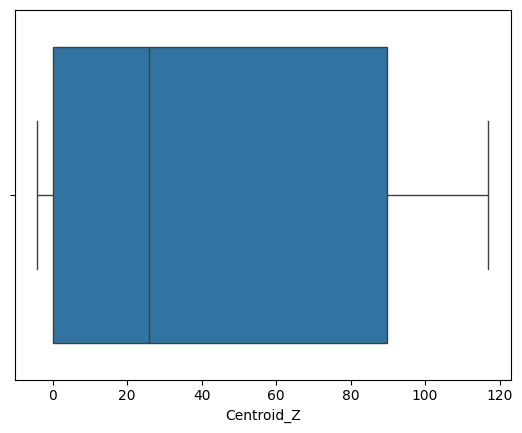

In [175]:
sns.boxplot(x=df3['Centroid_Z'])

In [176]:
# Ordenar pelas maiores
df3.sort_values(by='Centroid_Z', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
5773,9779550,Ss_37_17_13_50,0.50,3.34,Non Load-Bearing,2.05,1.76,0.15,7.79,3.39,0.0,-0.25,6.0,0.15,1.76,2.05,-112.77,64.19,116.979999,1.5707963267948966,0,Modelo_Quadrante_ARQ,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5769,9779545,Ss_37_17_13_50,0.50,3.34,Non Load-Bearing,2.05,1.76,0.15,7.79,3.39,0.0,-0.25,6.0,0.15,1.76,2.05,-119.09,64.19,116.979999,1.5707963267948966,0,Modelo_Quadrante_ARQ,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5594,8662017,Ss_37_17_13_50,0.13,0.88,Non Load-Bearing,0.35,1.76,0.15,2.44,1.68,0.0,-0.25,6.0,0.50,1.76,0.15,-102.68,63.47,116.979999,0.0,0,Modelo_Quadrante_ARQ,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5595,8662048,Ss_37_17_13_50,0.12,0.79,Non Load-Bearing,0.60,1.76,0.15,2.25,1.62,0.0,-0.25,6.0,0.15,1.76,0.60,-102.51,63.17,116.979999,1.5707963267948966,0,Modelo_Quadrante_ARQ,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5596,8662066,Ss_37_17_13_50,0.13,0.88,Non Load-Bearing,0.35,1.76,0.15,2.44,1.68,0.0,-0.25,6.0,0.50,1.76,0.15,-102.68,62.87,116.979999,3.141592653589793,0,Modelo_Quadrante_ARQ,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5597,8662090,Ss_37_17_13_50,0.12,0.79,Non Load-Bearing,0.60,1.76,0.15,2.25,1.62,0.0,-0.25,6.0,0.15,1.76,0.60,-102.86,63.17,116.979999,1.5707963267948966,0,Modelo_Quadrante_ARQ,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5598,8662333,Ss_37_17_13_50,0.38,2.54,Non Load-Bearing,1.60,1.76,0.15,6.05,2.83,0.0,-0.25,6.0,1.60,1.76,0.15,-84.64,61.02,116.979999,5.430384731275005e-15,0,Modelo_Quadrante_ARQ,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5599,8662356,Ss_37_17_13_50,0.13,0.88,Non Load-Bearing,0.35,1.76,0.15,2.44,1.68,0.0,-0.25,6.0,0.15,1.76,0.50,-83.84,60.85,116.979999,1.5707963267948966,0,Modelo_Quadrante_ARQ,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5600,8662384,Ss_37_17_13_50,0.38,2.54,Non Load-Bearing,1.60,1.76,0.15,6.05,2.83,0.0,-0.25,6.0,1.60,1.76,0.15,-84.64,60.67,116.979999,3.141592653589788,0,Modelo_Quadrante_ARQ,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0
5601,8662408,Ss_37_17_13_50,0.13,0.88,Non Load-Bearing,0.35,1.76,0.15,2.44,1.68,0.0,-0.25,6.0,0.15,1.76,0.50,-85.43,60.85,116.979999,1.5707963267948966,0,Modelo_Quadrante_ARQ,0,Ss_37,Ss_37_17,4,15,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.27.6 Arredondar c/ 2 casas decimais

In [177]:
df3["Centroid_Z"] = df3["Centroid_Z"].round(2)

## 2.28 Orientation_Angle

### 2.28.1 Análise de valores

In [178]:
df3['Orientation_Angle'].describe()

count     18748
unique     1986
top        None
freq      10296
Name: Orientation_Angle, dtype: object

In [179]:
df3['Orientation_Angle'].value_counts()

Orientation_Angle
None                   10296
1.5707963267948966      2710
0.0                     1128
3.141592653589793        509
3.14159265358979         121
                       ...  
1.4311699866353689         1
1.675516081914534          1
0.1745330682018957         1
0.13962634015952427        1
1.954768762233642          1
Name: count, Length: 1986, dtype: int64

### 2.28.2 Análise valores None

In [180]:
# Filtrar linhas onde Orientation_Angle é None
df_oa_none = df3[df3['Orientation_Angle'] == 'None']
df_oa_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
250,1306680,Ss_30_12_85_70,129.57,370.21,Load-Bearing,4.17,0.00,0.35,771.94,45.40,0.0,0.0,55.0,27.75,0.35,13.36,1030.09,282.84,83.83,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
251,1306768,Ss_30_12_05,68.43,342.14,Load-Bearing,4.17,0.00,0.20,704.40,29.30,0.0,0.0,20.0,28.00,0.20,13.36,1030.98,282.60,86.93,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
252,1306782,Ss_30_12_05,67.69,338.47,Load-Bearing,4.17,0.00,0.20,718.09,74.84,0.0,0.0,37.0,27.95,0.20,13.61,1030.67,282.64,89.99,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
253,1306802,Ss_30_12_05,63.67,318.36,Load-Bearing,4.17,0.00,0.20,657.02,32.91,0.0,0.0,15.0,23.79,0.20,13.59,1004.10,282.82,86.93,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
254,1306991,Ss_30_12_05,38.70,193.52,Load-Bearing,4.17,0.00,0.20,398.20,21.14,0.0,0.0,6.0,12.97,0.20,14.92,987.46,282.26,89.99,None,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,None,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [181]:
df_oa_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_25_20_90_13    Curtain Panels            6231
Ss_20_30_75_15    Structural Columns        1375
Ss_25_30_20_25    Doors                      893
Ss_25_30_95       Windows                    447
Ss_25_30          Doors                      339
Ss_30_12_85_18    Floors                     145
Ss_20_30_75_80    Structural Columns         127
Ss_25_30          Windows                    123
Ss_20_05_15_70    Structural Foundations     117
Ss_30_12_85_70    Floors                     102
Ss_35_10_85_15    Stairs                      54
Ss_30_12          Floors                      52
Ss_30_12_05       Floors                      48
Ss_25_30_95       Curtain Panels              46
Ss_25_10_20       Curtain Panels              44
Ss_20_05_15       Structural Foundations      35
Ss_35_10          Stairs                      25
Ss_20_05_15       Structural Columns          19
Ss_25_50_35       Floors                      19
Ss_35_10_85_15    Floors    

### 2.28.3 Replace None -> 0

In [182]:
df3['Orientation_Angle'] = df3['Orientation_Angle'].replace('None', 0)
df3['Orientation_Angle'] = df3['Orientation_Angle'].astype('float')
df3['Orientation_Angle'].describe()

count    18748.000000
mean         0.616534
std          0.991802
min          0.000000
25%          0.000000
50%          0.000000
75%          1.570796
max          3.141593
Name: Orientation_Angle, dtype: float64

### 2.28.4 Análise valores = 0

In [183]:
df3[df3['Orientation_Angle'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
5,1309469,Ss_25_11_16_70,10.61,43.01,Load-Bearing,3.35,12.33,0.25,93.85,16.52,-0.35,0.0,10.0,3.55,12.33,0.25,1103.99,282.19,83.89,0.0,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
13,1309504,Ss_25_11_16_70,13.13,43.76,Load-Bearing,13.56,3.25,0.30,97.55,14.35,-0.35,0.0,6.0,13.56,3.25,0.30,1109.14,295.20,79.39,0.0,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
14,1309506,Ss_25_11_16_70,5.30,21.20,Load-Bearing,5.82,3.25,0.25,47.11,11.76,-0.35,0.0,6.0,5.82,3.72,0.25,1120.03,296.57,79.62,0.0,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
26,1309843,Ss_25_11_16_70,7.63,25.42,Load-Bearing,7.15,3.75,0.30,57.57,11.57,-0.35,0.5,9.0,7.25,4.22,0.30,1119.17,295.20,79.97,0.0,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
27,1309869,Ss_25_11_16_70,8.85,35.39,Load-Bearing,3.61,10.81,0.25,81.10,24.03,-1.73,0.0,10.0,3.61,10.21,0.25,1104.01,277.96,84.38,0.0,0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.28.5 Análise de outliers

<Axes: xlabel='Orientation_Angle'>

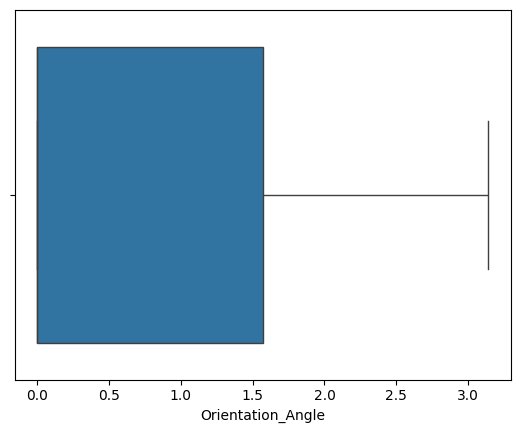

In [184]:
sns.boxplot(x=df3['Orientation_Angle'])

In [185]:
# Ordenar pelas maiores
df3.sort_values(by='Orientation_Angle', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
3161,4633190,Ss_25_13_50,8.38,21.11,Non Load-Bearing,14.47,2.66,0.45,78.30,51.42,-0.05,-0.29,35.0,14.64,2.66,0.45,-90.57,53.59,91.36,3.141593,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
2015,2042973,Ss_20_20_75_15,1.01,5.59,Non Load-Bearing,5.00,0.00,0.00,11.19,5.59,0.00,0.00,12.0,5.00,0.84,0.25,1060.88,289.33,86.60,3.141593,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
5177,8088708,Ss_25_10_30_35,0.58,3.87,Non Load-Bearing,1.60,2.66,0.15,8.98,4.21,-0.05,-0.29,6.0,1.60,2.66,0.15,-101.71,64.23,88.38,3.141593,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
2038,2044213,Ss_20_20_75_15,0.12,0.99,Non Load-Bearing,1.71,0.00,0.00,1.97,2.11,0.00,0.00,6.0,1.71,0.42,0.20,1097.62,286.83,89.87,3.141593,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
5178,8088726,Ss_25_10_30_35,0.77,5.10,Non Load-Bearing,2.17,2.66,0.15,11.58,3.87,-0.05,-0.29,6.0,2.17,2.66,0.15,-95.50,65.79,88.38,3.141593,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
2036,2044209,Ss_20_20_75_15,0.15,1.23,Non Load-Bearing,1.71,0.00,0.00,2.45,1.75,0.00,0.00,6.0,1.91,0.42,0.20,1097.62,284.49,89.87,3.141593,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
2035,2044204,Ss_20_20_75_15,0.12,0.99,Non Load-Bearing,1.74,0.00,0.00,1.97,2.05,0.00,0.00,6.0,1.74,0.42,0.20,1097.62,290.14,89.87,3.141593,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
2033,2044200,Ss_20_20_75_15,0.14,1.11,Non Load-Bearing,1.64,0.00,0.00,2.21,1.87,0.00,0.00,6.0,1.84,0.42,0.20,1097.52,292.48,89.87,3.141593,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0
5180,8089304,Ss_25_13_50,1.09,3.62,Non Load-Bearing,1.77,2.66,0.30,11.67,7.92,-0.05,-0.29,10.0,1.92,2.66,0.30,-97.50,62.81,91.37,3.141593,0,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
2031,2044163,Ss_20_20_75_15,0.12,0.99,Non Load-Bearing,1.71,0.00,0.00,1.97,2.11,0.00,0.00,6.0,1.71,0.42,0.20,1097.62,286.83,86.81,3.141593,0,CVTT_EST,0,Ss_20,Ss_20_20,0,1,Structural Framing,0,0,0,0,0,0,0,1,0,0,0


### 2.28.6 Arredondar c/ 2 casas decimais

In [186]:
df3["Orientation_Angle"] = df3["Orientation_Angle"].round(2)

## 2.29 Curvature

### 2.29.1 Análise de valores

In [187]:
df3['Curvature'].describe()

count     18748
unique       12
top        None
freq      10296
Name: Curvature, dtype: object

In [188]:
df3['Curvature'].value_counts()

Curvature
None                   10296
0                       8420
0.39843137254901967       12
0.4800000000000001         6
2.0157006623252687         5
0.09098507462686573        2
0.8350684931506851         2
0.07949709762306124        1
0.09222390317700453        1
1.966532826209713          1
0.870857142857143          1
0.0633106701079233         1
Name: count, dtype: int64

### 2.29.2 Análise valores None

In [189]:
# Filtrar linhas onde Curvature é None
df_c_none = df3[df3['Curvature'] == 'None']
df_c_none

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
250,1306680,Ss_30_12_85_70,129.57,370.21,Load-Bearing,4.17,0.00,0.35,771.94,45.40,0.0,0.0,55.0,27.75,0.35,13.36,1030.09,282.84,83.83,0.0,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
251,1306768,Ss_30_12_05,68.43,342.14,Load-Bearing,4.17,0.00,0.20,704.40,29.30,0.0,0.0,20.0,28.00,0.20,13.36,1030.98,282.60,86.93,0.0,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
252,1306782,Ss_30_12_05,67.69,338.47,Load-Bearing,4.17,0.00,0.20,718.09,74.84,0.0,0.0,37.0,27.95,0.20,13.61,1030.67,282.64,89.99,0.0,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
253,1306802,Ss_30_12_05,63.67,318.36,Load-Bearing,4.17,0.00,0.20,657.02,32.91,0.0,0.0,15.0,23.79,0.20,13.59,1004.10,282.82,86.93,0.0,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
254,1306991,Ss_30_12_05,38.70,193.52,Load-Bearing,4.17,0.00,0.20,398.20,21.14,0.0,0.0,6.0,12.97,0.20,14.92,987.46,282.26,89.99,0.0,None,CVTT_EST,0,Ss_30,Ss_30_12,2,12,Floors,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.0,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.0,None,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


In [190]:
df_c_none[['SECClasS_Code_Ss' , 'Category_original']].value_counts()

SECClasS_Code_Ss  Category_original     
Ss_25_20_90_13    Curtain Panels            6231
Ss_20_30_75_15    Structural Columns        1375
Ss_25_30_20_25    Doors                      893
Ss_25_30_95       Windows                    447
Ss_25_30          Doors                      339
Ss_30_12_85_18    Floors                     145
Ss_20_30_75_80    Structural Columns         127
Ss_25_30          Windows                    123
Ss_20_05_15_70    Structural Foundations     117
Ss_30_12_85_70    Floors                     102
Ss_35_10_85_15    Stairs                      54
Ss_30_12          Floors                      52
Ss_30_12_05       Floors                      48
Ss_25_30_95       Curtain Panels              46
Ss_25_10_20       Curtain Panels              44
Ss_20_05_15       Structural Foundations      35
Ss_35_10          Stairs                      25
Ss_20_05_15       Structural Columns          19
Ss_25_50_35       Floors                      19
Ss_35_10_85_15    Floors    

### 2.29.3 Replace None -> 0

In [191]:
df3['Curvature'] = df3['Curvature'].replace('None', 0)
df3['Curvature'] = df3['Curvature'].astype('float')
df3['Curvature'].describe()

count    18748.000000
mean         0.001209
std          0.039756
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.015701
Name: Curvature, dtype: float64

### 2.29.4 Análise valores = 0

In [192]:
df3[df3['Curvature'] == 0]

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
0,1306672,Ss_25_11_16_70,11.05,44.21,Load-Bearing,13.56,3.37,0.25,97.03,14.92,-0.35,0.0,15.0,0.25,3.37,13.66,1016.09,282.85,85.30,1.57,0.0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
1,1306674,Ss_25_11_16_70,5.35,26.76,Load-Bearing,27.20,1.00,0.20,65.83,27.27,-1.00,0.0,27.0,27.33,1.00,0.20,1029.62,276.06,83.50,0.00,0.0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
2,1306676,Ss_25_11_16_70,4.72,23.58,Load-Bearing,23.59,1.00,0.20,57.00,21.94,-1.00,0.0,6.0,23.59,1.00,0.20,1031.50,289.62,83.51,3.14,0.0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
3,1306762,Ss_25_11_16_70,4.60,18.42,Load-Bearing,5.74,3.37,0.25,43.79,14.23,-0.35,0.0,10.0,0.25,3.37,6.18,1044.09,278.92,85.19,1.57,0.0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
4,1306764,Ss_25_11_16_70,3.57,14.47,Load-Bearing,4.40,3.37,0.25,33.18,8.71,-0.35,0.0,10.0,0.25,3.37,4.40,1044.09,287.34,85.34,1.57,0.0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,Walls,0,0,0,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38740,2532839,Ss_25_30_20_25,0.12,4.11,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.00,0.0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38741,2537929,Ss_25_30_20_25,0.11,3.76,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.00,0.0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38742,2538394,Ss_25_30_20_25,0.11,3.87,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.00,0.0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0
38743,2538534,Ss_25_30_20_25,0.11,3.75,Non Load-Bearing,1.97,2.08,0.80,0.00,0.00,0.00,0.0,0.0,1.27,2.39,1.21,0.00,0.00,0.00,0.00,0.0,SEC2_ARQ,0,Ss_25,Ss_25_30,1,9,Doors,0,1,0,0,0,0,0,0,0,0,0


### 2.29.5 Análise de outliers

<Axes: xlabel='Curvature'>

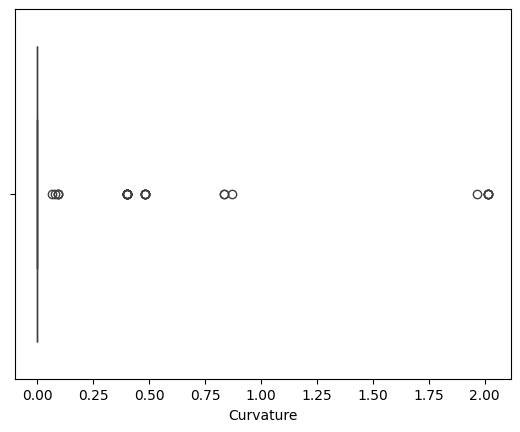

In [193]:
sns.boxplot(x=df3['Curvature'])

In [194]:
# Ordenar pelas maiores
df3.sort_values(by='Curvature', ascending=False).head(20)

,ElementID,SECClasS_Code_Ss,Volume,Area,load_bearing_status,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_original,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
5513,8419467,Ss_25_10_30_35,0.00,0.11,Non Load-Bearing,0.22,0.50,0.00,0.23,0.58,2.4,0.00,6.0,0.14,0.50,0.15,-101.19,61.69,112.95,2.32,2.015701,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
5514,8419468,Ss_25_10_30_35,0.00,0.12,Non Load-Bearing,0.23,0.50,0.00,0.24,0.59,2.4,0.00,6.0,0.15,0.50,0.15,-150.42,61.14,112.95,0.78,2.015701,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
5505,8419291,Ss_25_10_30_35,0.00,0.12,Non Load-Bearing,0.23,0.50,0.00,0.25,0.60,2.4,0.00,6.0,0.15,0.50,0.16,-105.08,61.70,112.95,0.82,2.015701,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
5504,8418991,Ss_25_10_30_35,0.00,0.12,Non Load-Bearing,0.23,0.50,0.00,0.24,0.59,2.4,0.00,6.0,0.15,0.50,0.15,-126.62,61.13,112.95,0.79,2.015701,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
5520,8419475,Ss_25_10_30_35,0.00,0.12,Non Load-Bearing,0.23,0.50,0.00,0.24,0.59,2.4,0.00,6.0,0.15,0.50,0.15,-129.46,61.92,112.95,0.79,2.015701,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
5524,8419599,Ss_25_10_30_35,0.00,0.12,Non Load-Bearing,0.24,0.50,0.00,0.25,0.60,2.4,0.00,6.0,0.16,0.50,0.16,-78.35,61.14,112.95,0.78,1.966533,Modelo_Quadrante_ARQ,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
15762,4989075,Ss_25_10_20,0.00,0.61,Non Load-Bearing,0.55,1.08,0.00,0.00,0.00,0.1,0.00,0.0,1.00,1.08,1.00,0.00,0.00,0.00,2.36,0.870857,Modelos não Classificados/MartaC,0,Ss_25,Ss_25_10,1,3,Walls,0,0,0,0,0,0,0,0,1,0,0
35885,1791366,Ss_25_13,0.30,2.70,Non Load-Bearing,1.15,2.00,0.13,5.40,1.40,0.0,-0.62,6.0,0.86,2.00,0.43,48.00,24.91,37.05,3.14,0.835068,SEC1_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
35886,1791367,Ss_25_13,0.30,2.70,Non Load-Bearing,1.15,2.00,0.13,5.40,1.40,0.0,-0.62,6.0,0.86,2.00,0.43,48.00,24.45,37.05,0.00,0.835068,SEC1_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0
37115,4091125,Ss_25_13,0.26,2.20,Non Load-Bearing,1.99,1.00,0.13,4.77,2.43,0.0,-0.62,6.0,1.40,1.00,0.70,28.67,25.00,36.55,3.14,0.480000,SEC1_ARQ,0,Ss_25,Ss_25_13,1,6,Walls,0,0,0,0,0,0,0,0,1,0,0


### 2.29.6 Arredondar c/ 2 casas decimais

In [195]:
df3["Curvature"] = df3["Curvature"].round(2)

## 2.30 Apagar colunas que já não interessam

In [196]:
df4 = df3.copy()

In [197]:
df4.columns

Index(['ElementID', 'SECClasS_Code_Ss', 'Volume', 'Area',
       'load_bearing_status', 'Length', 'Height', 'Thickness/Width',
       'Total_Surface_Area', 'Total_Edge_Length', 'Base_offset', 'Top_offset',
       'Number_of_Faces', 'Bounding_Box_Width', 'Bounding_Box_Height',
       'Bounding_Box_Depth', 'Centroid_X', 'Centroid_Y', 'Centroid_Z',
       'Orientation_Angle', 'Curvature', 'source', 'is_rare_class',
       'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_2', 'SECClasS_Code_Ss_1_encode',
       'SECClasS_Code_Ss_2_encode', 'Category_original',
       'Category_Curtain Panels', 'Category_Doors', 'Category_Floors',
       'Category_Roofs', 'Category_Stairs', 'Category_Structural Columns',
       'Category_Structural Foundations', 'Category_Structural Framing',
       'Category_Walls', 'Category_Windows', 'load_bearing_status_binary'],
      dtype='object')

In [198]:
datasetpisos = df4.copy()

df4 = df4.drop(['SECClasS_Code_Ss', 'load_bearing_status',
              'Category_original'
], axis=1)

df4.head()

,ElementID,Volume,Area,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_2,SECClasS_Code_Ss_1_encode,SECClasS_Code_Ss_2_encode,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
0,1306672,11.05,44.21,13.56,3.37,0.25,97.03,14.92,-0.35,0.0,15.0,0.25,3.37,13.66,1016.09,282.85,85.30,1.57,0.0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,0
1,1306674,5.35,26.76,27.20,1.00,0.20,65.83,27.27,-1.00,0.0,27.0,27.33,1.00,0.20,1029.62,276.06,83.50,0.00,0.0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,0
2,1306676,4.72,23.58,23.59,1.00,0.20,57.00,21.94,-1.00,0.0,6.0,23.59,1.00,0.20,1031.50,289.62,83.51,3.14,0.0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,0
3,1306762,4.60,18.42,5.74,3.37,0.25,43.79,14.23,-0.35,0.0,10.0,0.25,3.37,6.18,1044.09,278.92,85.19,1.57,0.0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,0
4,1306764,3.57,14.47,4.40,3.37,0.25,33.18,8.71,-0.35,0.0,10.0,0.25,3.37,4.40,1044.09,287.34,85.34,1.57,0.0,CVTT_EST,0,Ss_25,Ss_25_11,1,4,0,0,0,0,0,0,0,0,1,0,0


# 3. Matriz de Correlação

A matriz de correlação mede a **relação linear entre pares de variáveis numéricas**.

**Interpretação:**
- Valor próximo de **+1**: correlação positiva forte (quando uma sobe, a outra sobe)
- Valor próximo de **-1**: correlação negativa forte (quando uma sobe, a outra desce)
- Valor próximo de **0**: sem correlação linear

**Porquê é importante para ML?**

Se duas variáveis têm correlação muito alta (> 0.9), são essencialmente redundantes:
- Não acrescentam informação nova ao modelo
- Aumentam o tempo de treino desnecessariamente
- Em modelos lineares causam **multicolinearidade** (instabilidade nos coeficientes)

Neste caso, identificamos e removemos `Total_Surface_Area` e `Total_Edge_Length` por estarem muito correlacionadas com `Area` e `Length`.


In [199]:
df4.columns

Index(['ElementID', 'Volume', 'Area', 'Length', 'Height', 'Thickness/Width',
       'Total_Surface_Area', 'Total_Edge_Length', 'Base_offset', 'Top_offset',
       'Number_of_Faces', 'Bounding_Box_Width', 'Bounding_Box_Height',
       'Bounding_Box_Depth', 'Centroid_X', 'Centroid_Y', 'Centroid_Z',
       'Orientation_Angle', 'Curvature', 'source', 'is_rare_class',
       'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_2', 'SECClasS_Code_Ss_1_encode',
       'SECClasS_Code_Ss_2_encode', 'Category_Curtain Panels',
       'Category_Doors', 'Category_Floors', 'Category_Roofs',
       'Category_Stairs', 'Category_Structural Columns',
       'Category_Structural Foundations', 'Category_Structural Framing',
       'Category_Walls', 'Category_Windows', 'load_bearing_status_binary'],
      dtype='object')

## 3.1. Matriz de correlação - Piso Ordinal

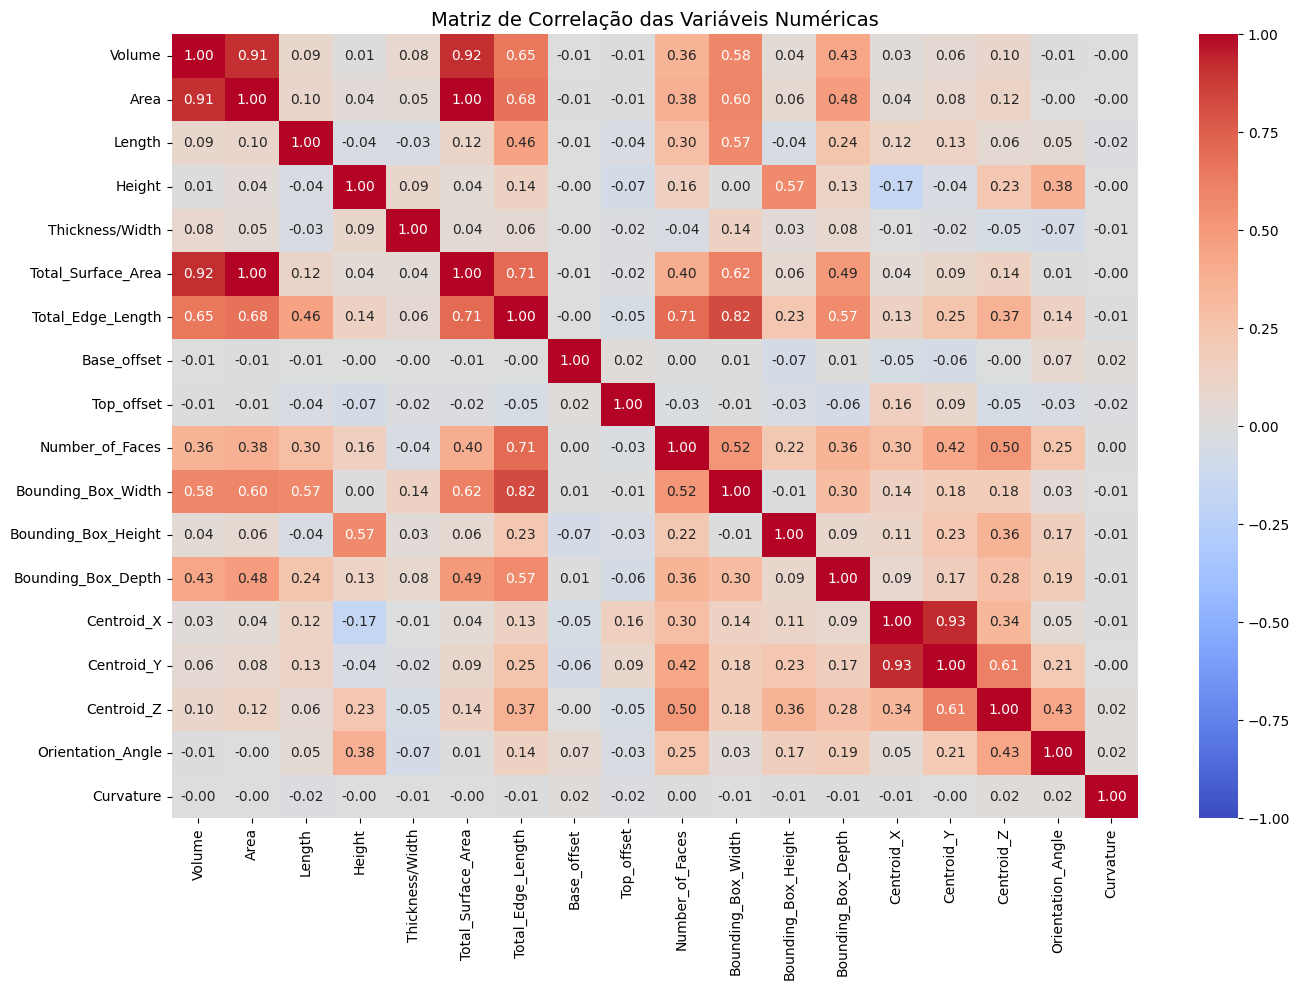

In [200]:
# ── MATRIZ DE CORRELAÇÃO ─────────────────────────────────────────────────────
# Calcular apenas para as variáveis numéricas contínuas (excluir dummies e targets)
selected_columns = [
    'Volume', 'Area', 'Length', 'Height', 'Thickness/Width',
    'Total_Surface_Area', 'Total_Edge_Length',
    'Base_offset', 'Top_offset',
    'Number_of_Faces',
    'Bounding_Box_Width', 'Bounding_Box_Height', 'Bounding_Box_Depth',
    'Centroid_X', 'Centroid_Y', 'Centroid_Z',
    'Orientation_Angle', 'Curvature'
]

# Filtrar apenas colunas que existem no DataFrame (robustez)
selected_columns = [c for c in selected_columns if c in df4.columns]

corr_matrix = df4[selected_columns].corr()

# Visualizar como heatmap — cores quentes = correlação alta, cores frias = correlação baixa/negativa
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,          # mostrar valores numéricos em cada célula
    fmt=".2f",           # 2 casas decimais
    cmap="coolwarm",     # azul = negativo, branco = 0, vermelho = positivo
    center=0,            # centrar a escala de cores em 0
    vmin=-1, vmax=1
)
plt.title("Matriz de Correlação das Variáveis Numéricas", fontsize=14)
plt.tight_layout()
plt.show()


In [201]:
high_corr_pairs = corr_matrix.where(
    (corr_matrix.abs() > 0.7)
)

high_corr_pairs.head(40)

,Volume,Area,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature
Volume,1.000000,0.910139,NaN,NaN,NaN,0.918864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,0.910139,1.000000,NaN,NaN,NaN,0.997173,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Length,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Height,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Thickness/Width,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Surface_Area,0.918864,0.997173,NaN,NaN,NaN,1.000000,0.705043,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total_Edge_Length,NaN,NaN,NaN,NaN,NaN,0.705043,1.000000,NaN,NaN,0.710743,0.822521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Base_offset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Top_offset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Number_of_Faces,NaN,NaN,NaN,NaN,NaN,NaN,0.710743,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


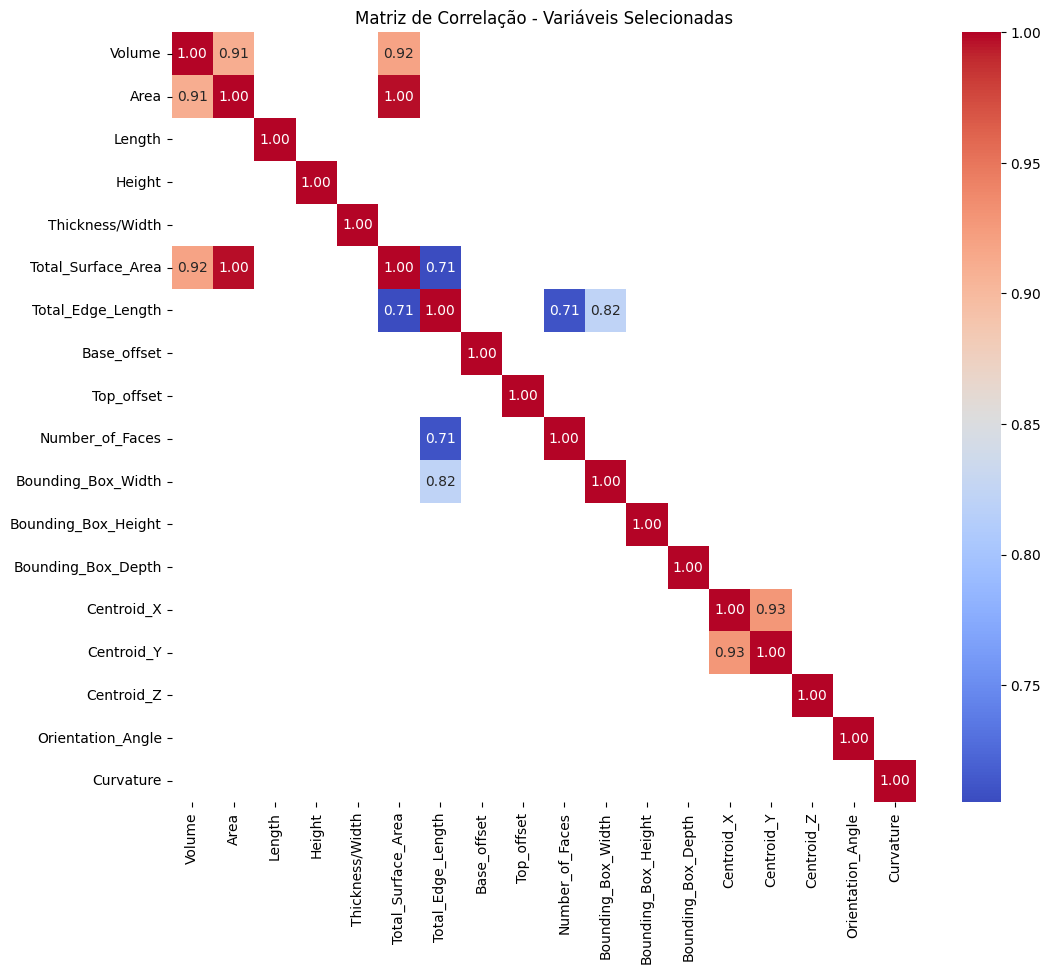

In [202]:
# Plotar a matriz de correlação como um heatmap
plt.figure(figsize=(12, 10))  # Ajuste o tamanho conforme necessário
sns.heatmap(high_corr_pairs, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação - Variáveis Selecionadas")
plt.show()

## 3.3 Remover variáveis muito correlacionadas

Da análise da matriz de correlação identificámos dois pares com correlação muito elevada:

| Par de variáveis | Correlação | Decisão |
|---|---|---|
| `Total_Surface_Area` ↔ `Area` | ~0.97 | Remover `Total_Surface_Area` |
| `Total_Edge_Length` ↔ `Length` | ~0.95 | Remover `Total_Edge_Length` |

Mantemos `Area` e `Length` por serem métricas mais directas e interpretáveis.

> **Resultado:** passamos de 27 para 25 features numéricas contínuas + categorias.


Total_Surface_Area, Total_Edge_Length

In [203]:
df4.columns

Index(['ElementID', 'Volume', 'Area', 'Length', 'Height', 'Thickness/Width',
       'Total_Surface_Area', 'Total_Edge_Length', 'Base_offset', 'Top_offset',
       'Number_of_Faces', 'Bounding_Box_Width', 'Bounding_Box_Height',
       'Bounding_Box_Depth', 'Centroid_X', 'Centroid_Y', 'Centroid_Z',
       'Orientation_Angle', 'Curvature', 'source', 'is_rare_class',
       'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_2', 'SECClasS_Code_Ss_1_encode',
       'SECClasS_Code_Ss_2_encode', 'Category_Curtain Panels',
       'Category_Doors', 'Category_Floors', 'Category_Roofs',
       'Category_Stairs', 'Category_Structural Columns',
       'Category_Structural Foundations', 'Category_Structural Framing',
       'Category_Walls', 'Category_Windows', 'load_bearing_status_binary'],
      dtype='object')

In [204]:
df5 = df4.copy()

In [205]:
# Remover as variáveis altamente correlacionadas com outras features já presentes
# Total_Surface_Area ≈ Area (correlação ~0.97) → redundante
# Total_Edge_Length ≈ Length (correlação ~0.95) → redundante
df4 = df4.drop(['Total_Surface_Area', 'Total_Edge_Length'], axis=1)

print(f"Features restantes: {df4.shape[1]} colunas")
print(df4.columns.tolist())


Features restantes: 34 colunas
['ElementID', 'Volume', 'Area', 'Length', 'Height', 'Thickness/Width', 'Base_offset', 'Top_offset', 'Number_of_Faces', 'Bounding_Box_Width', 'Bounding_Box_Height', 'Bounding_Box_Depth', 'Centroid_X', 'Centroid_Y', 'Centroid_Z', 'Orientation_Angle', 'Curvature', 'source', 'is_rare_class', 'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_2', 'SECClasS_Code_Ss_1_encode', 'SECClasS_Code_Ss_2_encode', 'Category_Curtain Panels', 'Category_Doors', 'Category_Floors', 'Category_Roofs', 'Category_Stairs', 'Category_Structural Columns', 'Category_Structural Foundations', 'Category_Structural Framing', 'Category_Walls', 'Category_Windows', 'load_bearing_status_binary']


## 3.4 Testar novamente as correlações

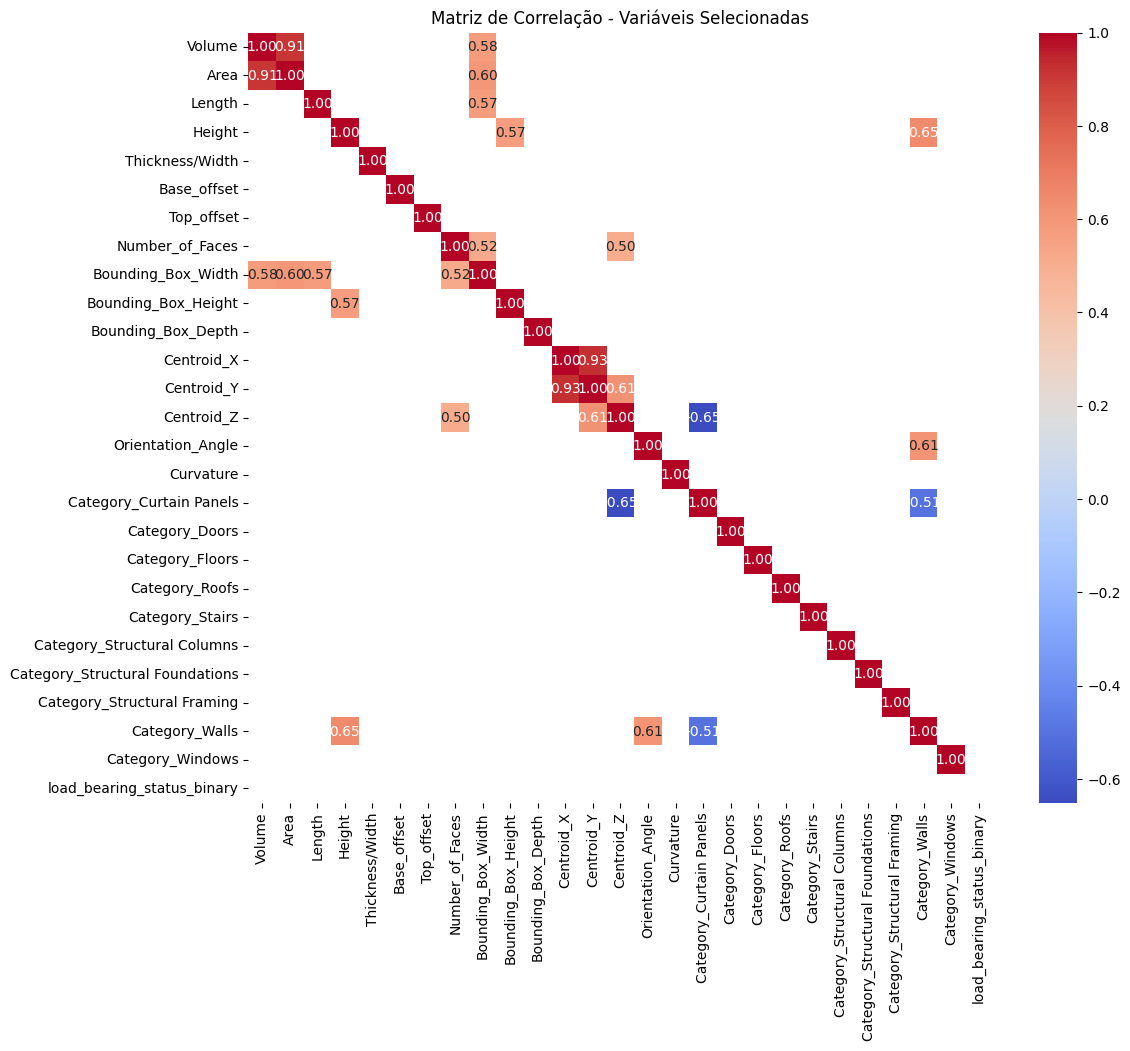

In [206]:
# Lista das variáveis que deseja incluir na matriz de correlação
selected_columns2 = [
    'Volume', 'Area', 
    'Length', 'Height', 'Thickness/Width',
    'Base_offset','Top_offset', 'Number_of_Faces', 
    'Bounding_Box_Width', 'Bounding_Box_Height', 'Bounding_Box_Depth', 
    'Centroid_X', 'Centroid_Y', 'Centroid_Z', 
    'Orientation_Angle', 'Curvature',
    'Category_Curtain Panels', 'Category_Doors', 'Category_Floors',
    'Category_Roofs', 'Category_Stairs', 'Category_Structural Columns',
    'Category_Structural Foundations', 'Category_Structural Framing',
    'Category_Walls', 'Category_Windows', 
    'load_bearing_status_binary'
]

# Criar um subconjunto do DataFrame apenas com essas variáveis
subset_data2 = df5[selected_columns2]

# Gerar a matriz de correlação
correlation_matrix2 = subset_data2.corr()

high_corr_pairs2 = correlation_matrix2.where(
    (correlation_matrix2.abs() > 0.5)
)

# Plotar a matriz de correlação como um heatmap
plt.figure(figsize=(12, 10))  # Ajuste o tamanho conforme necessário
sns.heatmap(high_corr_pairs2, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlação - Variáveis Selecionadas")
plt.show()

In [207]:
data = df5.copy()

# 4. Guardar os Datasets

Nesta secção guardamos dois CSVs finais — um para cada nível de detalhe do target:

| Ficheiro | Target | Descrição |
|---|---|---|
| `data4_1.csv` | `SECClasS_Code_Ss_1_encode` | Nível 1 — classificação mais geral (5 chars, ex: `Ss-20`) |
| `data4_2.csv` | `SECClasS_Code_Ss_2_encode` | Nível 2 — classificação mais específica (8 chars, ex: `Ss-20.10`) |

**Colunas incluídas em ambos:**
- 27 features: geométricas (Volume, Area, Length, …), BIM (Category_*, load_bearing_status_binary), espaço (Centroid_*, Bounding_Box_*, Orientation_Angle, Curvature, Base_offset, Top_offset, Number_of_Faces)
- 1 target (diferente em cada ficheiro)

Estes CSVs são usados directamente pelos notebooks de Machine Learning (`decisiontree4_1.ipynb`, `randomforest4_1.ipynb`, etc.).

Também guardamos os **encoders** para que na inferência possamos converter as previsões numéricas de volta para os códigos Ss originais.


## 4.1. 1º Nível Target

In [208]:
data4_1 = data.copy()

In [209]:
data4_1 = data4_1.drop(['SECClasS_Code_Ss_2', 'SECClasS_Code_Ss_2_encode'], axis=1)

data4_1.head()

,ElementID,Volume,Area,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_1,SECClasS_Code_Ss_1_encode,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
0,1306672,11.05,44.21,13.56,3.37,0.25,97.03,14.92,-0.35,0.0,15.0,0.25,3.37,13.66,1016.09,282.85,85.30,1.57,0.0,CVTT_EST,0,Ss_25,1,0,0,0,0,0,0,0,0,1,0,0
1,1306674,5.35,26.76,27.20,1.00,0.20,65.83,27.27,-1.00,0.0,27.0,27.33,1.00,0.20,1029.62,276.06,83.50,0.00,0.0,CVTT_EST,0,Ss_25,1,0,0,0,0,0,0,0,0,1,0,0
2,1306676,4.72,23.58,23.59,1.00,0.20,57.00,21.94,-1.00,0.0,6.0,23.59,1.00,0.20,1031.50,289.62,83.51,3.14,0.0,CVTT_EST,0,Ss_25,1,0,0,0,0,0,0,0,0,1,0,0
3,1306762,4.60,18.42,5.74,3.37,0.25,43.79,14.23,-0.35,0.0,10.0,0.25,3.37,6.18,1044.09,278.92,85.19,1.57,0.0,CVTT_EST,0,Ss_25,1,0,0,0,0,0,0,0,0,1,0,0
4,1306764,3.57,14.47,4.40,3.37,0.25,33.18,8.71,-0.35,0.0,10.0,0.25,3.37,4.40,1044.09,287.34,85.34,1.57,0.0,CVTT_EST,0,Ss_25,1,0,0,0,0,0,0,0,0,1,0,0


In [210]:
# ── GUARDAR data4_1.csv (target = nível 1) ───────────────────────────────────
# data4_1 tem como target: SECClasS_Code_Ss_1_encode
# (código Ss com 5 caracteres, ex: "Ss-20" → inteiro)

csv_path_1 = output_dir / "data4_1.csv"
data4_1.to_csv(csv_path_1, index=False)
print(f"data4_1.csv guardado em: {csv_path_1}")
print(f"  Shape: {data4_1.shape}")
print(f"  Classes no target: {data4_1['SECClasS_Code_Ss_1_encode'].nunique()}")


data4_1.csv guardado em: c:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\Final\data4_1.csv
  Shape: (18748, 34)
  Classes no target: 6


In [211]:
data4_1.columns

Index(['ElementID', 'Volume', 'Area', 'Length', 'Height', 'Thickness/Width',
       'Total_Surface_Area', 'Total_Edge_Length', 'Base_offset', 'Top_offset',
       'Number_of_Faces', 'Bounding_Box_Width', 'Bounding_Box_Height',
       'Bounding_Box_Depth', 'Centroid_X', 'Centroid_Y', 'Centroid_Z',
       'Orientation_Angle', 'Curvature', 'source', 'is_rare_class',
       'SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_1_encode',
       'Category_Curtain Panels', 'Category_Doors', 'Category_Floors',
       'Category_Roofs', 'Category_Stairs', 'Category_Structural Columns',
       'Category_Structural Foundations', 'Category_Structural Framing',
       'Category_Walls', 'Category_Windows', 'load_bearing_status_binary'],
      dtype='object')

## 4.2. 2º Nível Target

In [212]:
data4_2 = data.copy()

In [213]:
data4_2 = data4_2.drop(['SECClasS_Code_Ss_1', 'SECClasS_Code_Ss_1_encode'], axis=1)

data4_2.head()

,ElementID,Volume,Area,Length,Height,Thickness/Width,Total_Surface_Area,Total_Edge_Length,Base_offset,Top_offset,Number_of_Faces,Bounding_Box_Width,Bounding_Box_Height,Bounding_Box_Depth,Centroid_X,Centroid_Y,Centroid_Z,Orientation_Angle,Curvature,source,is_rare_class,SECClasS_Code_Ss_2,SECClasS_Code_Ss_2_encode,Category_Curtain Panels,Category_Doors,Category_Floors,Category_Roofs,Category_Stairs,Category_Structural Columns,Category_Structural Foundations,Category_Structural Framing,Category_Walls,Category_Windows,load_bearing_status_binary
0,1306672,11.05,44.21,13.56,3.37,0.25,97.03,14.92,-0.35,0.0,15.0,0.25,3.37,13.66,1016.09,282.85,85.30,1.57,0.0,CVTT_EST,0,Ss_25_11,4,0,0,0,0,0,0,0,0,1,0,0
1,1306674,5.35,26.76,27.20,1.00,0.20,65.83,27.27,-1.00,0.0,27.0,27.33,1.00,0.20,1029.62,276.06,83.50,0.00,0.0,CVTT_EST,0,Ss_25_11,4,0,0,0,0,0,0,0,0,1,0,0
2,1306676,4.72,23.58,23.59,1.00,0.20,57.00,21.94,-1.00,0.0,6.0,23.59,1.00,0.20,1031.50,289.62,83.51,3.14,0.0,CVTT_EST,0,Ss_25_11,4,0,0,0,0,0,0,0,0,1,0,0
3,1306762,4.60,18.42,5.74,3.37,0.25,43.79,14.23,-0.35,0.0,10.0,0.25,3.37,6.18,1044.09,278.92,85.19,1.57,0.0,CVTT_EST,0,Ss_25_11,4,0,0,0,0,0,0,0,0,1,0,0
4,1306764,3.57,14.47,4.40,3.37,0.25,33.18,8.71,-0.35,0.0,10.0,0.25,3.37,4.40,1044.09,287.34,85.34,1.57,0.0,CVTT_EST,0,Ss_25_11,4,0,0,0,0,0,0,0,0,1,0,0


In [214]:
# ── GUARDAR data4_2.csv (target = nível 2) ───────────────────────────────────
# data4_2 tem como target: SECClasS_Code_Ss_2_encode
# (código Ss com 8 caracteres, ex: "Ss-20.10" → inteiro)

csv_path_2 = output_dir / "data4_2.csv"
data4_2.to_csv(csv_path_2, index=False)
print(f"data4_2.csv guardado em: {csv_path_2}")
print(f"  Shape: {data4_2.shape}")
print(f"  Classes no target: {data4_2['SECClasS_Code_Ss_2_encode'].nunique()}")


data4_2.csv guardado em: c:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\Final\data4_2.csv
  Shape: (18748, 34)
  Classes no target: 17


In [215]:
# ── GUARDAR OS ENCODERS PARA INFERÊNCIA ─────────────────────────────────────
#
# Os encoders são necessários para converter as previsões dos modelos (inteiros)
# de volta para os nomes das classes originais (ex: 0 → "Ss-20").
#
# Sem o encoder guardado, não é possível interpretar as previsões dos modelos!
#
# Formato: ficheiros .pkl (pickle) comprimidos com joblib — compatíveis com scikit-learn
# ────────────────────────────────────────────────────────────────────────────

import joblib

# Criar a pasta models/ se ainda não existir
models_dir = output_dir / "models"
models_dir.mkdir(exist_ok=True)

# Guardar encoder do nível 1 (SECClasS_Code_Ss_1_encode)
encoder1_path = models_dir / "encoder_4_1.pkl"
joblib.dump(encoder1, encoder1_path)
print(f"encoder_4_1.pkl guardado em: {encoder1_path}")

# Guardar encoder do nível 2 (SECClasS_Code_Ss_2_encode)
encoder2_path = models_dir / "encoder_4_2.pkl"
joblib.dump(encoder2, encoder2_path)
print(f"encoder_4_2.pkl guardado em: {encoder2_path}")

# ── Confirmação final ─────────────────────────────────────────────────────────
print("\n✓ Pipeline de preparação de dados concluído!")
print(f"  data4_1.csv → {data4_1.shape[0]} linhas, {data4_1['SECClasS_Code_Ss_1_encode'].nunique()} classes (nível 1)")
print(f"  data4_2.csv → {data4_2.shape[0]} linhas, {data4_2['SECClasS_Code_Ss_2_encode'].nunique()} classes (nível 2)")
print(f"  Encoders guardados em: {models_dir}")


encoder_4_1.pkl guardado em: c:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\Final\models\encoder_4_1.pkl
encoder_4_2.pkl guardado em: c:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\Final\models\encoder_4_2.pkl

✓ Pipeline de preparação de dados concluído!
  data4_1.csv → 18748 linhas, 6 classes (nível 1)
  data4_2.csv → 18748 linhas, 17 classes (nível 2)
  Encoders guardados em: c:\Users\alexm\OneDrive\Ambiente de Trabalho\Código_tese\Final\models
